In [2]:
!pip install lightgbm

   ---------------------------------------- 0.0/1.4 MB ? eta -:--:--
   --------------- ------------------------ 0.5/1.4 MB 5.1 MB/s eta 0:00:01
   ---------------------------------------- 1.4/1.4 MB 9.5 MB/s  0:00:00


In [7]:
!pip install rich

### 訓練資料的空值與異常值處理策略 (Data Preprocessing Policy)
  ### 空值（Missing Values）處理機制空品監測資料的缺失（儀器校正、維護保養、傳輸中斷）採用三階段處理：
   1. 品質符號與字串清理：
       使用 pd.to_numeric(df[col], errors='coerce') 強制將非數值品質符號（如 #, *, NR, -）轉為 NaN。
   2. 物理欄位前向補值 (ffill)：
       風向角度 (wind_direc) 轉成 sin/\cos 向量前，若有缺值先以前值 (ffill) 填補，開頭缺值補 0，避免三角函數計算報錯 (TypeError)。
   3. 訓練集列刪除 (dropna) & 測試集原生處置：
       產生 Lag 延遲特徵（Lag-1, 3, 6, 24）後，訓練集直接使用 df.dropna(subset=feature_cols + target_list) 剔除缺失列。
       LightGBM 具備原生 NaN 預設分流機制（Default Direction Split），可應對測試集少量的缺失。
  ### 異常值（Outliers）
   1. 處理機制物理邏輯邊界：剔除不合常理的負值（如 PM2.5< 0 或 OX < 0）。
   2. 保留真實高濃度污染：極高濃度值多為境外傳輸或強光化學反應等真實事件，非壞軌，故選擇保留以訓練模型對高污染事件的預測能力。
   3. 模型抗噪特性：LightGBM 採用直方圖演算法（Histogram-based Binning），將連續數值離散化，極端值不會像在線性迴歸或神經網路中造成巨大的梯度拉扯。

### 3. EDA 視覺化模組

| 模組名稱 | 繪圖類型 | 輸出檔名 | 業務/物理邏輯焦點 |
| --- | --- | --- | --- |
| 全年日均趨勢 | 五站時間序列折線圖 | trend_daily_pm2.5.png<br>trend_daily_ox.png | 觀察 PM2.5（冬高夏低，季風影響）與 OX（夏高冬低，光化學反應）的季節週期變化。 |
| 各測站分布 | 按中位數排序箱型圖 | boxplot_pm2.5.png<br>boxplot_ox.png | 比較都會群與沿海群濃度中位數，並檢視極端污染事件離群值。 |
| 日內時段變化 | 三群組 24 小時趨勢圖 | hourly_trend_pm2.5.png<br>hourly_trend_ox.png | PM2.5：上下班交通尖峰雙峰現象；<br>OX：午後（13:00~15:00）光照強引發的光化學反應峰值。 |

### PM2.5 & Ox 全年日均趨勢

⠋ 正在載入桃園五站監測資料...
✓ 資料載入完成！

==================== 開始繪製全年日均趨勢圖 ====================
⠋ 正在計算與繪製 PM2.5 全年日均趨勢...


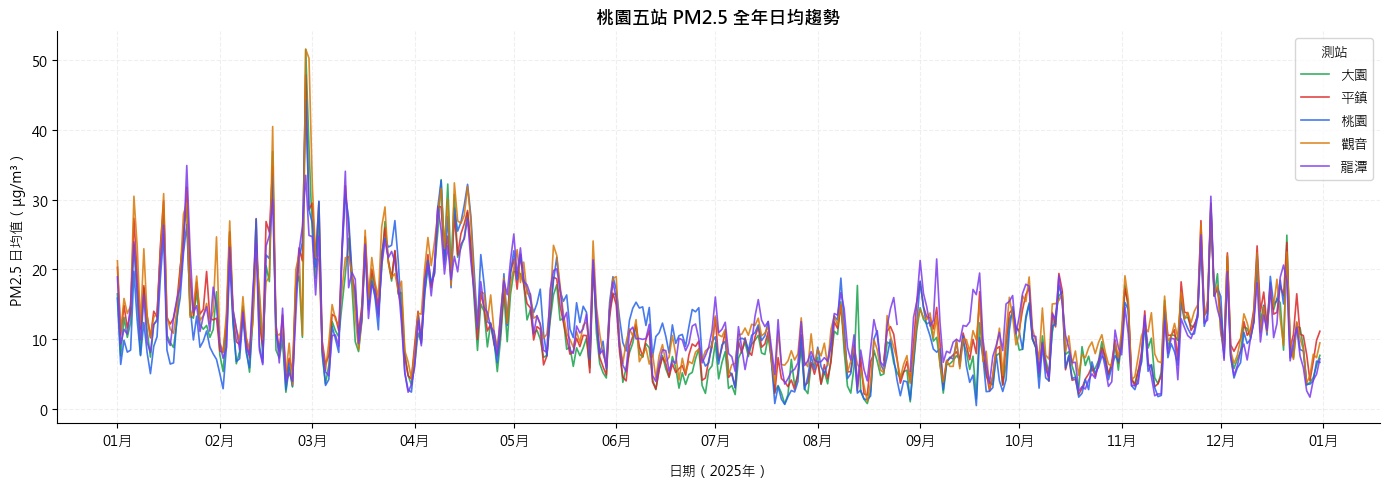

[已儲存圖表] trend_daily_pm2.5.png
⠋ 正在計算與繪製 OX 全年日均趨勢...


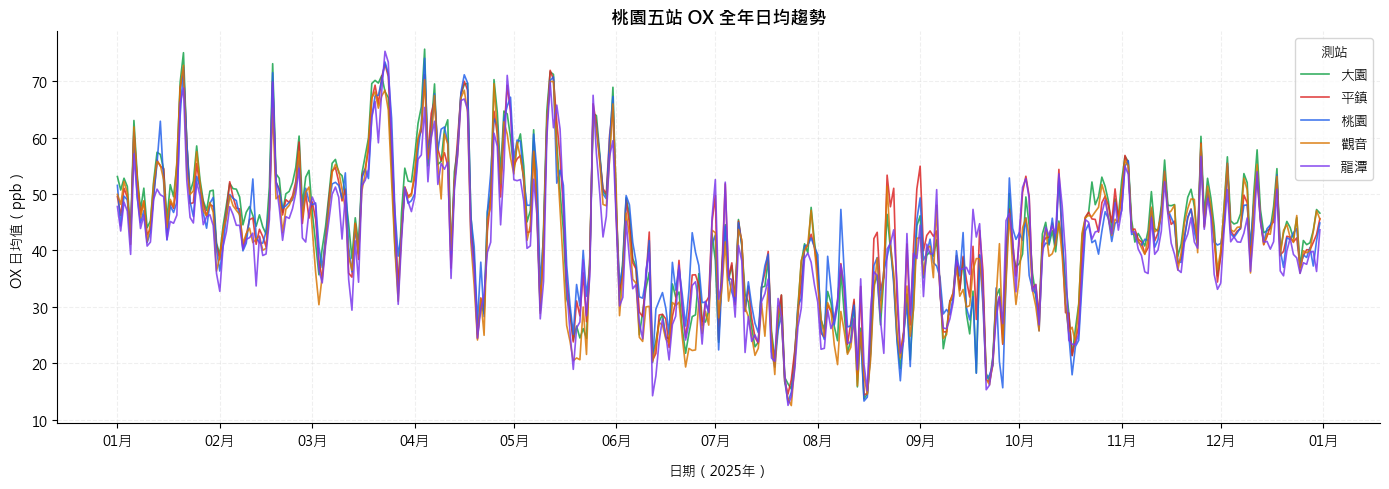

[已儲存圖表] trend_daily_ox.png

EDA 日均趨勢視覺化完成 — 輸出檔案清單
📸 輸出檔案：
  • trend_daily_pm2.5.png (五站 PM2.5 日均趨勢圖)
  • trend_daily_ox.png    (五站 OX 日均趨勢圖)

🎉 全部完成。


In [1]:
# ==============================================================================
# 桃園空品監測資料 — PM2.5 & OX 全年日均趨勢 EDA (五站比較折線圖)
# SDD 模組：時間序列重構、日均值計算、多測站時間趨勢折線圖繪製
# ==============================================================================

import warnings
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import pandas as pd

warnings.filterwarnings("ignore")

# 1. 載入 Rich Console (預防死鎖)
try:
    from rich.console import Console

    console = Console(force_jupyter=False)
    HAS_RICH = True
except ImportError:
    HAS_RICH = False
    print("💡 提示：可安裝 rich 套件以獲得動態 Loading 動畫效果 (pip install rich)")

# 設定繪圖中文字型
plt.rcParams["font.sans-serif"] = [
    "Microsoft JhengHei",
    "SimHei",
    "Noto Sans CJK TC",
    "Arial",
]
plt.rcParams["axes.unicode_minus"] = False


def log(msg):
    if HAS_RICH:
        console.print(msg)
    else:
        print(msg)


# ==============================================================================
# 一、資料載入與預處理
# ==============================================================================
if HAS_RICH:
    status = console.status(
        "[bold cyan]正在載入桃園五站監測資料...", spinner="dots"
    )
    status.start()

df = pd.read_csv("2025桃園五站空品監測資料_精簡20欄合體版.csv")
df["publishtime"] = pd.to_datetime(df["publishtime"])

if HAS_RICH:
    status.stop()
log("[green]✓ 資料載入完成！[/green]\n")

# 站點顏色定義（五站固定配色）
station_colors = {
    "桃園": "#2563EB",  # 藍
    "平鎮": "#DC2626",  # 紅
    "大園": "#16A34A",  # 綠
    "觀音": "#D97706",  # 橙
    "龍潭": "#7C3AED",  # 紫
}

targets = ["pm2.5", "ox"]


# ==============================================================================
# 二、趨勢繪圖核心函式
# ==============================================================================
def plot_daily_trend(df, target_col):
    """計算各站逐日平均值，繪製全年日均趨勢折線圖。

    五站各一條線，顏色固定。
    """
    if HAS_RICH:
        status = console.status(
            f"[bold cyan]正在計算與繪製 {target_col.upper()} 全年日均趨勢...",
            spinner="dots",
        )
        status.start()

    # 計算日均值：以 publishtime 和 sitename 分組，resample 到日頻率
    daily = (
        df.set_index("publishtime")
        .groupby("sitename")[target_col]
        .resample("D")
        .mean()
        .unstack("sitename")  # 轉成寬表，欄位為站點名稱
    )

    if HAS_RICH:
        status.stop()

    fig, ax = plt.subplots(figsize=(14, 5))

    # 繪製各站折線
    for station in daily.columns:
        color = station_colors.get(station, "#888888")
        ax.plot(
            daily.index,
            daily[station],
            label=station,
            color=color,
            linewidth=1.2,
            alpha=0.85,
        )

    # X軸格式：每月一個主刻度
    ax.xaxis.set_major_locator(mdates.MonthLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%m月"))
    fig.autofmt_xdate(rotation=0, ha="center")  # 日期刻度保持水平好閱讀

    # 標籤與標題設定
    unit = "μg/m³" if target_col == "pm2.5" else "ppb"
    ax.set_xlabel("日期（2025年）", labelpad=10)
    ax.set_ylabel(f"{target_col.upper()} 日均值（{unit}）")
    ax.set_title(
        f"桃園五站 {target_col.upper()} 全年日均趨勢", fontsize=13, weight="bold"
    )
    ax.legend(title="測站", loc="upper right", frameon=True)

    # 網格與邊框隱藏
    ax.grid(True, linestyle="--", alpha=0.3, color="#CCCCCC")
    for spine in ["top", "right"]:
        ax.spines[spine].set_visible(False)

    plt.tight_layout()
    fname = f"trend_daily_{target_col}.png"
    plt.savefig(fname, dpi=150)
    plt.show()
    log(f"[已儲存圖表] {fname}")


# ==============================================================================
# 三、執行與輸出
# ==============================================================================
log("==================== 開始繪製全年日均趨勢圖 ====================")

for target in targets:
    plot_daily_trend(df, target)

log("\n" + "=" * 60)
log("EDA 日均趨勢視覺化完成 — 輸出檔案清單")
log("=" * 60)
log("📸 輸出檔案：")
log("  • trend_daily_pm2.5.png (五站 PM2.5 日均趨勢圖)")
log("  • trend_daily_ox.png    (五站 OX 日均趨勢圖)")
log("\n🎉 全部完成。")

### Ox 4_6月高於7_8月問題探討

In [4]:
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams['font.family'] = 'Microsoft JhengHei'

df = pd.read_csv('2025桃園五站空品監測資料_精簡20欄合體版.csv')
df['publishtime'] = pd.to_datetime(df['publishtime'])

# 只取7~9月，計算全站平均月RH
df['month'] = df['publishtime'].dt.month
monthly_rh = df[df['month'].isin([4,5,6,7,8,9])].groupby('month')['rh'].mean()

print(monthly_rh)

month
4    75.309557
5    76.686084
6    76.954722
7    77.997032
8    68.530013
9    73.406372
Name: rh, dtype: float64


In [5]:
monthly_no = df[df['month'].isin([4,5,6,7,8,9])].groupby('month')['no'].mean()
print(monthly_no)

month
4    1.458171
5    1.388513
6    1.760152
7    1.913084
8    1.784588
9    1.793761
Name: no, dtype: float64


In [7]:
df['wind_speed'] = pd.to_numeric(df['wind_speed'], errors='coerce')
monthly_ws = df[df['month'].isin([4,5,6,7,8,9])].groupby('month')['wind_speed'].mean()
print(monthly_ws)

month
4    2.298887
5    2.250378
6    2.012583
7    2.663715
8    2.280270
9    2.023673
Name: wind_speed, dtype: float64


In [8]:
df['amb_temp'] = pd.to_numeric(df['amb_temp'], errors='coerce')
monthly_temp = df[df['month'].isin([4,5,6,7,8,9])].groupby('month')['amb_temp'].mean()
print(monthly_temp)

month
4    22.387601
5    25.814590
6    28.918028
7    29.071182
8    30.155532
9    29.561302
Name: amb_temp, dtype: float64


7月風速最高（2.66），但6月和9月反而是最低的——風速分布不規律，不能解釋OX 7~9月下降的模式。

風速假說不成立。

NO的數字：4月1.46 → 7月1.91，30%的差距加上臭氧滴定效應，可能是最主要的原因，只是效果沒有想像中那麼戲劇性。

另一個可能是**VOCs（揮發性有機化合物，OX生成的前驅物之一）**的季節性變化，但資料集裡沒有這個欄位，無法驗證。

OX季節模式的完整解釋是：

4~6月：氣溫適中、對流弱、NO濃度低，OX生成後留在地面，濃度最高

7~9月：氣溫高、對流強、NO濃度略升，雙重壓低地面OX濃度


### 各測站 PM2.5 & Ox 分布

⠋ 正在載入桃園五站監測資料...0m
✓ 資料載入完成！

==================== 開始繪製各測站箱型圖 ====================
⠋ 正在繪製 PM2.5 測站分布箱型圖...0m


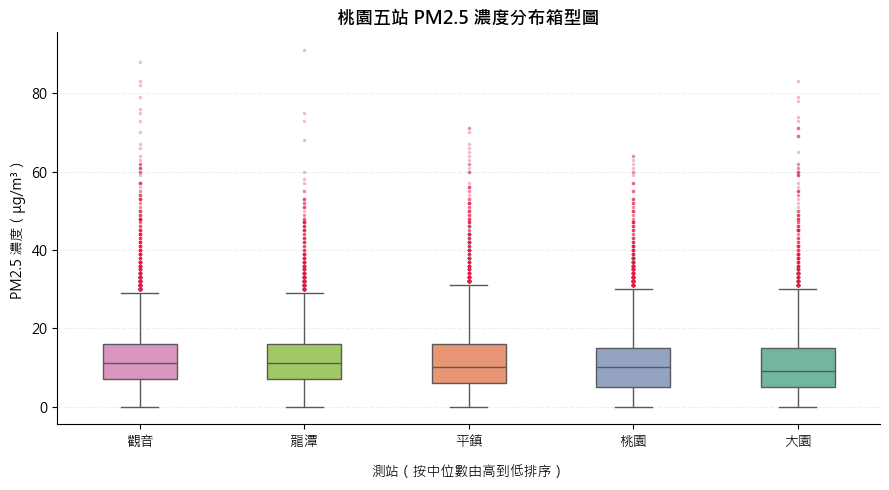

[已儲存圖表] boxplot_pm2.5.png
⠙ 正在繪製 OX 測站分布箱型圖...0m


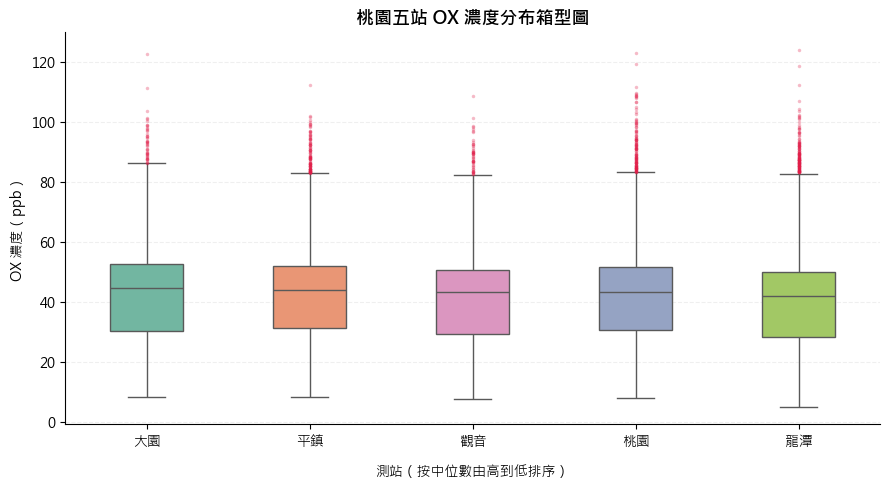

[已儲存圖表] boxplot_ox.png

EDA 各測站分布箱型圖完成 — 輸出檔案清單
📸 輸出檔案：
  • boxplot_pm2.5.png (五站 PM2.5 分布箱型圖)
  • boxplot_ox.png    (五站 OX 分布箱型圖)

🎉 全部完成。


In [3]:
# ==============================================================================
# 桃園空品監測資料 — PM2.5 & OX 各測站分布 EDA (Boxplot 箱型圖)
# SDD 模組：測站中位數排序、統計分布特徵、極端離群值視覺化
# ==============================================================================

import warnings
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

warnings.filterwarnings("ignore")

# 1. 載入 Rich Console (預防死鎖)
try:
    from rich.console import Console

    console = Console(force_jupyter=False)
    HAS_RICH = True
except ImportError:
    HAS_RICH = False
    print("💡 提示：可安裝 rich 套件以獲得動態 Loading 動畫效果 (pip install rich)")

# 設定繪圖中文字型
plt.rcParams["font.sans-serif"] = [
    "Microsoft JhengHei",
    "SimHei",
    "Noto Sans CJK TC",
    "Arial",
]
plt.rcParams["axes.unicode_minus"] = False


def log(msg):
    if HAS_RICH:
        console.print(msg)
    else:
        print(msg)


# ==============================================================================
# 一、資料載入與預處理
# ==============================================================================
if HAS_RICH:
    status = console.status(
        "[bold cyan]正在載入桃園五站監測資料...", spinner="dots"
    )
    status.start()

df = pd.read_csv("2025桃園五站空品監測資料_精簡20欄合體版.csv")
df["publishtime"] = pd.to_datetime(df["publishtime"])

if HAS_RICH:
    status.stop()
log("[green]✓ 資料載入完成！[/green]\n")

targets = ["pm2.5", "ox"]

# 站點排序：依各站目標變數中位數（Median）由高到低排列
station_order_pm25 = (
    df.groupby("sitename")["pm2.5"]
    .median()
    .sort_values(ascending=False)
    .index.tolist()
)

station_order_ox = (
    df.groupby("sitename")["ox"]
    .median()
    .sort_values(ascending=False)
    .index.tolist()
)

station_orders = {
    "pm2.5": station_order_pm25,
    "ox": station_order_ox,
}


# ==============================================================================
# 二、箱型圖（Boxplot）繪製核心函式
# ==============================================================================
def plot_boxplot(df, target_col, station_order):
    """繪製各測站目標變數的箱型圖（Boxplot）。

    箱型圖說明：
    - 箱體中線：中位數 (Median)
    - 箱體上下緣：第 25~75 百分位數 (四分位距 IQR)
    - 鬚線：1.5 倍 IQR 範圍內的極值
    - 點：離群值 (Outliers)
    """
    if HAS_RICH:
        status = console.status(
            f"[bold cyan]正在繪製 {target_col.upper()} 測站分布箱型圖...",
            spinner="dots",
        )
        status.start()

    unit = "μg/m³" if target_col == "pm2.5" else "ppb"

    fig, ax = plt.subplots(figsize=(9, 5))

    # 使用 Seaborn 繪製 Boxplot (加入 hue=sitename 避免未來版本 deprecation warning)
    sns.boxplot(
        data=df,
        x="sitename",
        y=target_col,
        hue="sitename",
        order=station_order,
        palette="Set2",
        width=0.45,
        fliersize=2.5,  # 離群值點大小
        flierprops=dict(
            alpha=0.3, markerfacecolor="#E11D48", markeredgecolor="none"
        ),  # 離群值樣式
        legend=False,
        ax=ax,
    )

    if HAS_RICH:
        status.stop()

    # 圖表標籤與標題設定
    ax.set_xlabel("測站（按中位數由高到低排序）", labelpad=10)
    ax.set_ylabel(f"{target_col.upper()} 濃度（{unit}）")
    ax.set_title(
        f"桃園五站 {target_col.upper()} 濃度分布箱型圖",
        fontsize=13,
        weight="bold",
    )

    # 背景網格與邊框優化
    ax.grid(True, axis="y", linestyle="--", alpha=0.3, color="#CCCCCC")
    for spine in ["top", "right"]:
        ax.spines[spine].set_visible(False)

    plt.tight_layout()
    fname = f"boxplot_{target_col}.png"
    plt.savefig(fname, dpi=150)
    plt.show()
    log(f"[已儲存圖表] {fname}")


# ==============================================================================
# 三、執行與輸出
# ==============================================================================
log("==================== 開始繪製各測站箱型圖 ====================")

for target in targets:
    plot_boxplot(df, target, station_orders[target])

log("\n" + "=" * 60)
log("EDA 各測站分布箱型圖完成 — 輸出檔案清單")
log("=" * 60)
log("📸 輸出檔案：")
log("  • boxplot_pm2.5.png (五站 PM2.5 分布箱型圖)")
log("  • boxplot_ox.png    (五站 OX 分布箱型圖)")
log("\n🎉 全部完成。")

### 日內時段變化（是否有交通尖峰特徵）

⠋ 正在載入桃園五站監測資料並進行欄位轉換...0m
✓ 資料載入與前置處理完成！

==================== 開始繪製日內時段變化趨勢圖 ====================
⠋ 正在計算與繪製 PM2.5 日內時段變化圖...


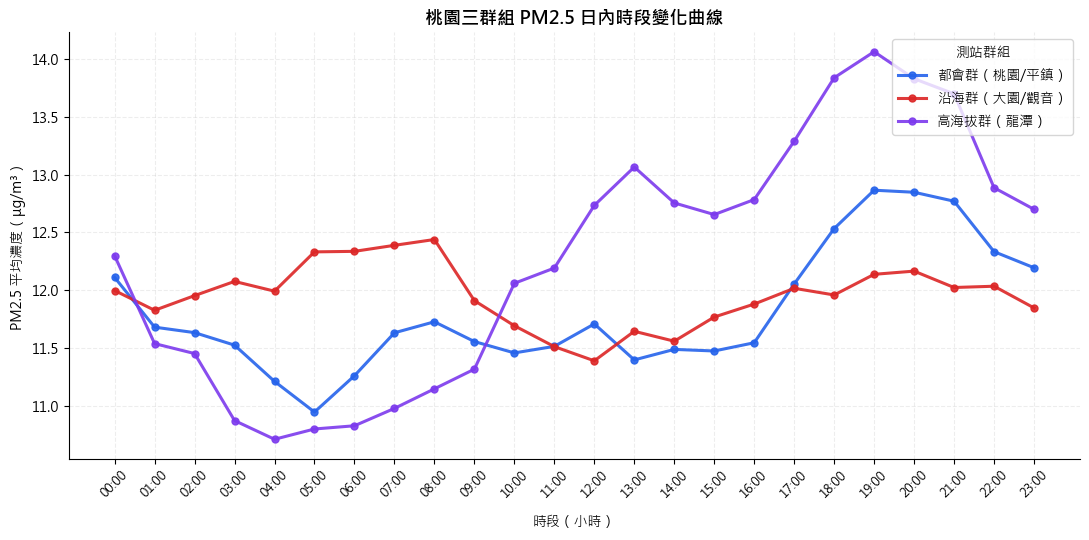

[已儲存圖表] hourly_trend_pm2.5.png
⠋ 正在計算與繪製 OX 日內時段變化圖...


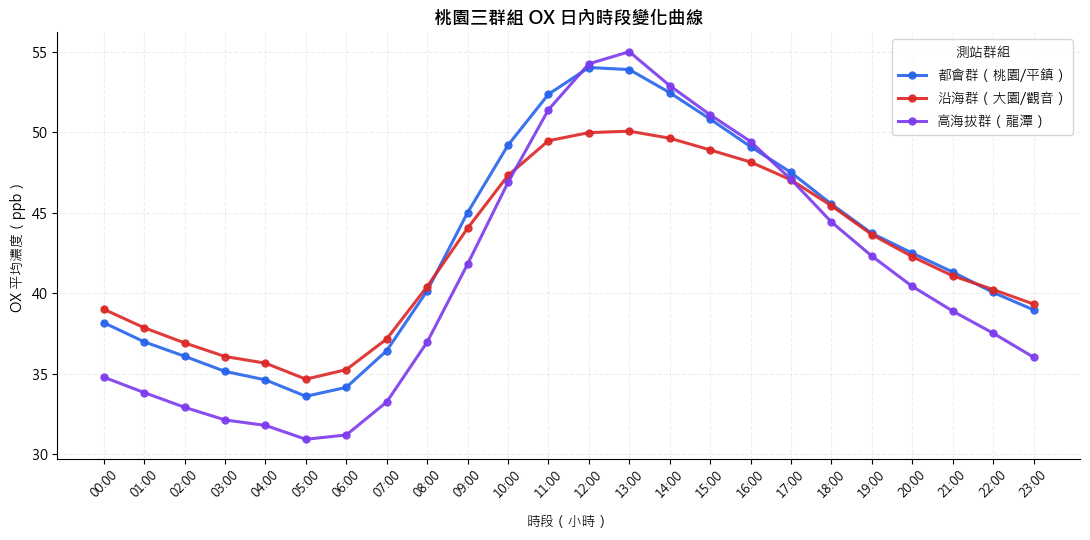

[已儲存圖表] hourly_trend_ox.png

EDA 日內時段變化視覺化完成 — 輸出檔案清單
📸 輸出檔案：
  • hourly_trend_pm2.5.png (三群組 PM2.5 日內小時趨勢圖)
  • hourly_trend_ox.png    (三群組 OX 日內小時趨勢圖)

🎉 全部完成。


In [9]:
# ==============================================================================
# 桃園空品監測資料 — PM2.5 & OX 日內時段變化 EDA (三群組平均小時趨勢)
# SDD 模組：地理區域群組化、24小時週期平均計算、雙污染物日內變化趨勢視覺化
# ==============================================================================

import warnings
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

warnings.filterwarnings("ignore")

# 1. 載入 Rich Console (預防死鎖)
try:
    from rich.console import Console

    console = Console(force_jupyter=False)
    HAS_RICH = True
except ImportError:
    HAS_RICH = False
    print("💡 提示：可安裝 rich 套件以獲得動態 Loading 動畫效果 (pip install rich)")

# 設定繪圖中文字型
plt.rcParams["font.sans-serif"] = [
    "Microsoft JhengHei",
    "SimHei",
    "Noto Sans CJK TC",
    "Arial",
]
plt.rcParams["axes.unicode_minus"] = False


def log(msg):
    if HAS_RICH:
        console.print(msg)
    else:
        print(msg)


# ==============================================================================
# 一、資料載入與預處理
# ==============================================================================
if HAS_RICH:
    status = console.status(
        "[bold cyan]正在載入桃園五站監測資料並進行欄位轉換...", spinner="dots"
    )
    status.start()

df = pd.read_csv("2025桃園五站空品監測資料_精簡20欄合體版.csv")
df["publishtime"] = pd.to_datetime(df["publishtime"])
df["hour"] = df["publishtime"].dt.hour

# 數值欄位轉化（強制將 quality note 符號轉為 NaN）
for col in ["pm2.5", "ox"]:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# ── 群組與配色定義 ──
group_map = {
    "都會群（桃園/平鎮）": ["桃園", "平鎮"],
    "沿海群（大園/觀音）": ["大園", "觀音"],
    "高海拔群（龍潭）": ["龍潭"],
}

group_colors = {
    "都會群（桃園/平鎮）": "#2563EB",  # 藍
    "沿海群（大園/觀音）": "#DC2626",  # 紅
    "高海拔群（龍潭）": "#7C3AED",  # 紫
}

targets = ["pm2.5", "ox"]

if HAS_RICH:
    status.stop()
log("[green]✓ 資料載入與前置處理完成！[/green]\n")


# ==============================================================================
# 二、日內小時趨勢繪圖核心函式
# ==============================================================================
def plot_hourly_trend(df, target_col):
    """計算各群組逐小時平均值，繪製 24 小時日內時段趨勢折線圖。

    群組平均 = 篩選該群組站點後，依 hour 計算數值平均。
    """
    if HAS_RICH:
        status = console.status(
            f"[bold cyan]正在計算與繪製 {target_col.upper()} 日內時段變化圖...",
            spinner="dots",
        )
        status.start()

    unit = "μg/m³" if target_col == "pm2.5" else "ppb"

    fig, ax = plt.subplots(figsize=(11, 5.5))

    for group_name, stations in group_map.items():
        # 篩選群組內站點，計算小時平均
        df_group = df[df["sitename"].isin(stations)]
        hourly_mean = df_group.groupby("hour")[target_col].mean()

        ax.plot(
            hourly_mean.index,
            hourly_mean.values,
            label=group_name,
            color=group_colors[group_name],
            linewidth=2.2,
            marker="o",
            markersize=5,
            alpha=0.9,
        )

    if HAS_RICH:
        status.stop()

    # X 軸設定 (24 小時刻度)
    ax.set_xticks(range(0, 24))
    ax.set_xticklabels(
        [f"{h:02d}:00" for h in range(24)], rotation=45, fontsize=9
    )

    # 標籤與標題設定
    ax.set_xlabel("時段（小時）", labelpad=10)
    ax.set_ylabel(f"{target_col.upper()} 平均濃度（{unit}）")
    ax.set_title(
        f"桃園三群組 {target_col.upper()} 日內時段變化曲線",
        fontsize=13,
        weight="bold",
    )
    ax.legend(title="測站群組", loc="upper right", frameon=True)

    # 背景網格與邊框優化
    ax.grid(True, linestyle="--", alpha=0.35, color="#CCCCCC")
    for spine in ["top", "right"]:
        ax.spines[spine].set_visible(False)

    plt.tight_layout()
    fname = f"hourly_trend_{target_col}.png"
    plt.savefig(fname, dpi=150)
    plt.show()
    log(f"[已儲存圖表] {fname}")


# ==============================================================================
# 三、執行與輸出
# ==============================================================================
log("==================== 開始繪製日內時段變化趨勢圖 ====================")

for target in targets:
    plot_hourly_trend(df, target)

log("\n" + "=" * 60)
log("EDA 日內時段變化視覺化完成 — 輸出檔案清單")
log("=" * 60)
log("📸 輸出檔案：")
log("  • hourly_trend_pm2.5.png (三群組 PM2.5 日內小時趨勢圖)")
log("  • hourly_trend_ox.png    (三群組 OX 日內小時趨勢圖)")
log("\n🎉 全部完成。")

In [10]:
import pandas as pd

df = pd.read_csv('2025桃園五站空品監測資料_精簡20欄合體版.csv')
df['wind_speed'] = pd.to_numeric(df['wind_speed'], errors='coerce')

ws_by_station = df.groupby('sitename')['wind_speed'].mean().sort_values()
print(ws_by_station)

sitename
平鎮    1.821734
桃園    2.024266
龍潭    2.900606
大園    3.766724
觀音    3.886231
Name: wind_speed, dtype: float64


龍潭站PM2.5偏高，推測與測站鄰近國道及市區幹道，受交通排放直接影響有關，而非地形封閉或工業源所致。

OX圖：三群組都在14:00左右達到峰值，之後開始下降，完全符合光化學反應的日照驅動模式。沿海群最高，都會群居中，龍潭最低——跟boxplot的結論一致。

PM2.5圖：OX在14:00後開始下降，但PM2.5在16:00後還在上升，一直到傍晚才到高峰——這個時間差直接說明了兩件事：

下午晚段PM2.5的上升不能完全歸因於OX，交通尖峰的一次污染物貢獻在這裡更明顯
兩個污染來源（光化學二次生成 vs 交通排放）的時間峰值不同，可以在圖上清楚區分

### 數據相關性EDA

⠙ 正在載入五站與桃園獨立 CSV 資料...0m
✓ 資料前置處理完成！

==================== 執行模組 A：Pearson Heatmap ====================
⠹ 模組 A - 繪製 Global Heatmap...0m

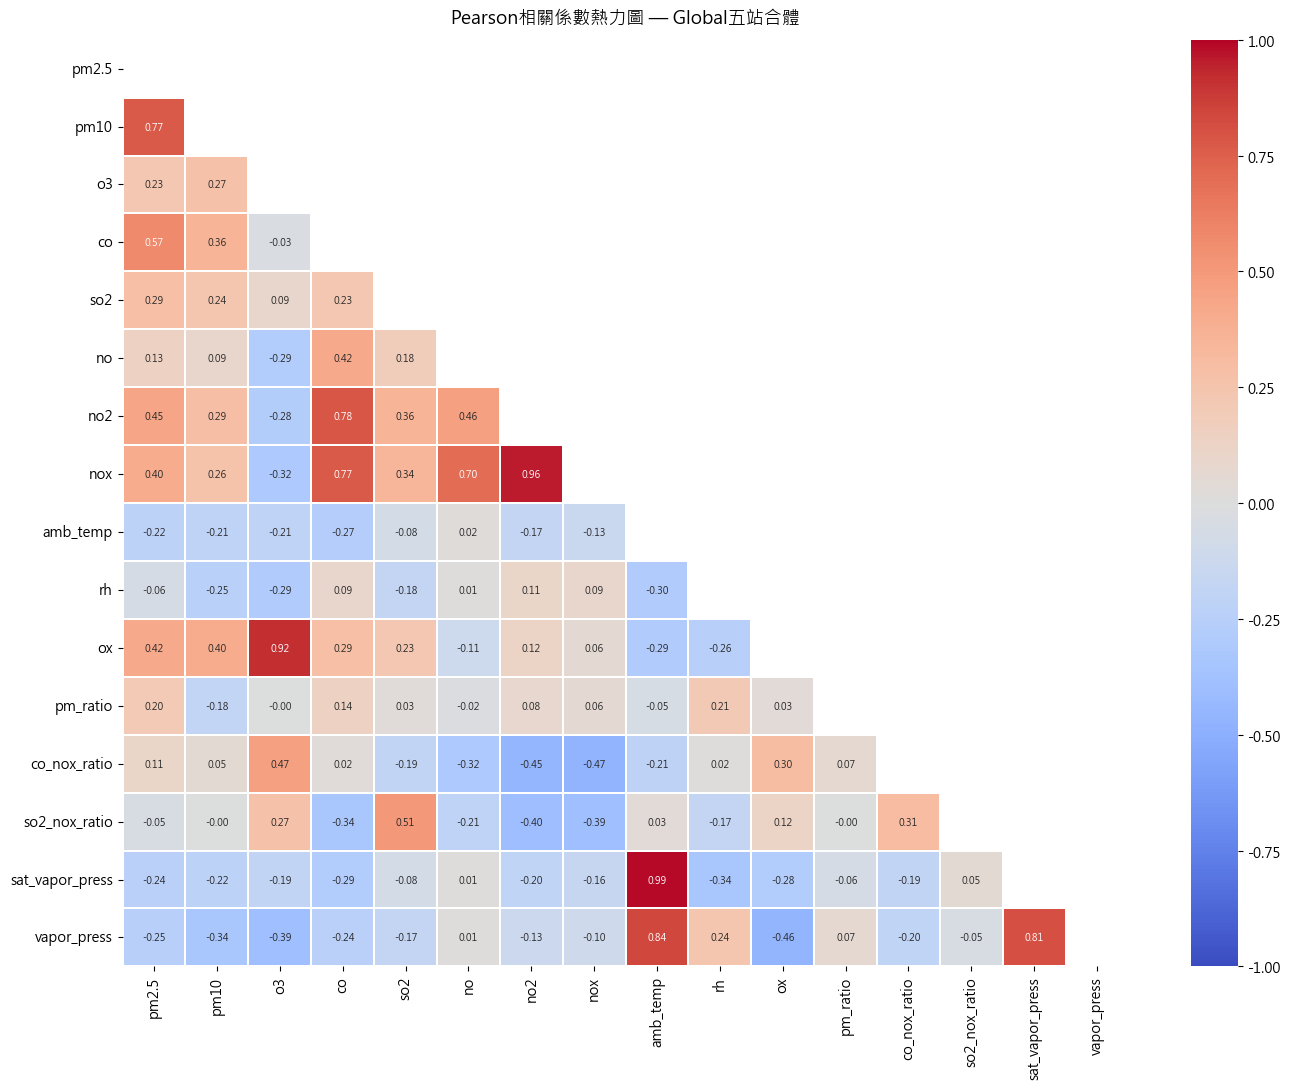

[已儲存] heatmap_Global五站合體.png
⠙ 模組 A - 繪製 Local [桃園] Heatmap...

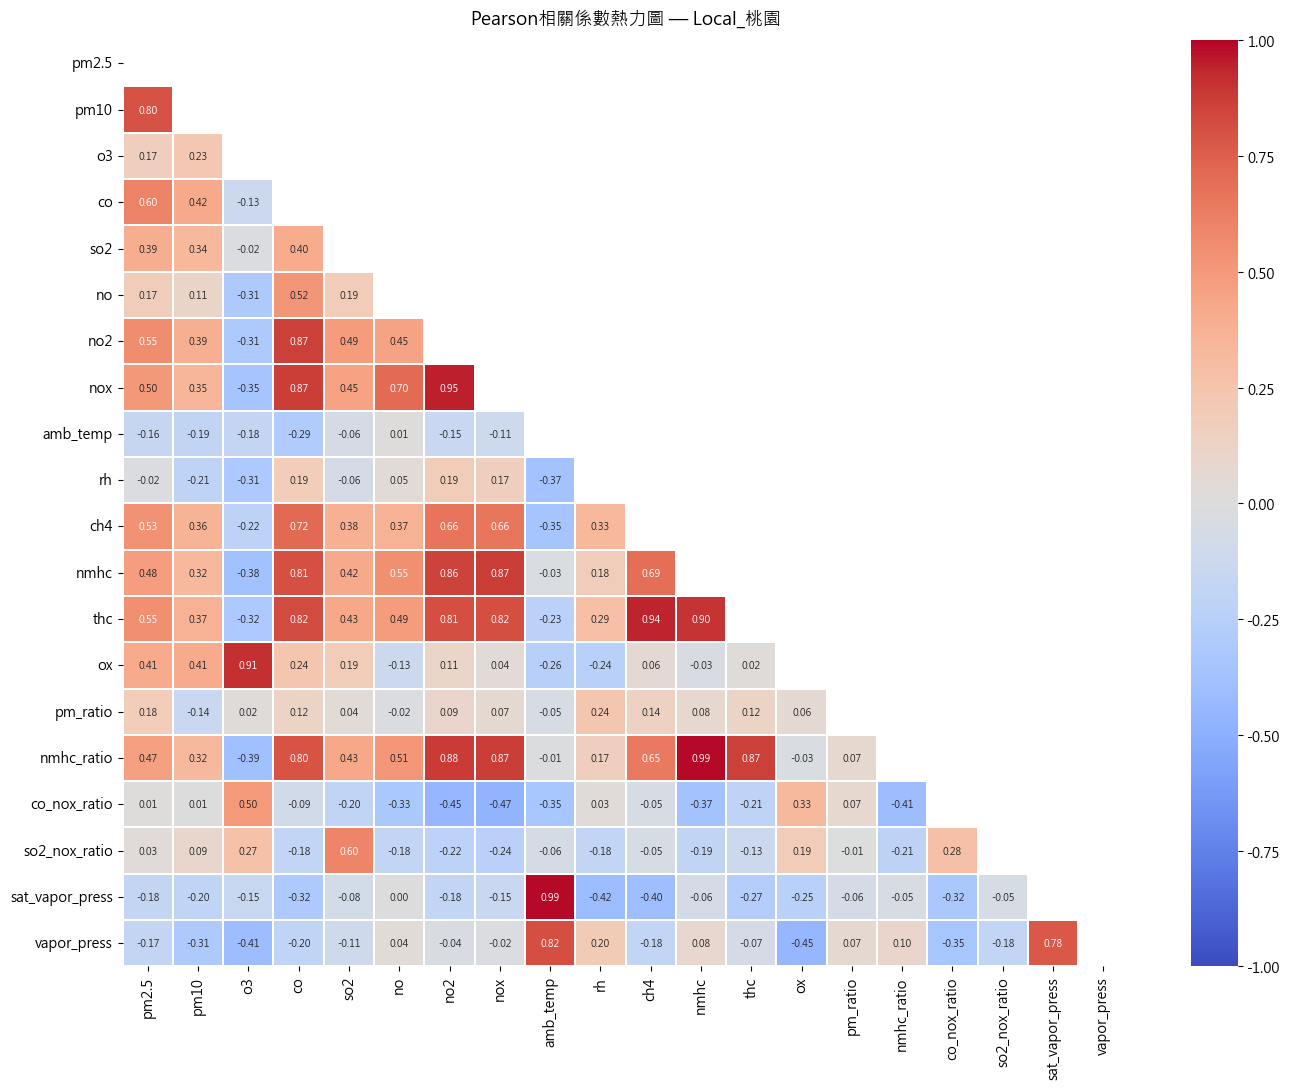

[已儲存] heatmap_Local_桃園.png
⠴ 模組 A - 繪製 Local [平鎮] Heatmap...

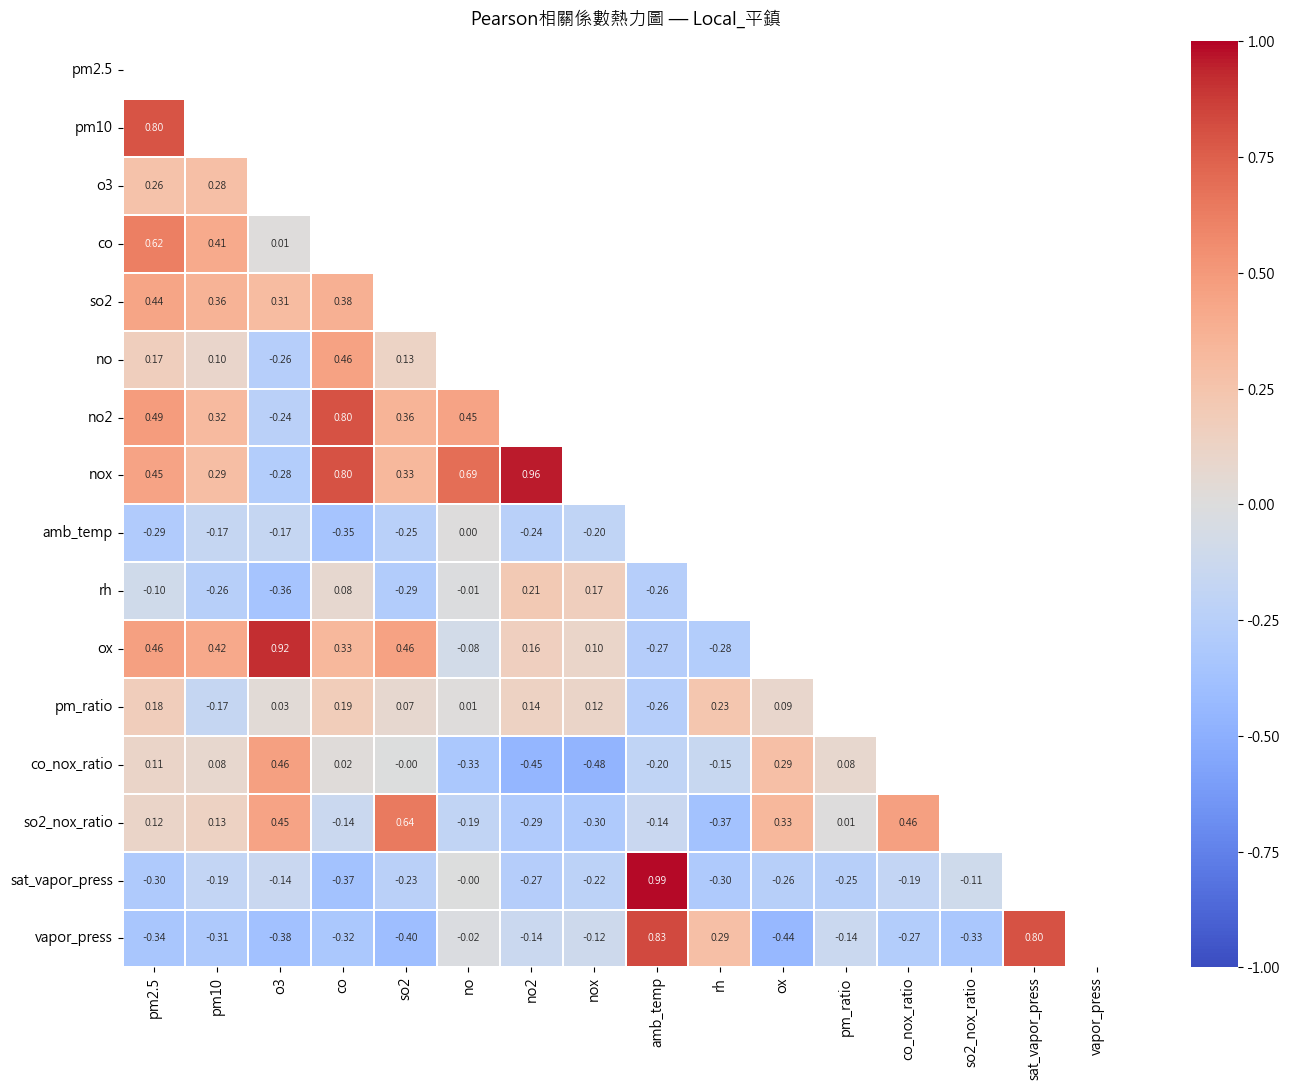

[已儲存] heatmap_Local_平鎮.png
⠏ 模組 A - 繪製 Local [大園] Heatmap...

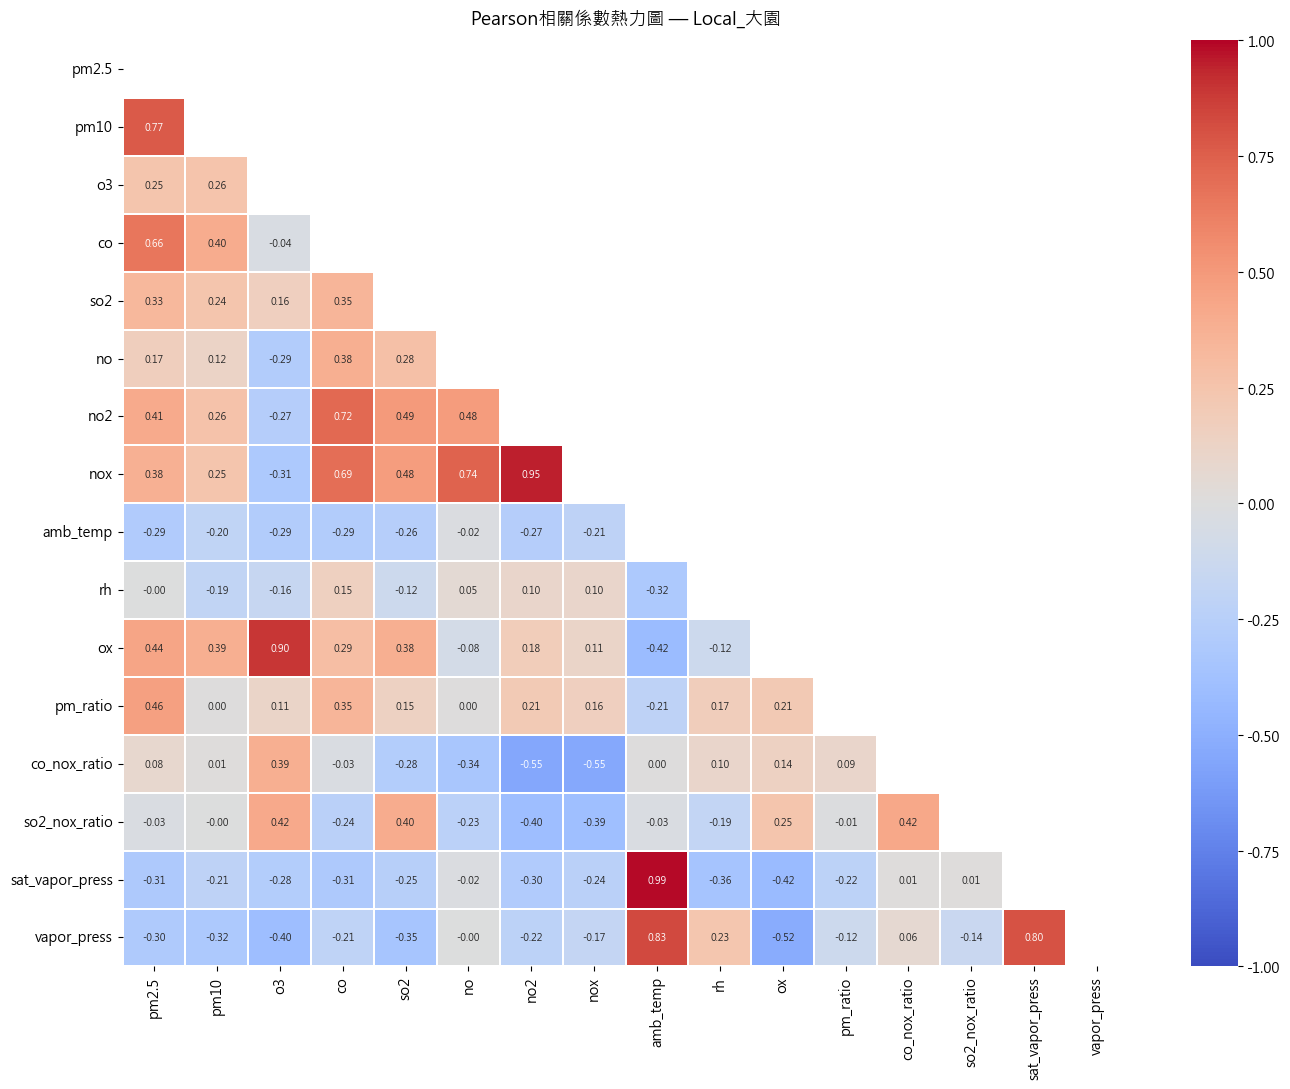

[已儲存] heatmap_Local_大園.png
⠼ 模組 A - 繪製 Local [觀音] Heatmap...

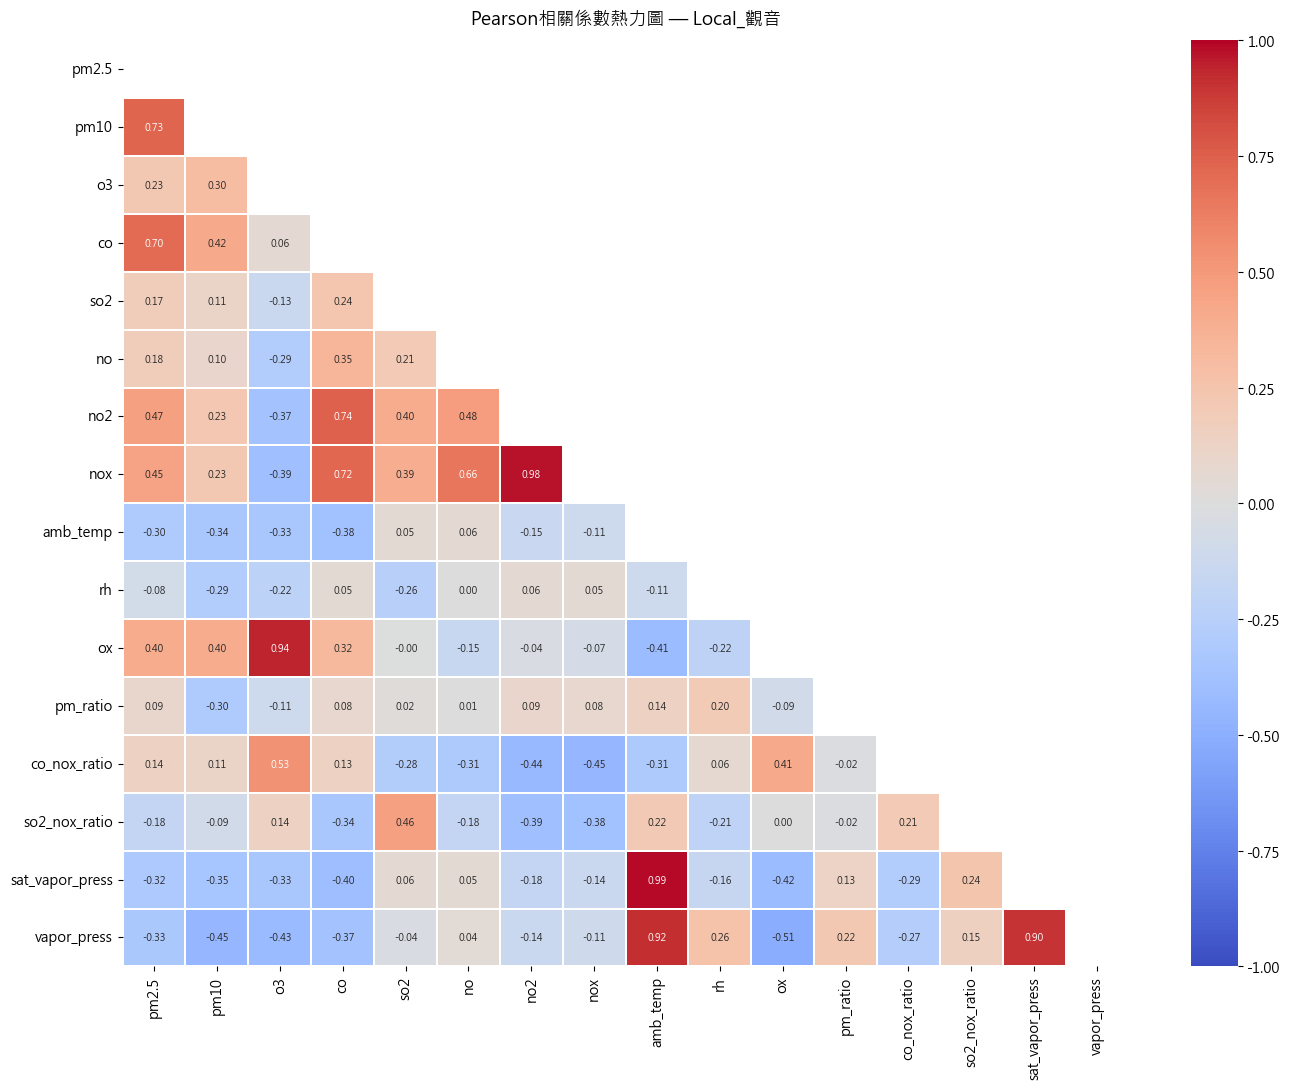

[已儲存] heatmap_Local_觀音.png
⠏ 模組 A - 繪製 Local [龍潭] Heatmap...

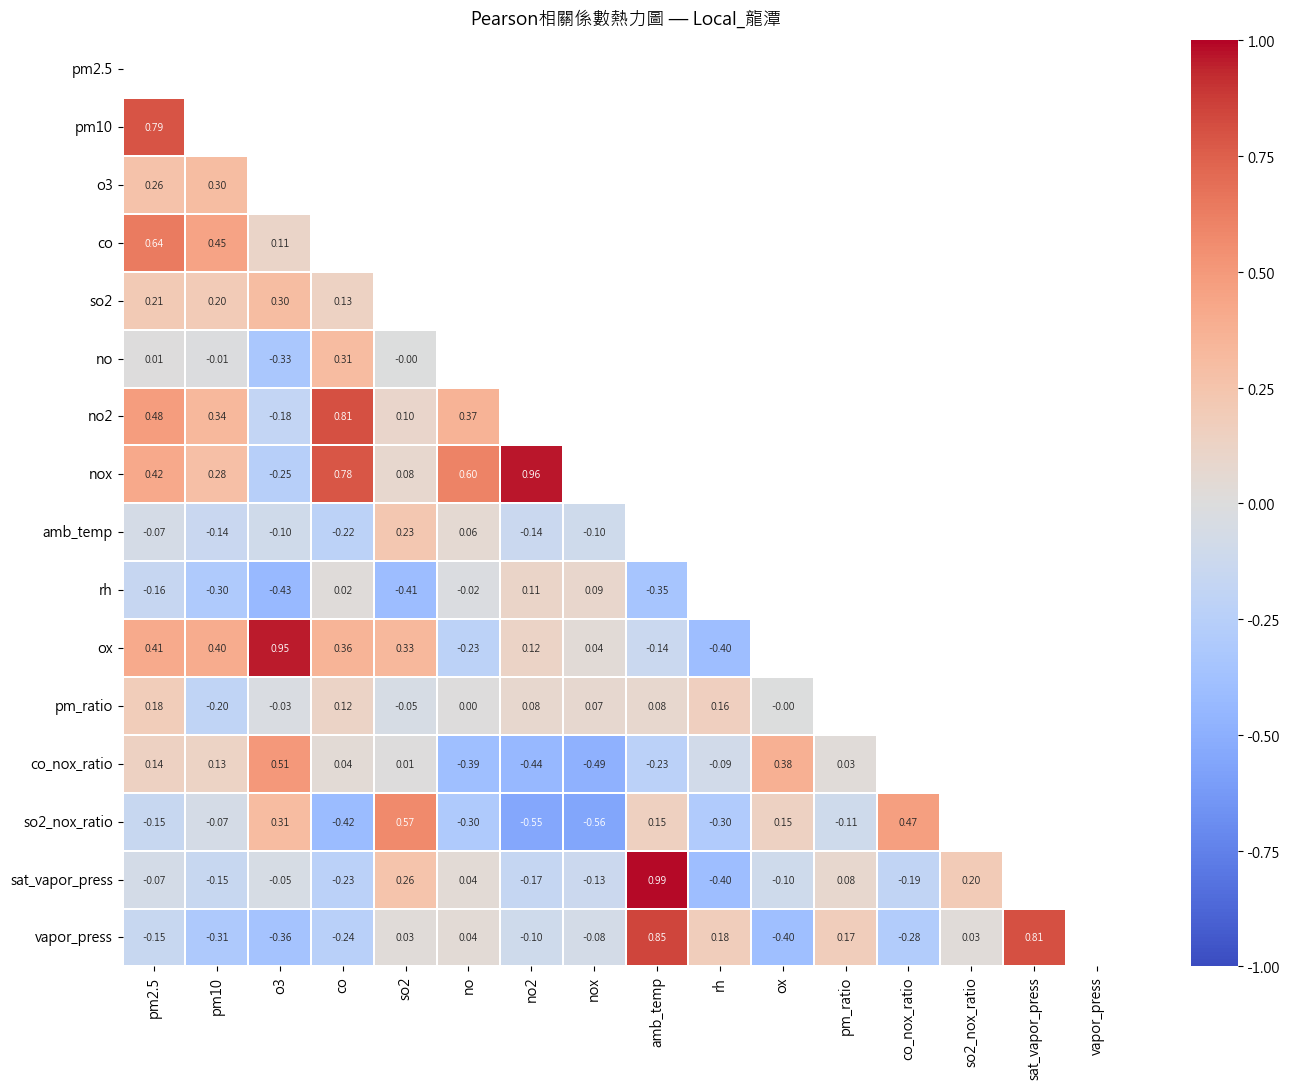

[已儲存] heatmap_Local_龍潭.png
⠋ 模組 A - 繪製 Local [龍潭] Heatmap...
✓ 模組 A 全部 Heatmap 繪製完成！

==================== 執行模組 B：Pearson 特徵排行 ====================
⠸ 模組 B - 計算 Global 特徵 vs 目標相關性...0m

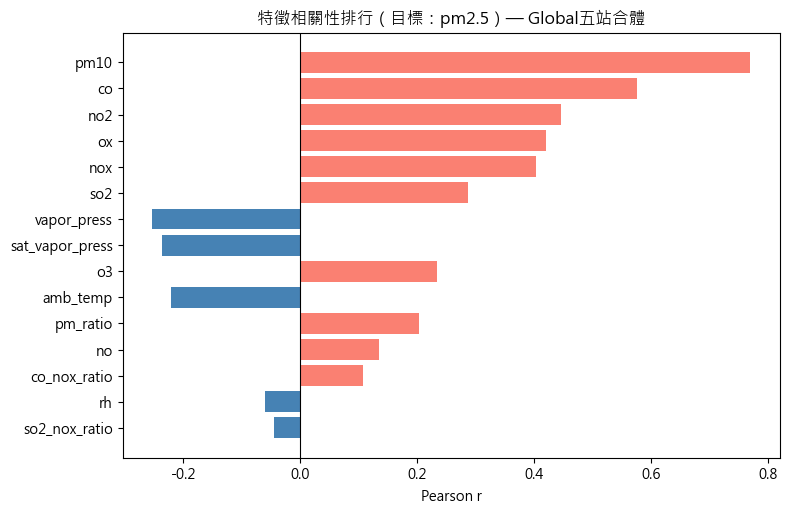

[已儲存] corr_rank_Global五站合體_pm2.5.png
m⠸ 模組 B - 計算 Global 特徵 vs 目標相關性...
[Global五站合體] 特徵 vs pm2.5 相關性排行：
 排名              特徵      相關係數l 特徵 vs 目標相關性...
  1            pm10  0.769305
  2              co  0.574985
  3             no2  0.445092
  4              ox  0.420540
  5             nox  0.403441
  6             so2  0.286160
  7     vapor_press -0.252914
  8 sat_vapor_press -0.237371
  9              o3  0.233057
 10        amb_temp -0.221845
 11        pm_ratio  0.203641
 12              no  0.134034
 13    co_nox_ratio  0.106898
 14              rh -0.060755
 15   so2_nox_ratio -0.045143
⠧ 模組 B - 計算 Global 特徵 vs 目標相關性...

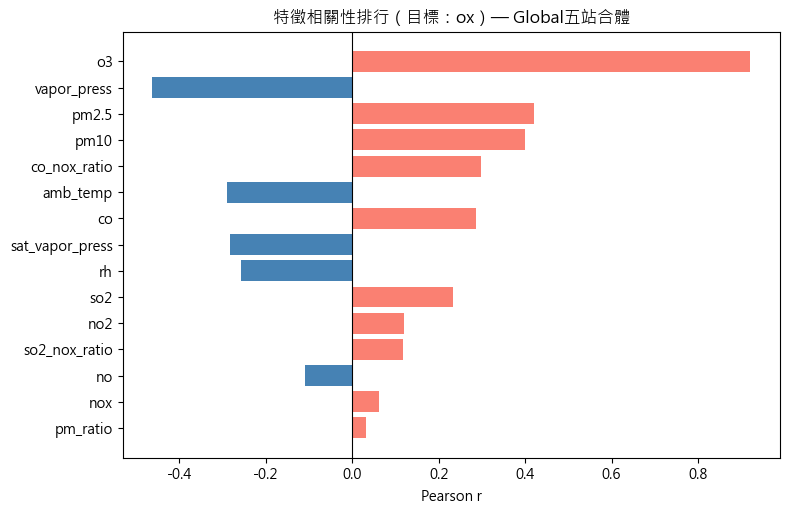

[已儲存] corr_rank_Global五站合體_ox.png
m⠇ 模組 B - 計算 Global 特徵 vs 目標相關性...
[Global五站合體] 特徵 vs ox 相關性排行：
 排名              特徵      相關係數l 特徵 vs 目標相關性...
  1              o3  0.920511
  2     vapor_press -0.461846
  3           pm2.5  0.420540
  4            pm10  0.400611
  5    co_nox_ratio  0.297556
  6        amb_temp -0.290452
  7              co  0.287076
  8 sat_vapor_press -0.281551
  9              rh -0.257686
 10             so2  0.232166
 11             no2  0.119533
 12   so2_nox_ratio  0.117840
 13              no -0.110056
 14             nox  0.062083
 15        pm_ratio  0.032837
⠹ 模組 B - 計算 Local [桃園] 特徵 vs 目標相關性...

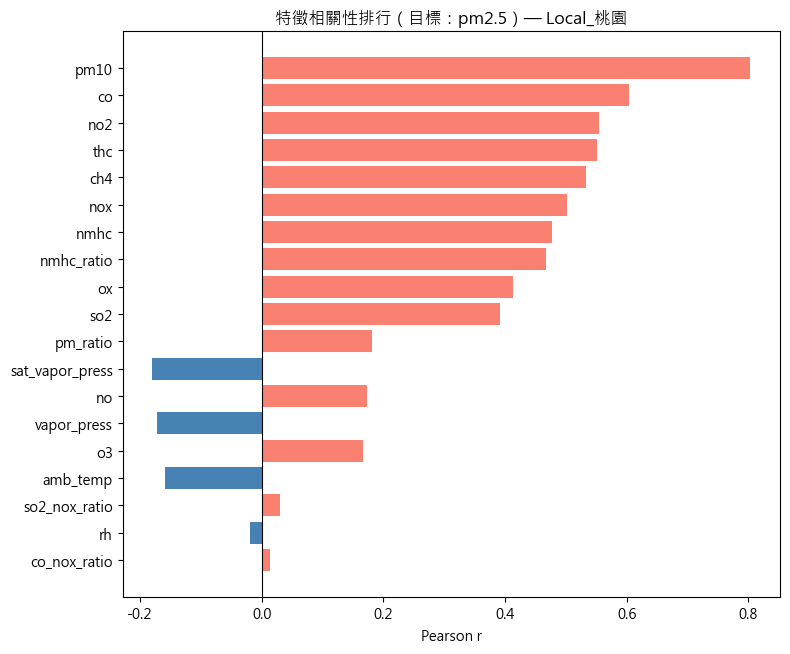

[已儲存] corr_rank_Local_桃園_pm2.5.png
m⠸ 模組 B - 計算 Local [桃園] 特徵 vs 目標相關性...
[Local_桃園] 特徵 vs pm2.5 相關性排行：
 排名              特徵      相關係數 [桃園] 特徵 vs 目標相關性...
  1            pm10  0.802984
  2              co  0.604043
  3             no2  0.554747
  4             thc  0.551668
  5             ch4  0.533511
  6             nox  0.501431
  7            nmhc  0.476795
  8      nmhc_ratio  0.466974
  9              ox  0.412617
 10             so2  0.391727
 11        pm_ratio  0.181980
 12 sat_vapor_press -0.179575
 13              no  0.173202
 14     vapor_press -0.172472
 15              o3  0.166992
 16        amb_temp -0.159798
 17   so2_nox_ratio  0.030059
 18              rh -0.019108
 19    co_nox_ratio  0.013220
⠇ 模組 B - 計算 Local [桃園] 特徵 vs 目標相關性...

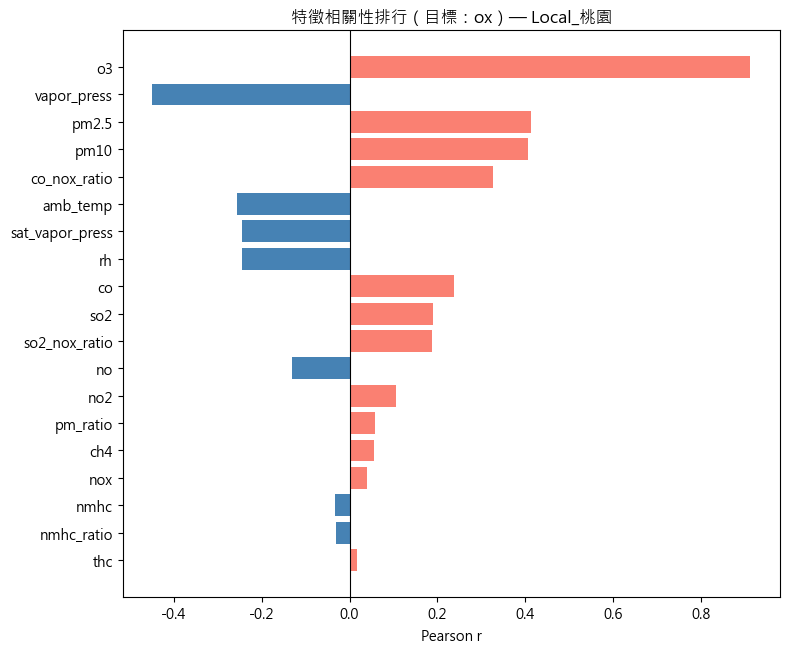

[已儲存] corr_rank_Local_桃園_ox.png
m⠏ 模組 B - 計算 Local [桃園] 特徵 vs 目標相關性...
[Local_桃園] 特徵 vs ox 相關性排行：
 排名              特徵      相關係數 [桃園] 特徵 vs 目標相關性...
  1              o3  0.912744
  2     vapor_press -0.449011
  3           pm2.5  0.412617
  4            pm10  0.406963
  5    co_nox_ratio  0.327008
  6        amb_temp -0.256500
  7 sat_vapor_press -0.245529
  8              rh -0.244035
  9              co  0.237245
 10             so2  0.190377
 11   so2_nox_ratio  0.188781
 12              no -0.131482
 13             no2  0.105270
 14        pm_ratio  0.058981
 15             ch4  0.055064
 16             nox  0.038967
 17            nmhc -0.033137
 18      nmhc_ratio -0.030294
 19             thc  0.017157
⠸ 模組 B - 計算 Local [平鎮] 特徵 vs 目標相關性...

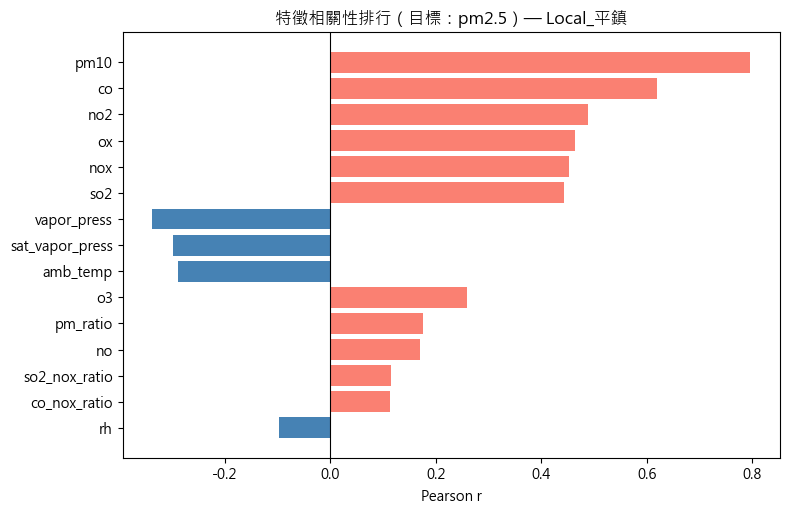

[已儲存] corr_rank_Local_平鎮_pm2.5.png
⠼ 模組 B - 計算 Local [平鎮] 特徵 vs 目標相關性...
[Local_平鎮] 特徵 vs pm2.5 相關性排行：
 排名              特徵      相關係數 [平鎮] 特徵 vs 目標相關性...
  1            pm10  0.795684
  2              co  0.620079
  3             no2  0.488829
  4              ox  0.463169
  5             nox  0.451852
  6             so2  0.443669
  7     vapor_press -0.337071
  8 sat_vapor_press -0.298721
  9        amb_temp -0.289083
 10              o3  0.259717
 11        pm_ratio  0.175703
 12              no  0.170674
 13   so2_nox_ratio  0.115939
 14    co_nox_ratio  0.113583
 15              rh -0.097770
⠏ 模組 B - 計算 Local [平鎮] 特徵 vs 目標相關性...

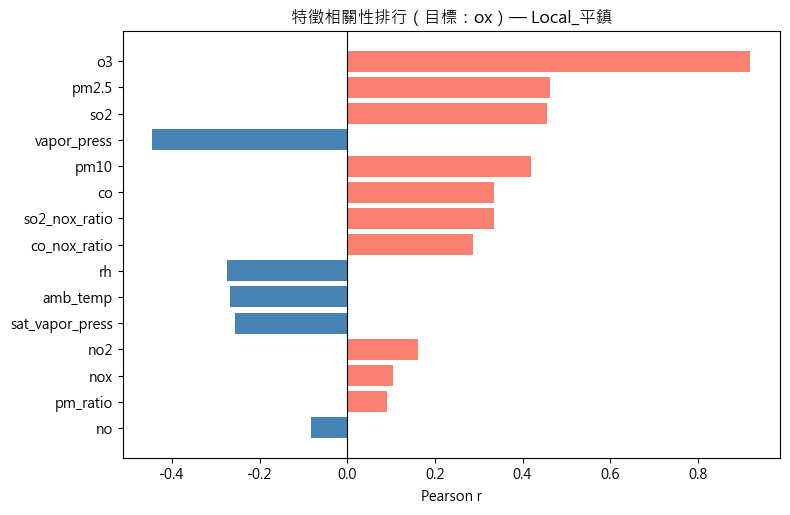

[已儲存] corr_rank_Local_平鎮_ox.png
m⠋ 模組 B - 計算 Local [平鎮] 特徵 vs 目標相關性...
[Local_平鎮] 特徵 vs ox 相關性排行：
 排名              特徵      相關係數 [平鎮] 特徵 vs 目標相關性...
  1              o3  0.919298
  2           pm2.5  0.463169
  3             so2  0.456202
  4     vapor_press -0.444532
  5            pm10  0.419526
  6              co  0.334660
  7   so2_nox_ratio  0.334529
  8    co_nox_ratio  0.286906
  9              rh -0.275120
 10        amb_temp -0.268598
 11 sat_vapor_press -0.257208
 12             no2  0.160978
 13             nox  0.104099
 14        pm_ratio  0.090375
 15              no -0.082042
⠼ 模組 B - 計算 Local [大園] 特徵 vs 目標相關性...

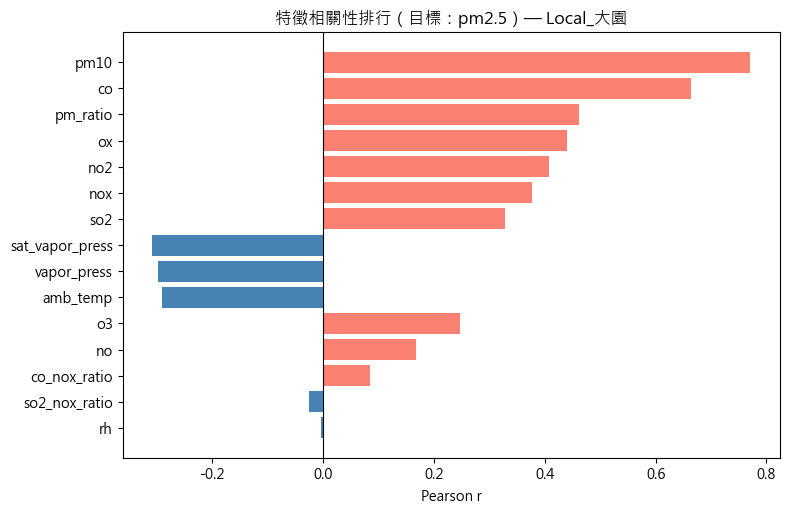

[已儲存] corr_rank_Local_大園_pm2.5.png
m⠴ 模組 B - 計算 Local [大園] 特徵 vs 目標相關性...
[Local_大園] 特徵 vs pm2.5 相關性排行：
 排名              特徵      相關係數 [大園] 特徵 vs 目標相關性...
  1            pm10  0.770513
  2              co  0.663770
  3        pm_ratio  0.461605
  4              ox  0.439256
  5             no2  0.408427
  6             nox  0.376070
  7             so2  0.328219
  8 sat_vapor_press -0.308005
  9     vapor_press -0.298331
 10        amb_temp -0.291007
 11              o3  0.246431
 12              no  0.167971
 13    co_nox_ratio  0.083972
 14   so2_nox_ratio -0.026355
 15              rh -0.004603
⠏ 模組 B - 計算 Local [大園] 特徵 vs 目標相關性...

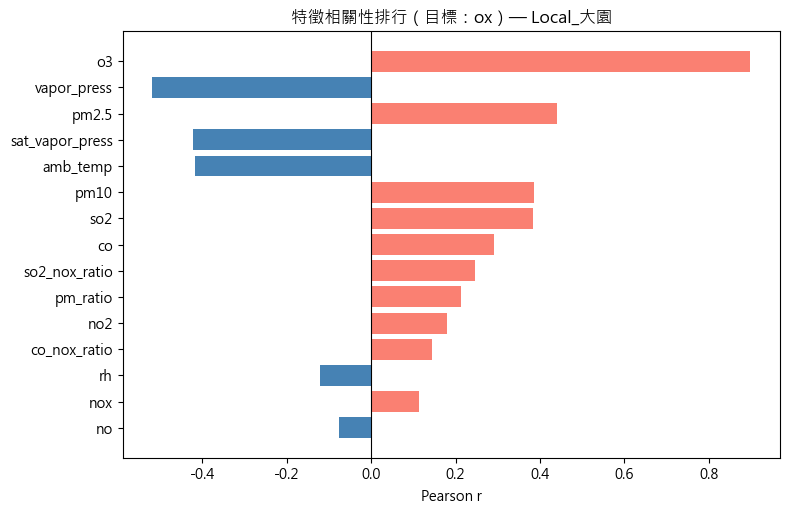

[已儲存] corr_rank_Local_大園_ox.png
m⠋ 模組 B - 計算 Local [大園] 特徵 vs 目標相關性...
[Local_大園] 特徵 vs ox 相關性排行：
 排名              特徵      相關係數 [大園] 特徵 vs 目標相關性...
  1              o3  0.897869
  2     vapor_press -0.517840
  3           pm2.5  0.439256
  4 sat_vapor_press -0.422277
  5        amb_temp -0.416869
  6            pm10  0.385048
  7             so2  0.383624
  8              co  0.290492
  9   so2_nox_ratio  0.245560
 10        pm_ratio  0.211888
 11             no2  0.180223
 12    co_nox_ratio  0.144770
 13              rh -0.120717
 14             nox  0.112460
 15              no -0.076498
⠼ 模組 B - 計算 Local [觀音] 特徵 vs 目標相關性...

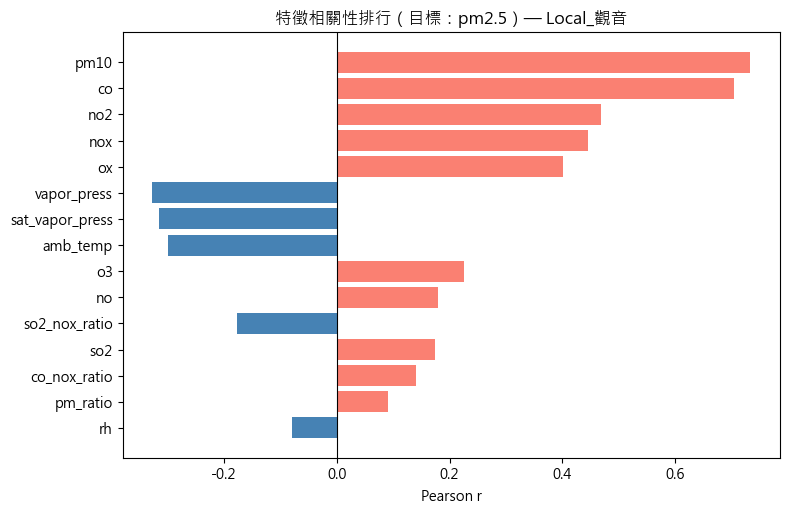

[已儲存] corr_rank_Local_觀音_pm2.5.png
m⠼ 模組 B - 計算 Local [觀音] 特徵 vs 目標相關性...
[Local_觀音] 特徵 vs pm2.5 相關性排行：
 排名              特徵      相關係數 [觀音] 特徵 vs 目標相關性...
  1            pm10  0.732644
  2              co  0.704906
  3             no2  0.467576
  4             nox  0.445824
  5              ox  0.401336
  6     vapor_press -0.326467
  7 sat_vapor_press -0.315761
  8        amb_temp -0.298622
  9              o3  0.225322
 10              no  0.179368
 11   so2_nox_ratio -0.177297
 12             so2  0.174594
 13    co_nox_ratio  0.140010
 14        pm_ratio  0.090958
 15              rh -0.079482
⠏ 模組 B - 計算 Local [觀音] 特徵 vs 目標相關性...

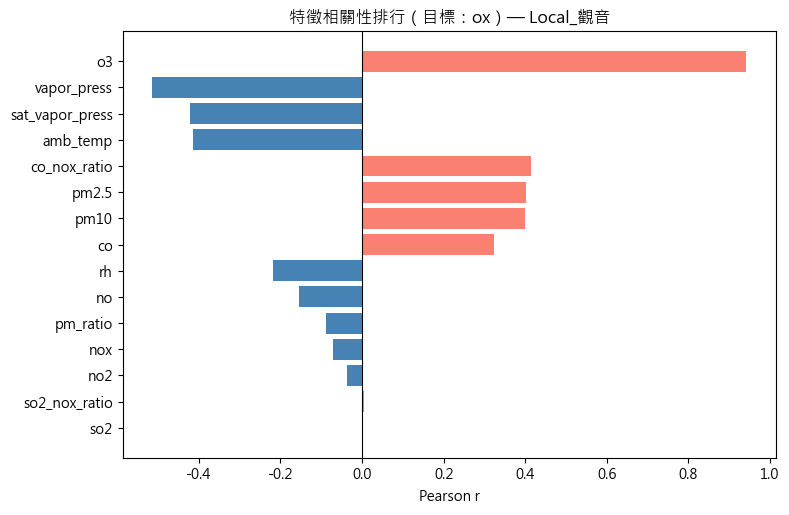

[已儲存] corr_rank_Local_觀音_ox.png
m⠋ 模組 B - 計算 Local [觀音] 特徵 vs 目標相關性...
[Local_觀音] 特徵 vs ox 相關性排行：
 排名              特徵      相關係數 [觀音] 特徵 vs 目標相關性...
  1              o3  0.942229
  2     vapor_press -0.514074
  3 sat_vapor_press -0.421568
  4        amb_temp -0.414664
  5    co_nox_ratio  0.414214
  6           pm2.5  0.401336
  7            pm10  0.400048
  8              co  0.323071
  9              rh -0.217016
 10              no -0.154255
 11        pm_ratio -0.087919
 12             nox -0.069940
 13             no2 -0.037905
 14   so2_nox_ratio  0.003700
 15             so2 -0.001097
⠼ 模組 B - 計算 Local [龍潭] 特徵 vs 目標相關性...

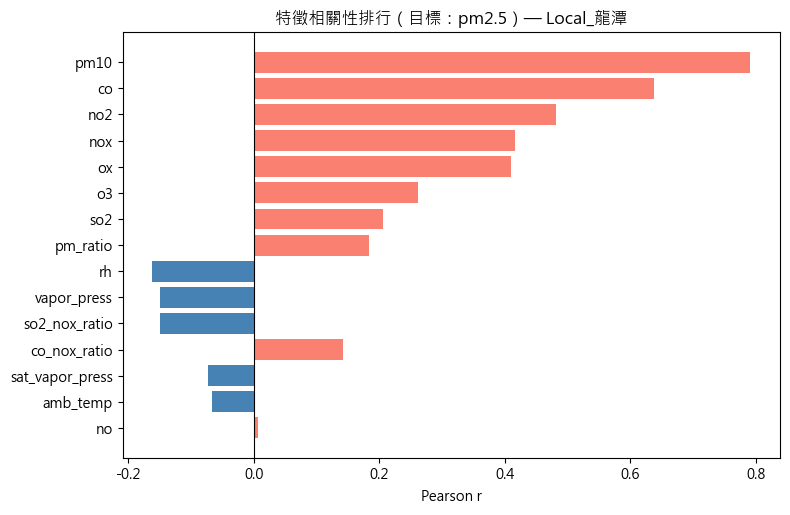

[已儲存] corr_rank_Local_龍潭_pm2.5.png
m⠴ 模組 B - 計算 Local [龍潭] 特徵 vs 目標相關性...
[Local_龍潭] 特徵 vs pm2.5 相關性排行：
 排名              特徵      相關係數 [龍潭] 特徵 vs 目標相關性...
  1            pm10  0.791309
  2              co  0.637926
  3             no2  0.481979
  4             nox  0.416302
  5              ox  0.410701
  6              o3  0.262328
  7             so2  0.206307
  8        pm_ratio  0.184089
  9              rh -0.161434
 10     vapor_press -0.150174
 11   so2_nox_ratio -0.148666
 12    co_nox_ratio  0.142986
 13 sat_vapor_press -0.072832
 14        amb_temp -0.066528
 15              no  0.007474
⠏ 模組 B - 計算 Local [龍潭] 特徵 vs 目標相關性...

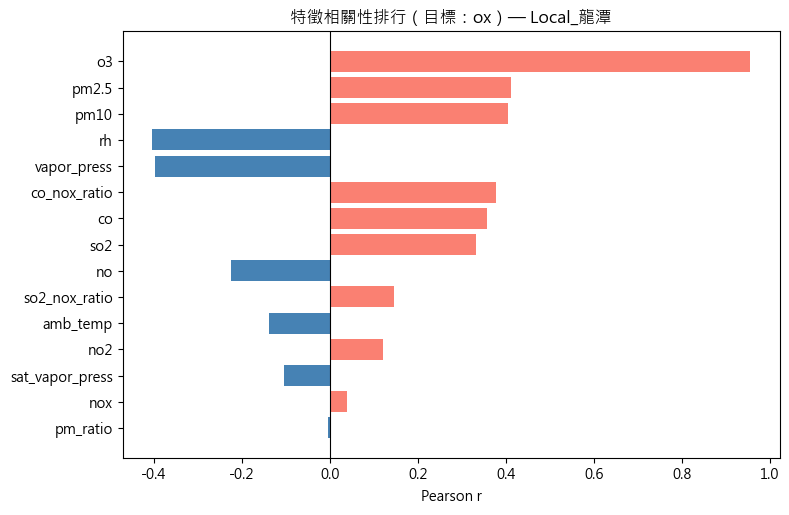

[已儲存] corr_rank_Local_龍潭_ox.png
m⠏ 模組 B - 計算 Local [龍潭] 特徵 vs 目標相關性...
[Local_龍潭] 特徵 vs ox 相關性排行：
 排名              特徵      相關係數 [龍潭] 特徵 vs 目標相關性...
  1              o3  0.954766
  2           pm2.5  0.410701
  3            pm10  0.403739
  4              rh -0.403543
  5     vapor_press -0.397582
  6    co_nox_ratio  0.377925
  7              co  0.357133
  8             so2  0.332374
  9              no -0.225305
 10   so2_nox_ratio  0.145182
 11        amb_temp -0.139495
 12             no2  0.119796
 13 sat_vapor_press -0.104341
 14             nox  0.037733
 15        pm_ratio -0.004511
⠏ 模組 B - 計算 Local [龍潭] 特徵 vs 目標相關性...
✓ 模組 B 特徵相關性排行繪製完成！

==================== 執行模組 C：跨站 PM2.5 時序相關性 (含紅色趨勢線) 
⠸ 模組 C - 計算 [觀音 → 大園] 時序相關性...0m

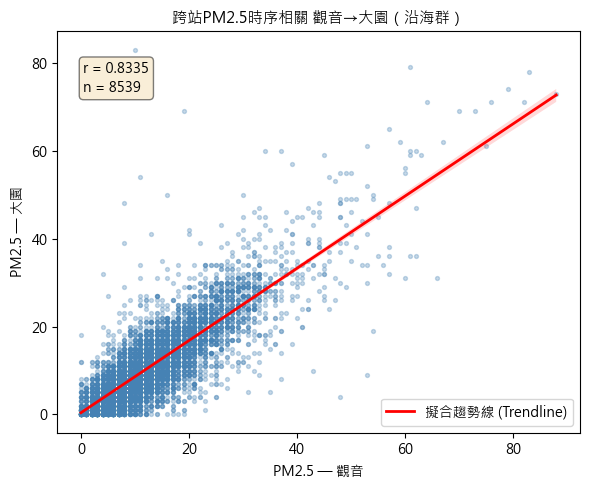

[已儲存] cross_corr_觀音_大園.png
⠏ 模組 C - 計算 [大園 → 觀音] 時序相關性...

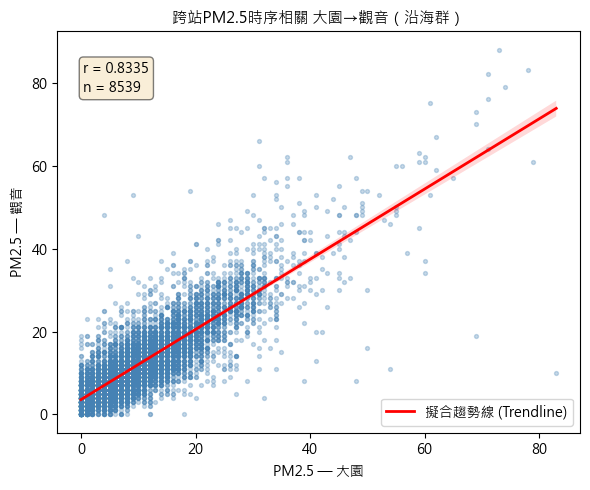

[已儲存] cross_corr_大園_觀音.png
⠴ 模組 C - 計算 [桃園 → 平鎮] 時序相關性...

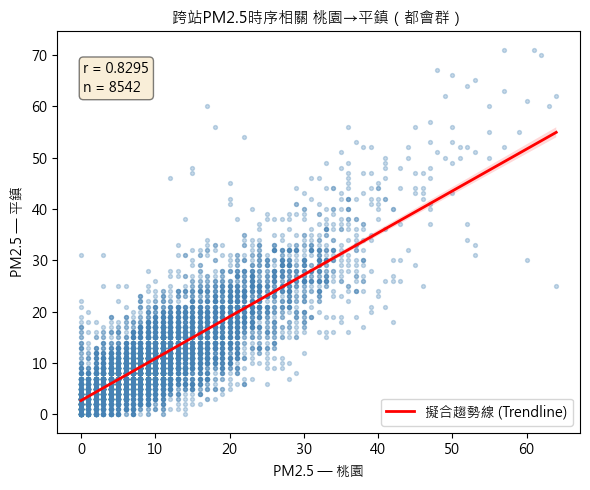

[已儲存] cross_corr_桃園_平鎮.png
⠋ 模組 C - 計算 [平鎮 → 桃園] 時序相關性...

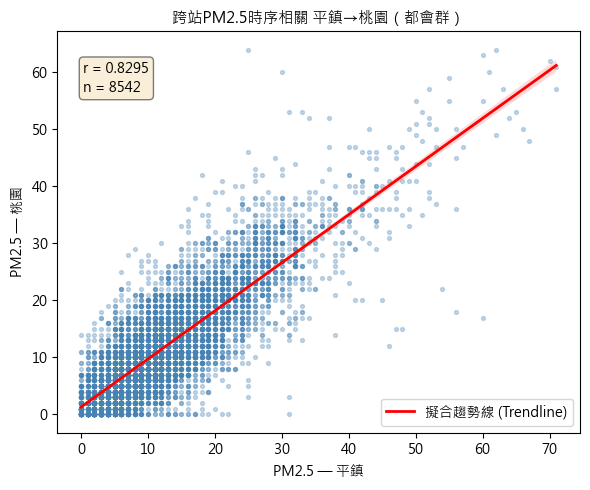

[已儲存] cross_corr_平鎮_桃園.png
m⠙ 模組 C - 計算 [平鎮 → 桃園] 時序相關性...
[跨站PM2.5時序相關性彙總表]
 群組 訓練站 測試站  Pearson_r  樣本數 → 桃園] 時序相關性...
沿海群  觀音  大園     0.8335 8539
沿海群  大園  觀音     0.8335 8539
都會群  桃園  平鎮     0.8295 8542
都會群  平鎮  桃園     0.8295 8542
⠙ 模組 C - 計算 [平鎮 → 桃園] 時序相關性...
✓ 模組 C 跨站時序相關分析完成！

==================== 執行模組 D：VIF 共線性檢查 ====================
⠦ 模組 D - 計算 Global VIF...0m
[Global五站合體] VIF共線性檢查：
             特徵      VIFGlobal VIF...
            nox 69358.38
            no2 48887.04
             no  3188.37
       amb_temp   683.51
sat_vapor_press   515.49
    vapor_press   106.65
             rh    62.68
             co    28.55
   co_nox_ratio    22.30
            so2    10.00
  so2_nox_ratio     8.97
             o3     8.85
           pm10     4.29
       pm_ratio     4.12
⠹ 模組 D - 計算 Global VIF...

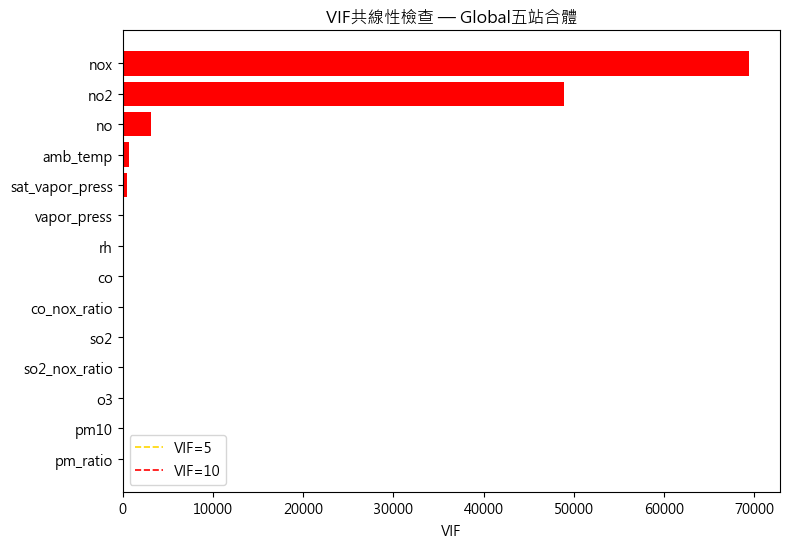

[已儲存] vif_Global五站合體.png
⠴ 模組 D - 計算 Local [桃園] VIF...
[Local_桃園] VIF共線性檢查：
             特徵         VIFal [桃園] VIF...
            thc 18601214.91
            ch4 16815861.88
            nox   106071.78
            no2    74864.49
           nmhc    74215.30
             no     5099.88
       amb_temp     1146.07
sat_vapor_press      499.84
    vapor_press      262.83
             rh      220.68
     nmhc_ratio      128.18
             co       59.46
   co_nox_ratio       41.60
            so2       12.57
  so2_nox_ratio       11.55
             o3        9.18
           pm10        4.84
       pm_ratio        3.46
⠸ 模組 D - 計算 Local [桃園] VIF...

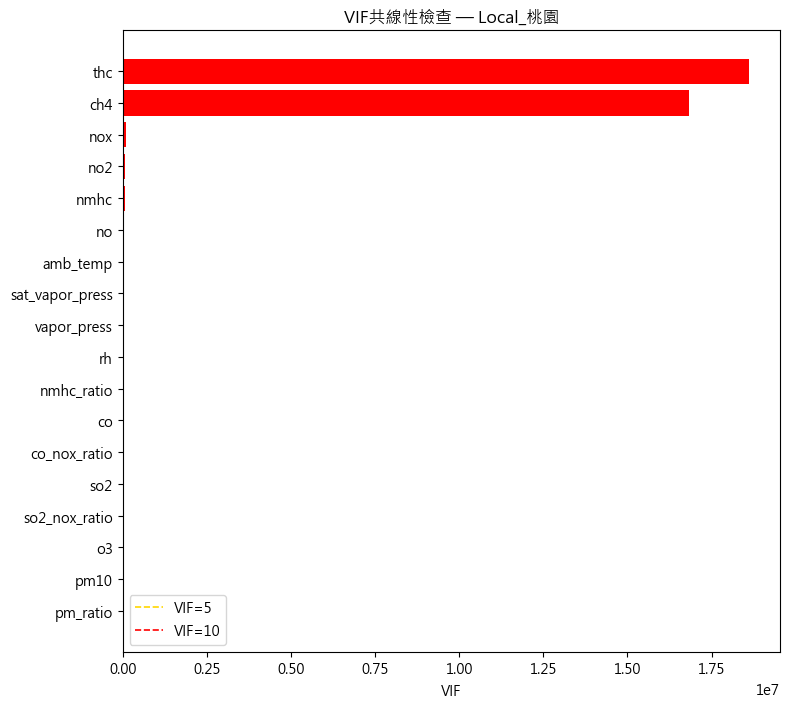

[已儲存] vif_Local_桃園.png
⠴ 模組 D - 計算 Local [平鎮] VIF...
[Local_平鎮] VIF共線性檢查：
             特徵      VIFLocal [平鎮] VIF...
            nox 67075.81
            no2 47658.55
             no  2839.11
       amb_temp   730.53
sat_vapor_press   554.80
    vapor_press   118.52
             rh    73.81
             co    52.06
   co_nox_ratio    43.38
            so2    16.25
  so2_nox_ratio    13.91
             o3     9.10
       pm_ratio     4.82
           pm10     4.57
⠙ 模組 D - 計算 Local [平鎮] VIF...

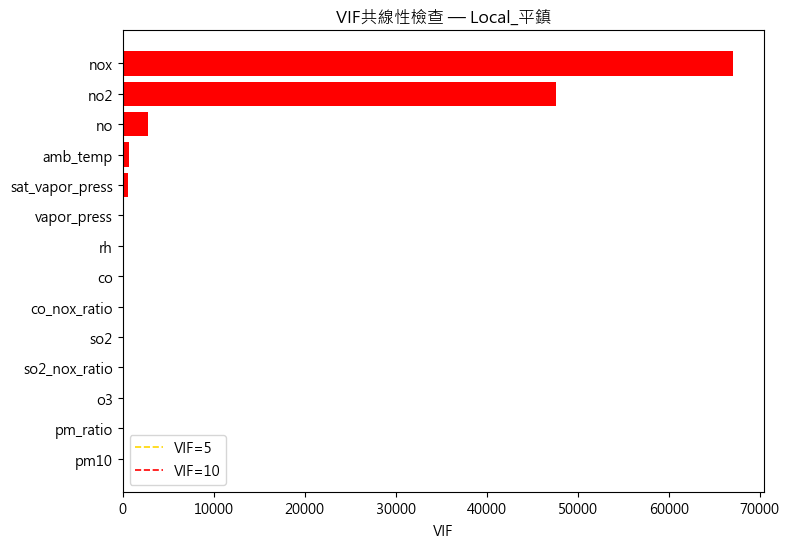

[已儲存] vif_Local_平鎮.png
⠸ 模組 D - 計算 Local [大園] VIF...
[Local_大園] VIF共線性檢查：
             特徵      VIFLocal [大園] VIF...
            nox 95805.02
            no2 64259.04
             no  5623.72
       amb_temp   832.44
sat_vapor_press   627.82
    vapor_press   104.86
             rh    61.46
             co    23.44
   co_nox_ratio    16.54
  so2_nox_ratio    14.05
            so2    13.20
             o3     9.15
       pm_ratio     5.55
           pm10     4.71
⠇ 模組 D - 計算 Local [大園] VIF...

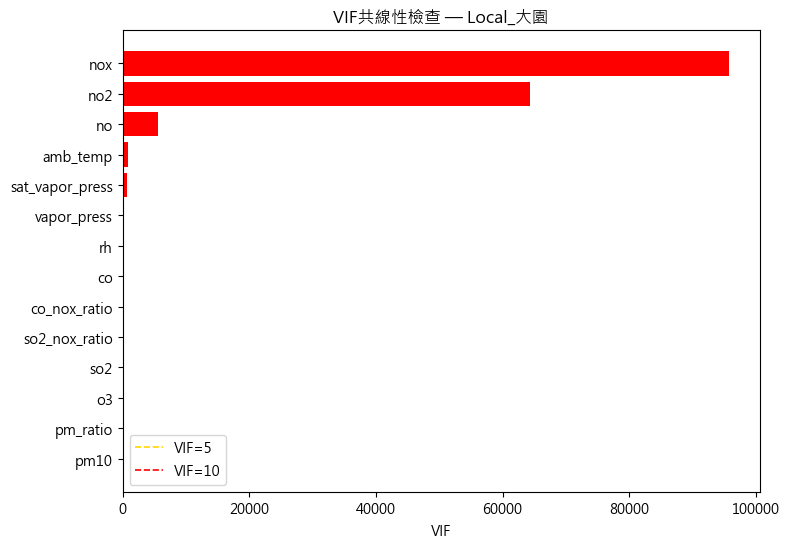

[已儲存] vif_Local_大園.png
⠙ 模組 D - 計算 Local [觀音] VIF...
[Local_觀音] VIF共線性檢查：
             特徵      VIFLocal [觀音] VIF...
            nox 41581.22
            no2 31332.08
             no  1244.15
       amb_temp   968.52
sat_vapor_press   760.85
    vapor_press   161.11
             rh    82.28
             co    31.93
   co_nox_ratio    18.87
             o3    11.39
            so2    10.15
  so2_nox_ratio     9.96
           pm10     4.42
       pm_ratio     4.25
⠴ 模組 D - 計算 Local [觀音] VIF...

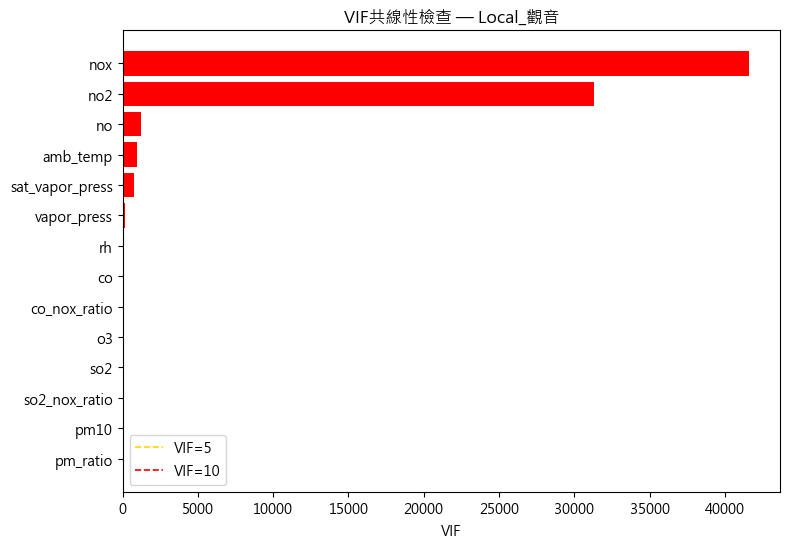

[已儲存] vif_Local_觀音.png
⠏ 模組 D - 計算 Local [龍潭] VIF...
[Local_龍潭] VIF共線性檢查：
             特徵      VIFLocal [龍潭] VIF...
            nox 45600.89
            no2 32801.94
             no  1677.89
       amb_temp   611.90
sat_vapor_press   465.45
    vapor_press   136.15
             co    79.36
             rh    73.80
   co_nox_ratio    57.28
            so2    24.91
  so2_nox_ratio    21.81
             o3    10.97
       pm_ratio     5.76
           pm10     4.99
⠸ 模組 D - 計算 Local [龍潭] VIF...

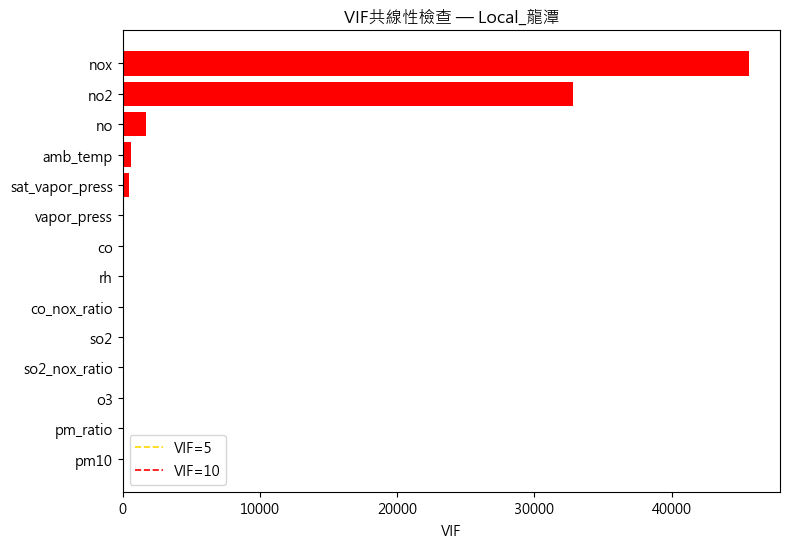

[已儲存] vif_Local_龍潭.png
⠼ 模組 D - 計算 Local [龍潭] VIF...
✓ 模組 D VIF 檢查全部完成！

EDA相關性分析完成 — 輸出檔案清單
模組A Heatmap：
  heatmap_Global五站合體.png
  heatmap_Local_桃園.png
  heatmap_Local_平鎮.png
  heatmap_Local_大園.png
  heatmap_Local_觀音.png
  heatmap_Local_龍潭.png

模組B 特徵排行：
  corr_rank_Global五站合體_pm2.5.png
  corr_rank_Global五站合體_ox.png
  corr_rank_Local_桃園_pm2.5.png
  corr_rank_Local_桃園_ox.png
  corr_rank_Local_平鎮_pm2.5.png
  corr_rank_Local_平鎮_ox.png
  corr_rank_Local_大園_pm2.5.png
  corr_rank_Local_大園_ox.png
  corr_rank_Local_觀音_pm2.5.png
  corr_rank_Local_觀音_ox.png
  corr_rank_Local_龍潭_pm2.5.png
  corr_rank_Local_龍潭_ox.png

模組C 跨站時序 (含紅色擬合趨勢線)：
  cross_corr_觀音_大園.png
  cross_corr_大園_觀音.png
  cross_corr_桃園_平鎮.png
  cross_corr_平鎮_桃園.png

模組D VIF：
  vif_Global五站合體.png
  vif_Local_桃園.png
  vif_Local_平鎮.png
  vif_Local_大園.png
  vif_Local_觀音.png
  vif_Local_龍潭.png

所有圖表與數值表格已輸出完畢。


In [18]:
# ==============================================================================
# 桃園空品監測資料 EDA 相關性分析
# SDD 模組：A. Pearson Heatmap | B. Pearson 特徵排行 | C. 跨站時序(含紅色趨勢線) | D. VIF 共線性
# ==============================================================================

import warnings
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from statsmodels.stats.outliers_influence import variance_inflation_factor

warnings.filterwarnings("ignore")

# 1. 載入 Rich Console (使用 force_jupyter=False 預防死鎖)
try:
    from rich.console import Console

    console = Console(force_jupyter=False)
    HAS_RICH = True
except ImportError:
    HAS_RICH = False
    print("💡 提示：可安裝 rich 套件以獲得動態 Loading 動畫效果 (pip install rich)")

# 設定繪圖中文字型
plt.rcParams["font.sans-serif"] = [
    "Microsoft JhengHei",
    "SimHei",
    "Noto Sans CJK TC",
    "Arial",
]
plt.rcParams["axes.unicode_minus"] = False

# ------------------------------------------------------------------------------
# 輔助印出函數 (相容 RichConsole 與 普通 print)
# ------------------------------------------------------------------------------


def log(msg):
    if HAS_RICH:
        console.print(msg)
    else:
        print(msg)


# ------------------------------------------------------------------------------
# 三、前置處理與資料載入
# ------------------------------------------------------------------------------
if HAS_RICH:
    status = console.status(
        "[bold cyan]正在載入五站與桃園獨立 CSV 資料...", spinner="dots"
    )
    status.start()

df_5station = pd.read_csv("2025桃園五站空品監測資料_精簡20欄合體版.csv")
df_taoyuan = pd.read_csv("2025桃園站空品監測資料_完整科學指標擴增版.csv")

# 統一處理 publishtime
df_5station["publishtime"] = pd.to_datetime(df_5station["publishtime"])
df_taoyuan["publishtime"] = pd.to_datetime(df_taoyuan["publishtime"])

# 移除非數值欄位（用於相關性計算）
exclude_cols = ["sitename", "publishtime"]

# 定義各站對應資料
station_dfs = {
    "桃園": df_taoyuan,
    "平鎮": df_5station[df_5station["sitename"] == "平鎮"].copy(),
    "大園": df_5station[df_5station["sitename"] == "大園"].copy(),
    "觀音": df_5station[df_5station["sitename"] == "觀音"].copy(),
    "龍潭": df_5station[df_5station["sitename"] == "龍潭"].copy(),
}

# Global（五站合體，移除 sitename 與 publishtime 欄位）
df_global = df_5station.drop(
    columns=[c for c in exclude_cols if c in df_5station.columns]
)

targets = ["pm2.5", "ox"]

if HAS_RICH:
    status.stop()
log("[green]✓ 資料前置處理完成！[/green]\n")

# ------------------------------------------------------------------------------
# 四、模組 A：Pearson Heatmap（全特徵間相關性）
# ------------------------------------------------------------------------------
log("==================== 執行模組 A：Pearson Heatmap ====================")


def plot_heatmap(df_numeric, title, figsize=(14, 11)):
    df_num = df_numeric.select_dtypes(include=[np.number])
    corr = df_num.corr(method="pearson")

    # 下三角遮罩
    mask = np.zeros_like(corr, dtype=bool)
    mask[np.triu_indices_from(mask)] = True

    fig, ax = plt.subplots(figsize=figsize)
    sns.heatmap(
        corr,
        mask=mask,
        annot=True,
        fmt=".2f",
        cmap="coolwarm",
        vmin=-1,
        vmax=1,
        annot_kws={"size": 7},
        linewidths=0.3,
        ax=ax,
    )
    ax.set_title(f"Pearson相關係數熱力圖 — {title}", fontsize=13, pad=12)
    plt.tight_layout()
    plt.savefig(f"heatmap_{title}.png", dpi=150)
    plt.show()
    log(f"[已儲存] heatmap_{title}.png")


if HAS_RICH:
    status = console.status(
        "[bold cyan]模組 A - 繪製 Global Heatmap...", spinner="dots"
    )
    status.start()

plot_heatmap(df_global, "Global五站合體")

for station, df in station_dfs.items():
    if HAS_RICH:
        status.update(f"[bold cyan]模組 A - 繪製 Local [{station}] Heatmap...")
    df_num = df.drop(columns=[c for c in exclude_cols if c in df.columns])
    plot_heatmap(df_num, f"Local_{station}")

if HAS_RICH:
    status.stop()
log("[green]✓ 模組 A 全部 Heatmap 繪製完成！[/green]\n")

# ------------------------------------------------------------------------------
# 五、模組 B：Pearson 排行（特徵 vs 目標變數 - 原始長條圖）
# ------------------------------------------------------------------------------
log("==================== 執行模組 B：Pearson 特徵排行 ====================")


def plot_feature_correlation_rank(df_numeric, title):
    """計算特徵與目標之相關性排行，繪製原始水平長條圖"""
    df_num = df_numeric.select_dtypes(include=[np.number])
    results = {}

    for target in targets:
        if target not in df_num.columns:
            continue
        features = [c for c in df_num.columns if c != target]
        corr_series = df_num[features].corrwith(
            df_num[target], method="pearson"
        )
        corr_df = corr_series.reset_index()
        corr_df.columns = ["特徵", "相關係數"]
        corr_df["絕對值"] = corr_df["相關係數"].abs()
        corr_df = corr_df.sort_values("絕對值", ascending=False).reset_index(
            drop=True
        )
        corr_df["排名"] = corr_df.index + 1
        results[target] = corr_df

        # 繪製原始 barh 條形圖
        colors = [
            "salmon" if v > 0 else "steelblue" for v in corr_df["相關係數"]
        ]
        fig, ax = plt.subplots(figsize=(8, max(5, len(features) * 0.35)))
        ax.barh(
            corr_df["特徵"][::-1], corr_df["相關係數"][::-1], color=colors[::-1]
        )
        ax.axvline(0, color="black", linewidth=0.8)
        ax.set_xlabel("Pearson r")
        ax.set_title(f"特徵相關性排行（目標：{target}）— {title}", fontsize=12)
        plt.tight_layout()
        plt.savefig(f"corr_rank_{title}_{target}.png", dpi=150)
        plt.show()
        log(f"[已儲存] corr_rank_{title}_{target}.png")

        # 數值表格
        log(f"\n[{title}] 特徵 vs {target} 相關性排行：")
        log(corr_df[["排名", "特徵", "相關係數"]].to_string(index=False))

    return results


rank_results = {}
if HAS_RICH:
    status = console.status(
        "[bold cyan]模組 B - 計算 Global 特徵 vs 目標相關性...",
        spinner="dots",
    )
    status.start()

rank_results["Global"] = plot_feature_correlation_rank(
    df_global, "Global五站合體"
)

for station, df in station_dfs.items():
    if HAS_RICH:
        status.update(
            f"[bold cyan]模組 B - 計算 Local [{station}] 特徵 vs 目標相關性..."
        )
    df_num = df.drop(columns=[c for c in exclude_cols if c in df.columns])
    rank_results[station] = plot_feature_correlation_rank(
        df_num, f"Local_{station}"
    )

if HAS_RICH:
    status.stop()
log("[green]✓ 模組 B 特徵相關性排行繪製完成！[/green]\n")

# ------------------------------------------------------------------------------
# 六、模組 C：跨站 PM2.5 時序相關性（含紅色趨勢線）
# ------------------------------------------------------------------------------
log(
    "==================== 執行模組 C：跨站 PM2.5 時序相關性 (含紅色趨勢線) ===================="
)

cross_pairs = [
    ("觀音", "大園", "沿海群"),
    ("大園", "觀音", "沿海群"),
    ("桃園", "平鎮", "都會群"),
    ("平鎮", "桃園", "都會群"),
]


def plot_cross_station_corr(pair_list, df_5station, df_taoyuan):
    cross_results = []

    for sta_a, sta_b, group in pair_list:
        if HAS_RICH:
            status.update(
                f"[bold cyan]模組 C - 計算 [{sta_a} → {sta_b}] 時序相關性..."
            )

        def get_sta_df(name):
            if name == "桃園":
                return df_taoyuan[["publishtime", "pm2.5"]].copy()
            else:
                return df_5station[df_5station["sitename"] == name][
                    ["publishtime", "pm2.5"]
                ].copy()

        df_a = get_sta_df(sta_a).rename(columns={"pm2.5": f"pm2.5_{sta_a}"})
        df_b = get_sta_df(sta_b).rename(columns={"pm2.5": f"pm2.5_{sta_b}"})

        merged = pd.merge(df_a, df_b, on="publishtime", how="inner").dropna()
        r = merged[f"pm2.5_{sta_a}"].corr(merged[f"pm2.5_{sta_b}"])
        n = len(merged)

        cross_results.append(
            {
                "群組": group,
                "訓練站": sta_a,
                "測試站": sta_b,
                "Pearson_r": round(r, 4),
                "樣本數": n,
            }
        )

        # 散點圖 (加入紅色擬合趨勢線)
        fig, ax = plt.subplots(figsize=(6, 5))
        sns.regplot(
            data=merged,
            x=f"pm2.5_{sta_a}",
            y=f"pm2.5_{sta_b}",
            ax=ax,
            scatter_kws={"alpha": 0.3, "s": 8, "color": "steelblue"},
            line_kws={
                "color": "red",
                "linewidth": 2,
                "label": "擬合趨勢線 (Trendline)",
            },
        )
        ax.set_xlabel(f"PM2.5 — {sta_a}")
        ax.set_ylabel(f"PM2.5 — {sta_b}")
        ax.set_title(f"跨站PM2.5時序相關 {sta_a}→{sta_b}（{group}）", fontsize=11)
        ax.text(
            0.05,
            0.85,
            f"r = {r:.4f}\nn = {n}",
            transform=ax.transAxes,
            fontsize=10,
            bbox=dict(boxstyle="round", facecolor="wheat", alpha=0.5),
        )
        ax.legend(loc="lower right")
        plt.tight_layout()
        plt.savefig(f"cross_corr_{sta_a}_{sta_b}.png", dpi=150)
        plt.show()
        log(f"[已儲存] cross_corr_{sta_a}_{sta_b}.png")

    cross_df = pd.DataFrame(cross_results)
    log("\n[跨站PM2.5時序相關性彙總表]")
    log(cross_df.to_string(index=False))
    return cross_df


if HAS_RICH:
    status = console.status(
        "[bold cyan]模組 C - 計算跨站時序相關性...", spinner="dots"
    )
    status.start()

cross_corr_results = plot_cross_station_corr(
    cross_pairs, df_5station, df_taoyuan
)

if HAS_RICH:
    status.stop()
log("[green]✓ 模組 C 跨站時序相關分析完成！[/green]\n")

# ------------------------------------------------------------------------------
# 七、模組 D：VIF 共線性檢查
# ------------------------------------------------------------------------------
log(
    "==================== 執行模組 D：VIF 共線性檢查 ===================="
)


def compute_vif(df_numeric, title):
    df_num = df_numeric.select_dtypes(include=[np.number])
    feature_cols = [c for c in df_num.columns if c not in targets]
    df_feat = df_num[feature_cols].dropna()

    # 移除標準差為 0 的常數欄
    df_feat = df_feat.loc[:, df_feat.std() > 0]

    vif_data = []
    for i, col in enumerate(df_feat.columns):
        try:
            vif_val = variance_inflation_factor(df_feat.values, i)
            vif_data.append({"特徵": col, "VIF": round(vif_val, 2)})
        except Exception:
            vif_data.append({"特徵": col, "VIF": np.nan})

    vif_df = (
        pd.DataFrame(vif_data)
        .sort_values("VIF", ascending=False)
        .reset_index(drop=True)
    )

    # 數值表格
    log(f"\n[{title}] VIF共線性檢查：")
    log(vif_df.to_string(index=False))

    # 繪圖
    colors = [
        "red" if v > 10 else ("orange" if v > 5 else "steelblue")
        for v in vif_df["VIF"].fillna(0)
    ]
    fig, ax = plt.subplots(figsize=(8, max(5, len(vif_df) * 0.4)))
    ax.barh(vif_df["特徵"][::-1], vif_df["VIF"][::-1], color=colors[::-1])
    ax.axvline(5, color="gold", linewidth=1.2, linestyle="--", label="VIF=5")
    ax.axvline(10, color="red", linewidth=1.2, linestyle="--", label="VIF=10")
    ax.set_xlabel("VIF")
    ax.set_title(f"VIF共線性檢查 — {title}", fontsize=12)
    ax.legend()
    plt.tight_layout()
    plt.savefig(f"vif_{title}.png", dpi=150)
    plt.show()
    log(f"[已儲存] vif_{title}.png")

    return vif_df


vif_results = {}
if HAS_RICH:
    status = console.status(
        "[bold cyan]模組 D - 計算 Global VIF...", spinner="dots"
    )
    status.start()

vif_results["Global"] = compute_vif(df_global, "Global五站合體")

for station, df in station_dfs.items():
    if HAS_RICH:
        status.update(f"[bold cyan]模組 D - 計算 Local [{station}] VIF...")
    df_num = df.drop(columns=[c for c in exclude_cols if c in df.columns])
    vif_results[station] = compute_vif(df_num, f"Local_{station}")

if HAS_RICH:
    status.stop()
log("[green]✓ 模組 D VIF 檢查全部完成！[/green]\n")

# ------------------------------------------------------------------------------
# 八、最終彙總輸出清單
# ------------------------------------------------------------------------------
log("=" * 60)
log("EDA相關性分析完成 — 輸出檔案清單")
log("=" * 60)
log("模組A Heatmap：\n  heatmap_Global五站合體.png")
for s in station_dfs:
    log(f"  heatmap_Local_{s}.png")

log("\n模組B 特徵排行：")
for label in ["Global五站合體"] + [f"Local_{s}" for s in station_dfs]:
    for t in targets:
        log(f"  corr_rank_{label}_{t}.png")

log("\n模組C 跨站時序 (含紅色擬合趨勢線)：")
for sta_a, sta_b, _ in cross_pairs:
    log(f"  cross_corr_{sta_a}_{sta_b}.png")

log("\n模組D VIF：")
for label in ["Global五站合體"] + [f"Local_{s}" for s in station_dfs]:
    log(f"  vif_{label}.png")

log("\n所有圖表與數值表格已輸出完畢。")

⠙ 正在載入五站與桃園獨立 CSV 資料並切分季節...0m
✓ 前置處理與資料載入完成！

==================== 執行模組 A：Pearson Heatmap ====================
⠹ 模組 A - 繪製 Global五站合體_春冬季 Heatmap...0m

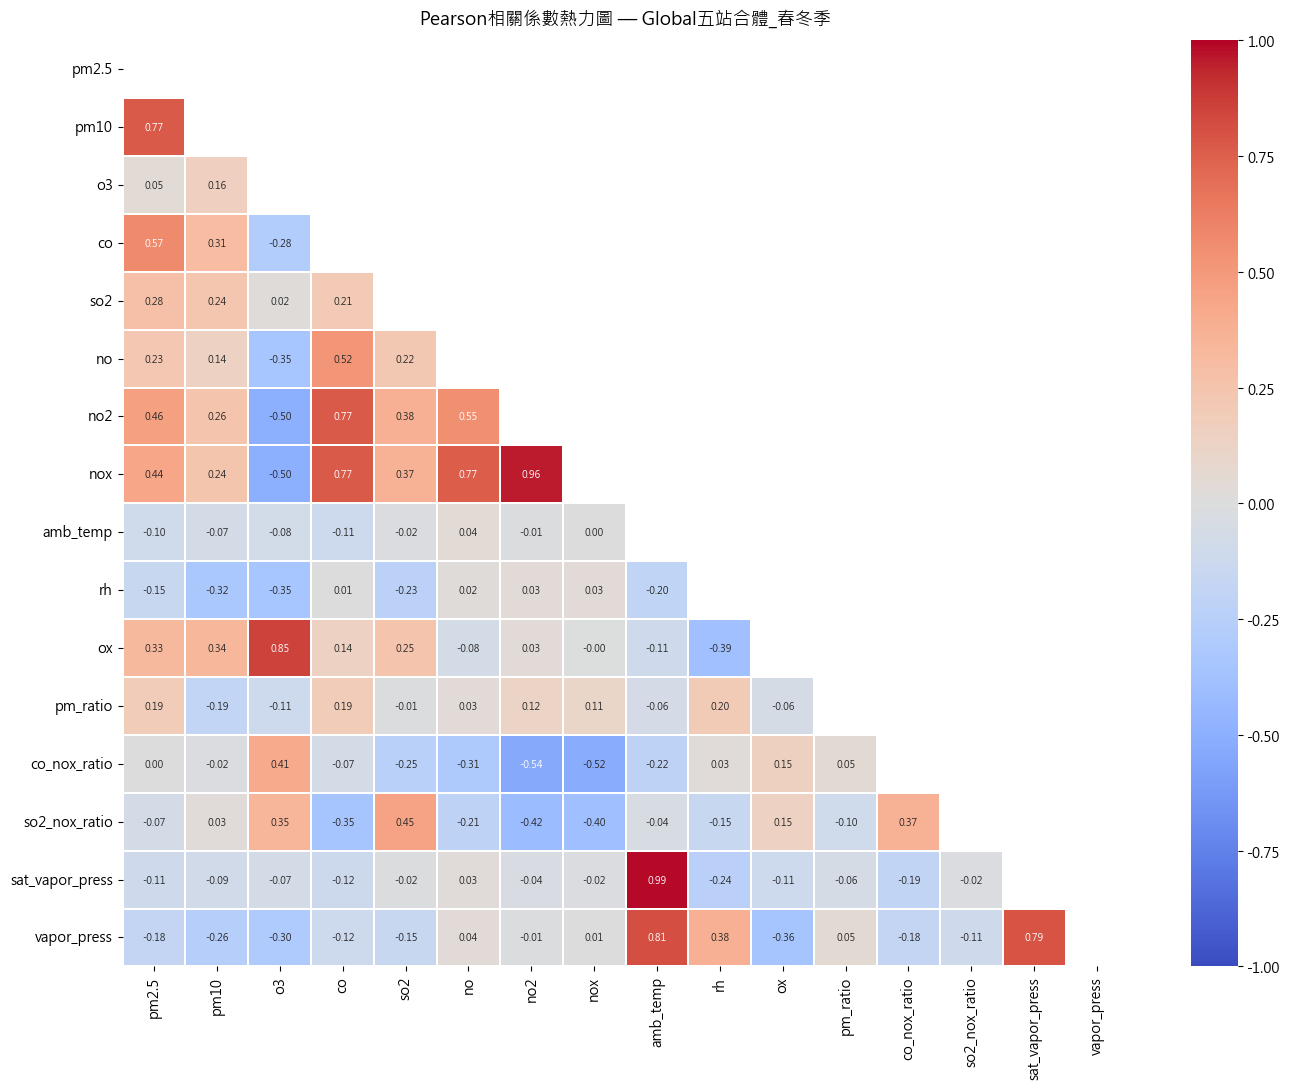

[已儲存] heatmap_Global五站合體_春冬季.png
⠋ 模組 A - 繪製 Local_桃園_春冬季 Heatmap...

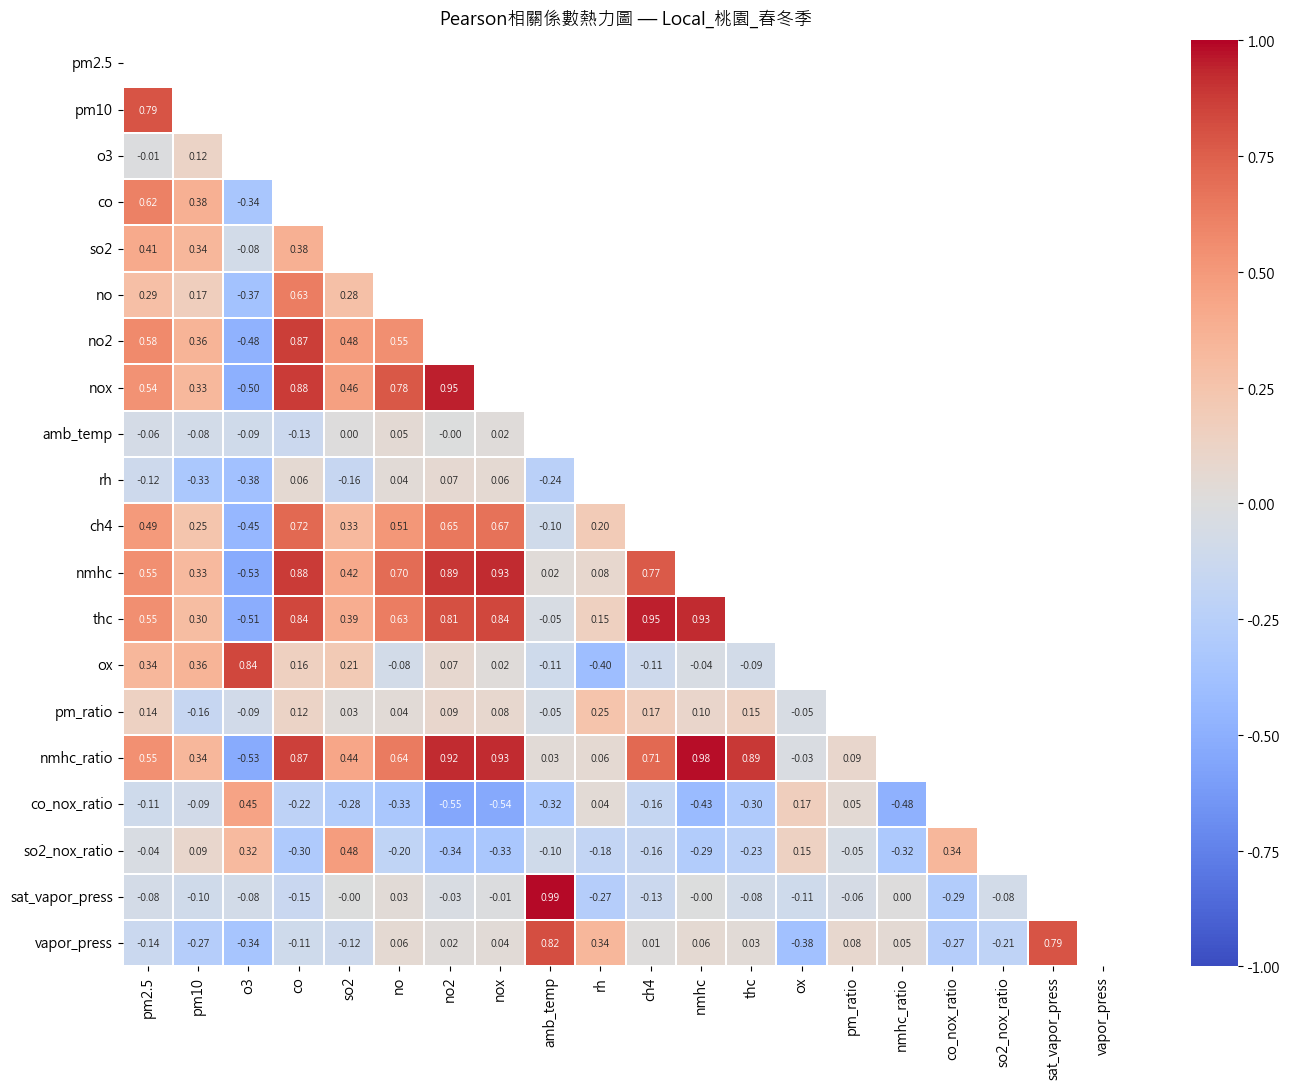

[已儲存] heatmap_Local_桃園_春冬季.png
⠼ 模組 A - 繪製 Local_平鎮_春冬季 Heatmap...

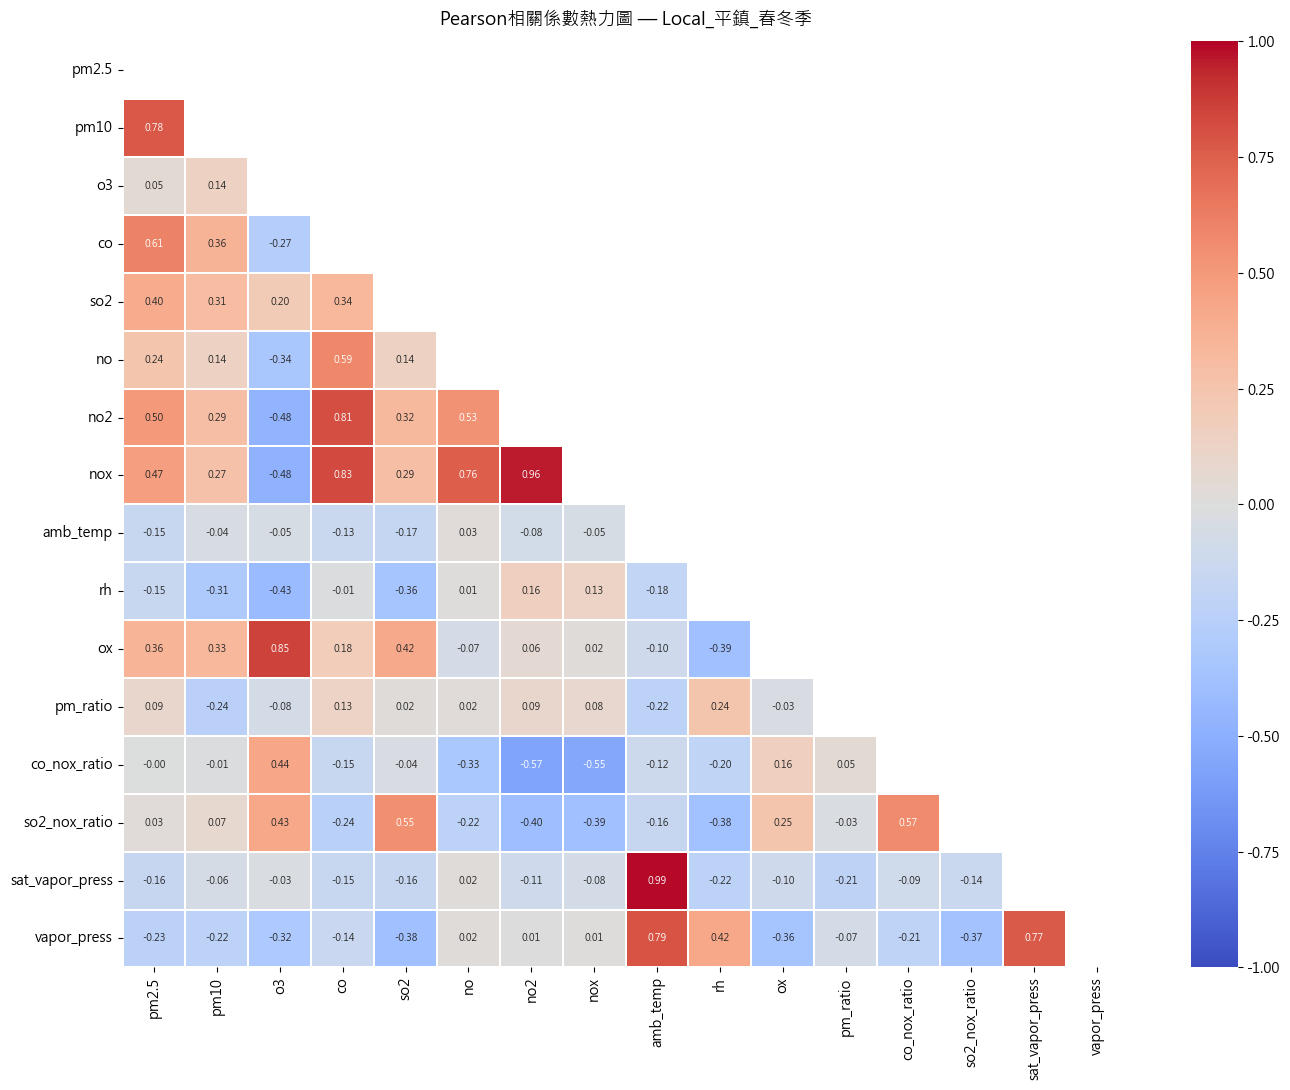

[已儲存] heatmap_Local_平鎮_春冬季.png
⠋ 模組 A - 繪製 Local_大園_春冬季 Heatmap...

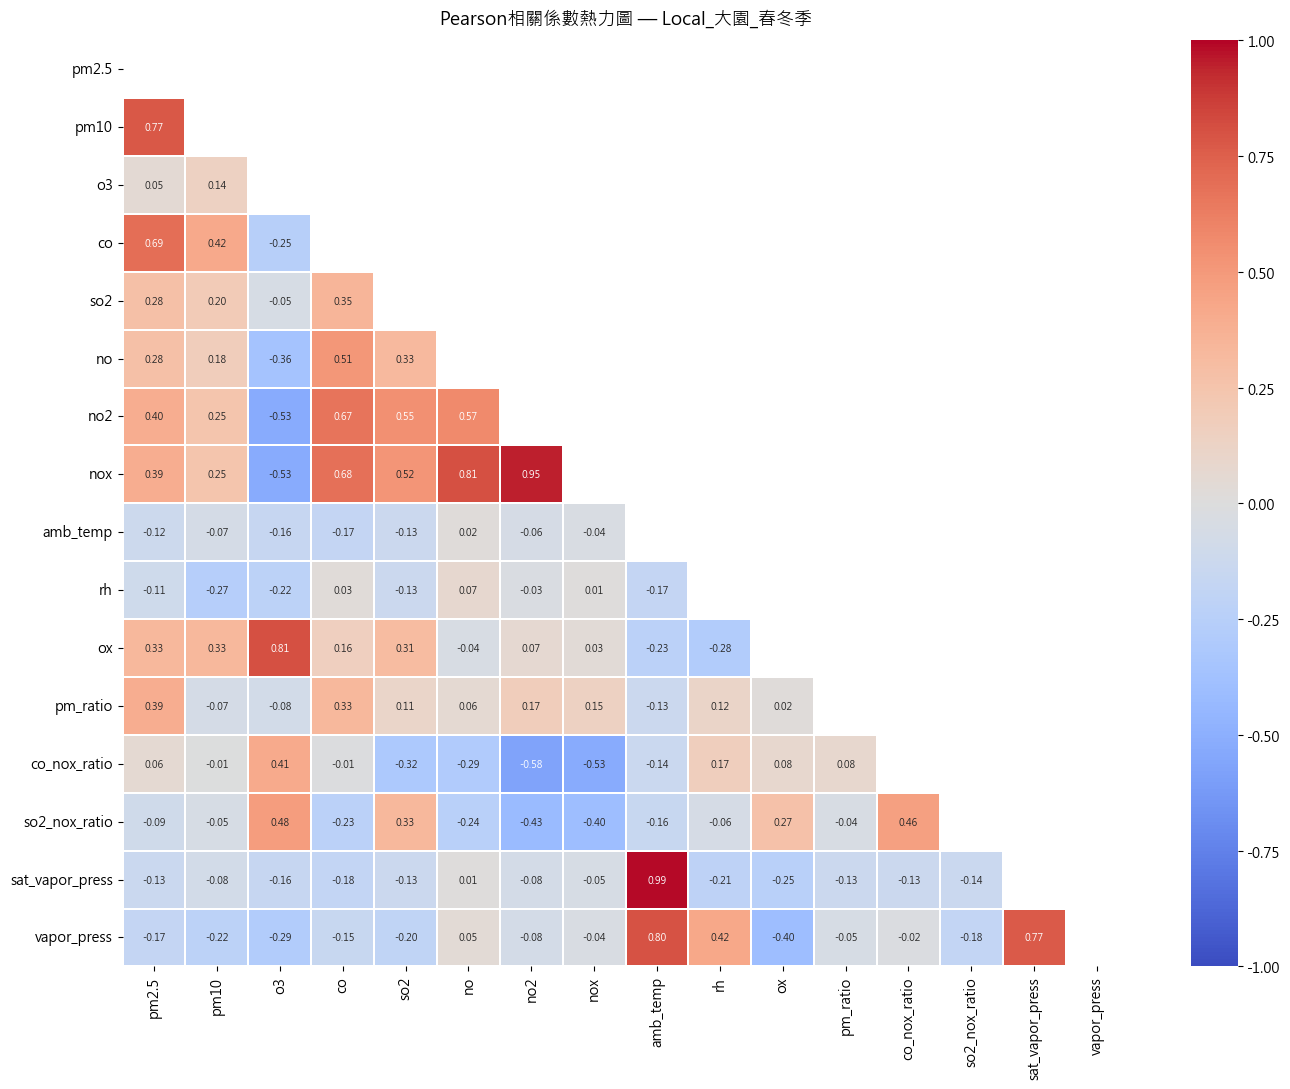

[已儲存] heatmap_Local_大園_春冬季.png
⠸ 模組 A - 繪製 Local_觀音_春冬季 Heatmap...

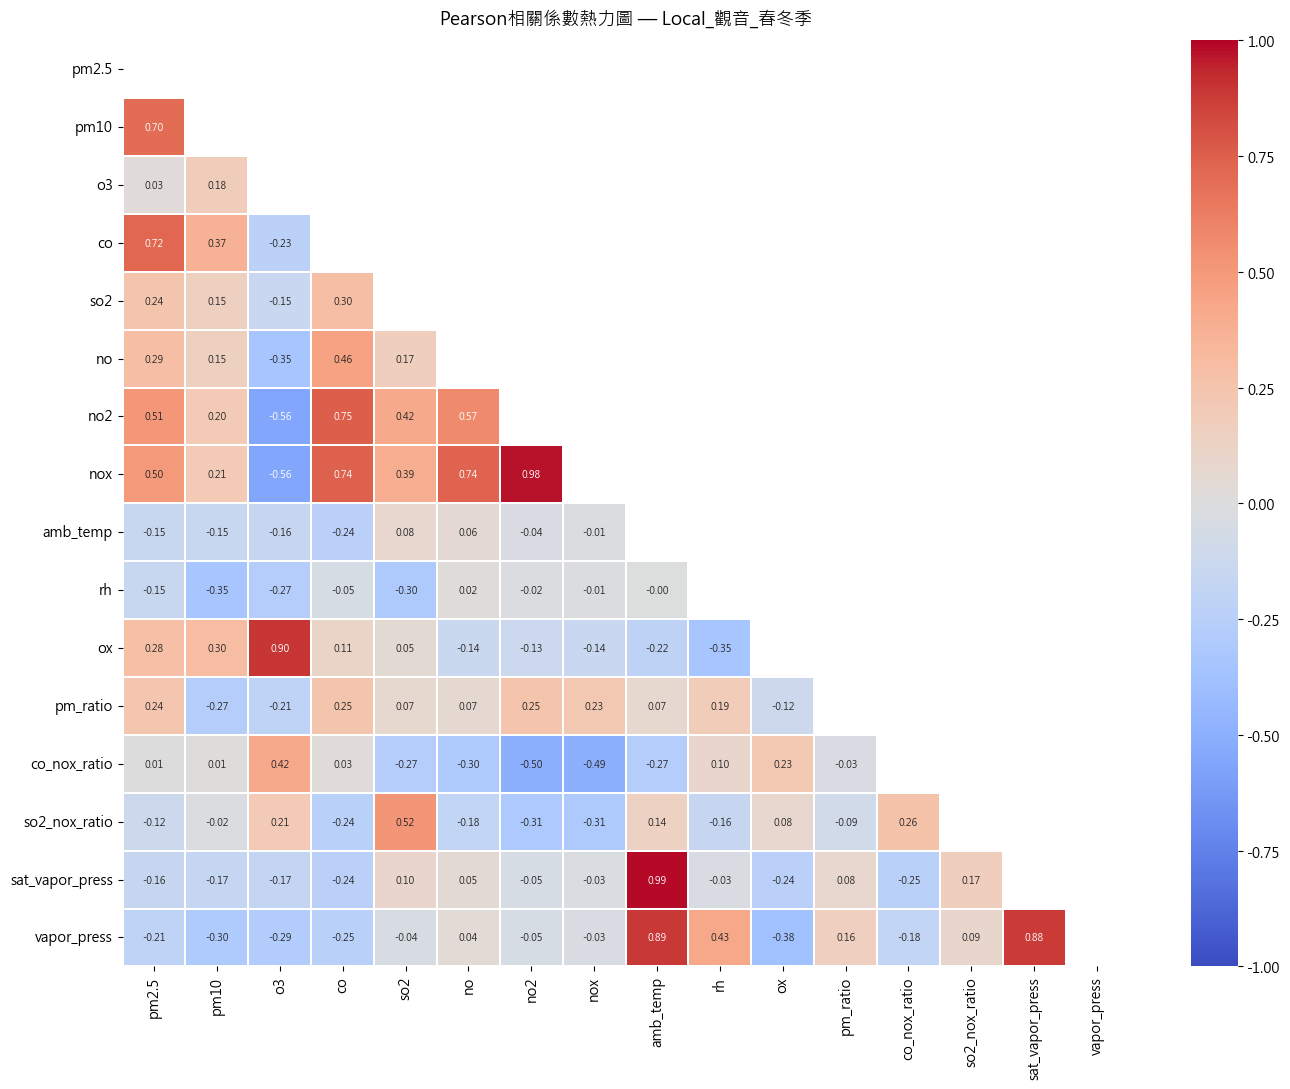

[已儲存] heatmap_Local_觀音_春冬季.png
⠇ 模組 A - 繪製 Local_龍潭_春冬季 Heatmap...

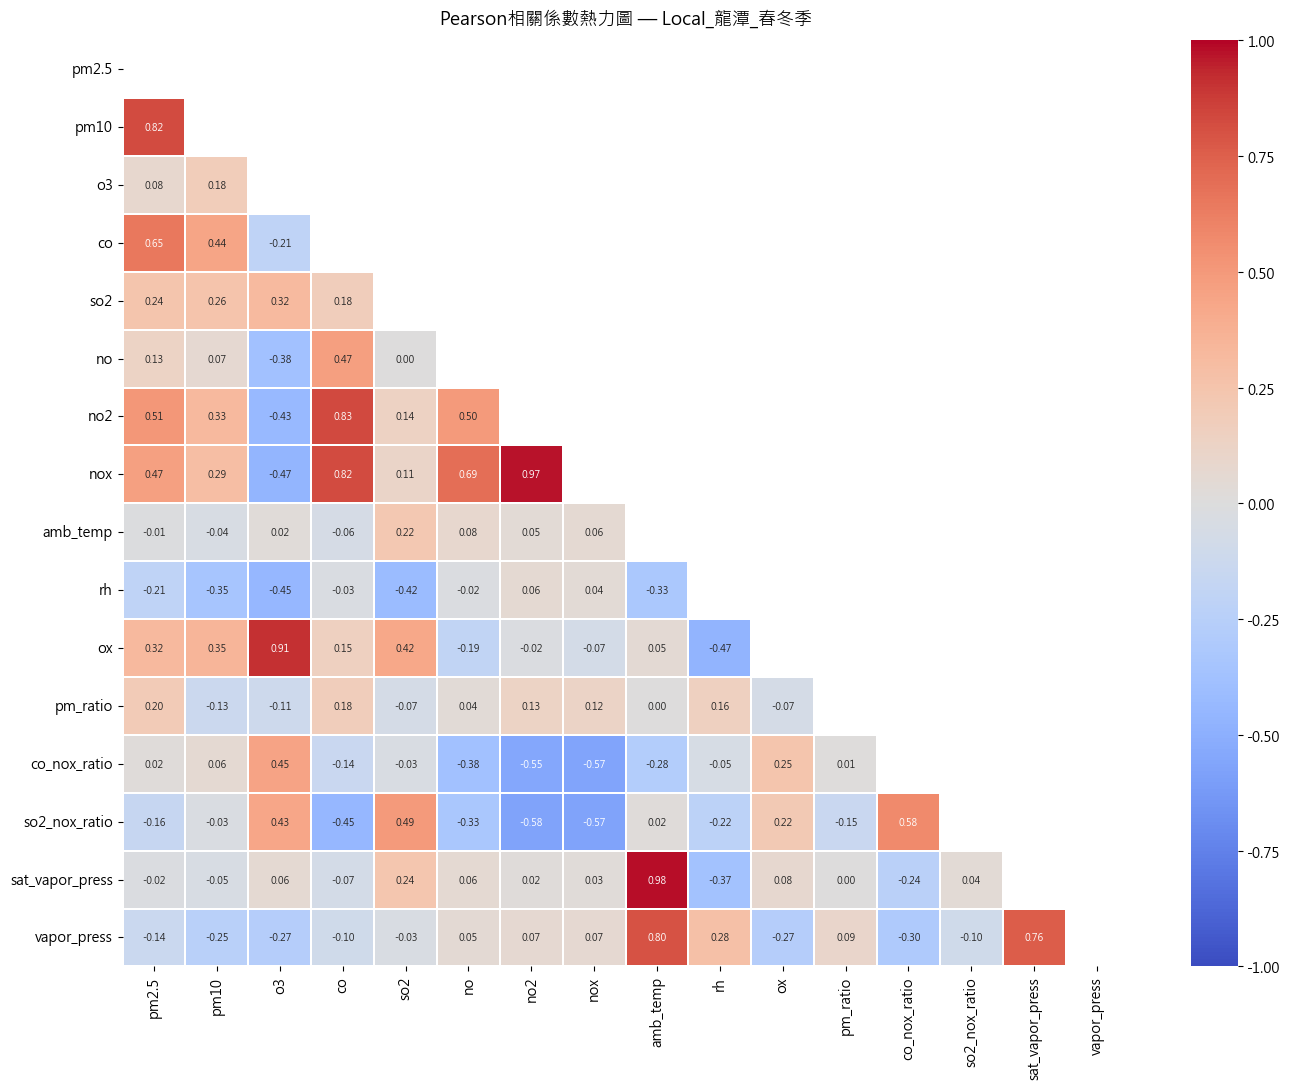

[已儲存] heatmap_Local_龍潭_春冬季.png
⠹ 模組 A - 繪製 Global五站合體_夏秋季 Heatmap...

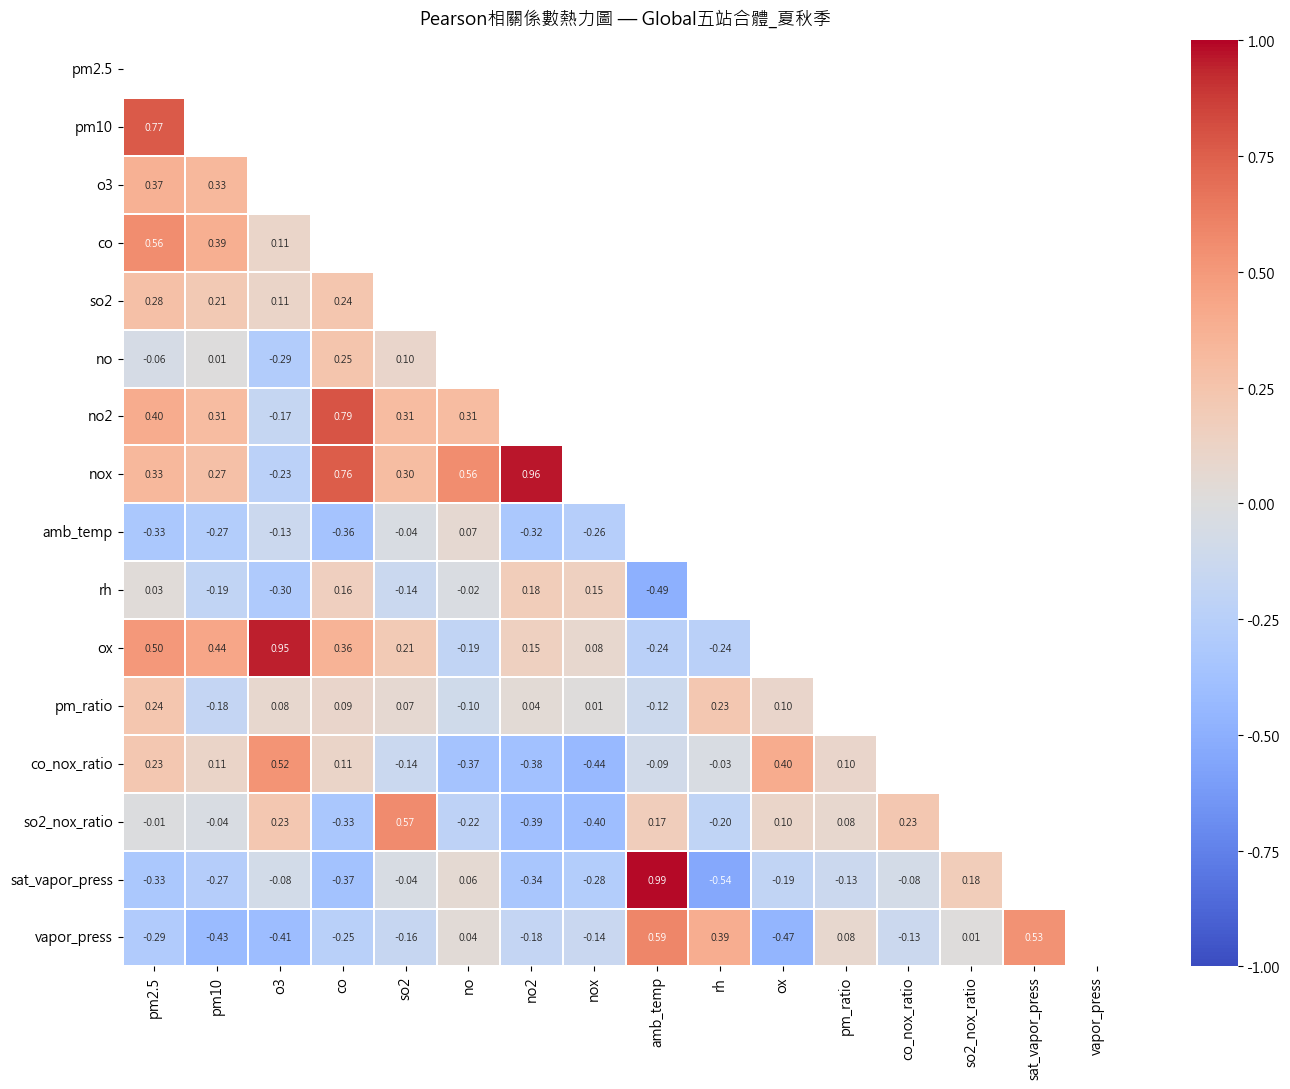

[已儲存] heatmap_Global五站合體_夏秋季.png
⠙ 模組 A - 繪製 Local_桃園_夏秋季 Heatmap...

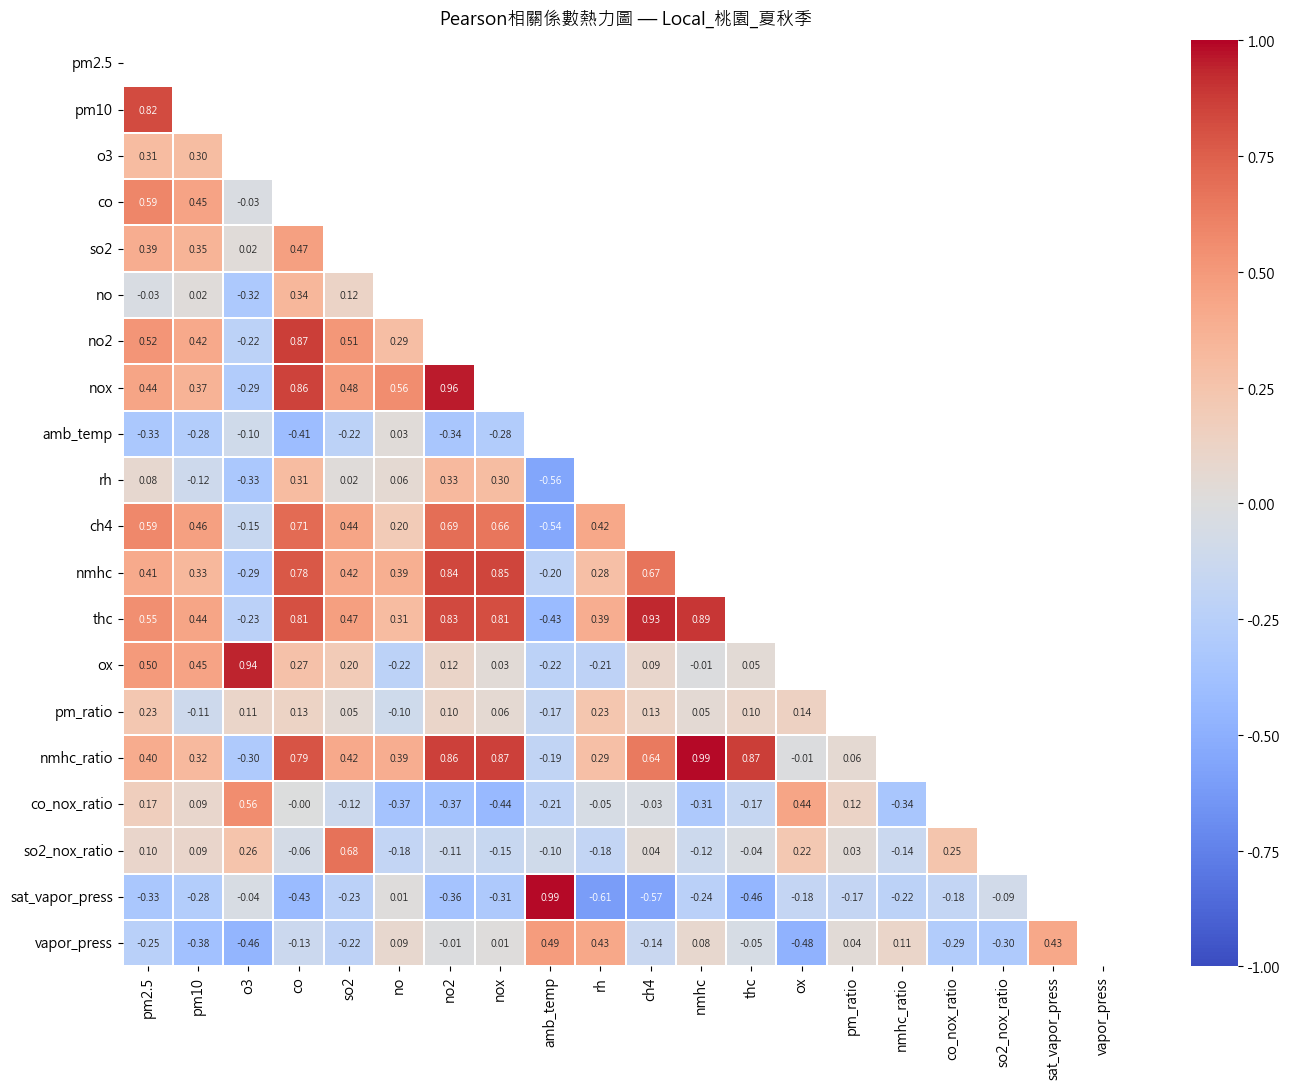

[已儲存] heatmap_Local_桃園_夏秋季.png
⠴ 模組 A - 繪製 Local_平鎮_夏秋季 Heatmap...

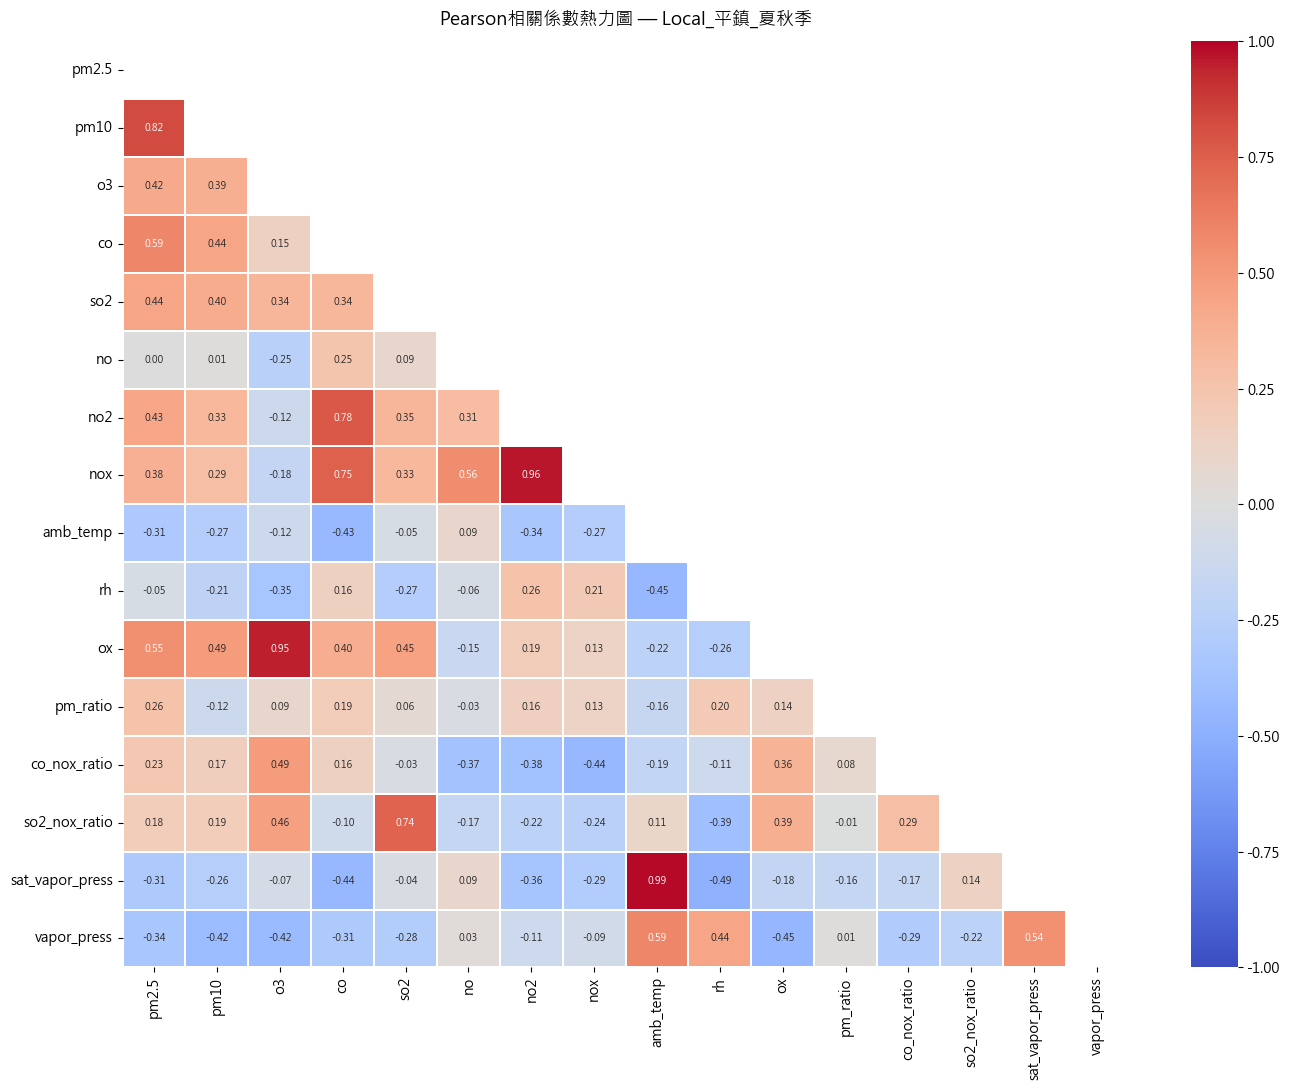

[已儲存] heatmap_Local_平鎮_夏秋季.png
⠼ 模組 A - 繪製 Local_大園_夏秋季 Heatmap...

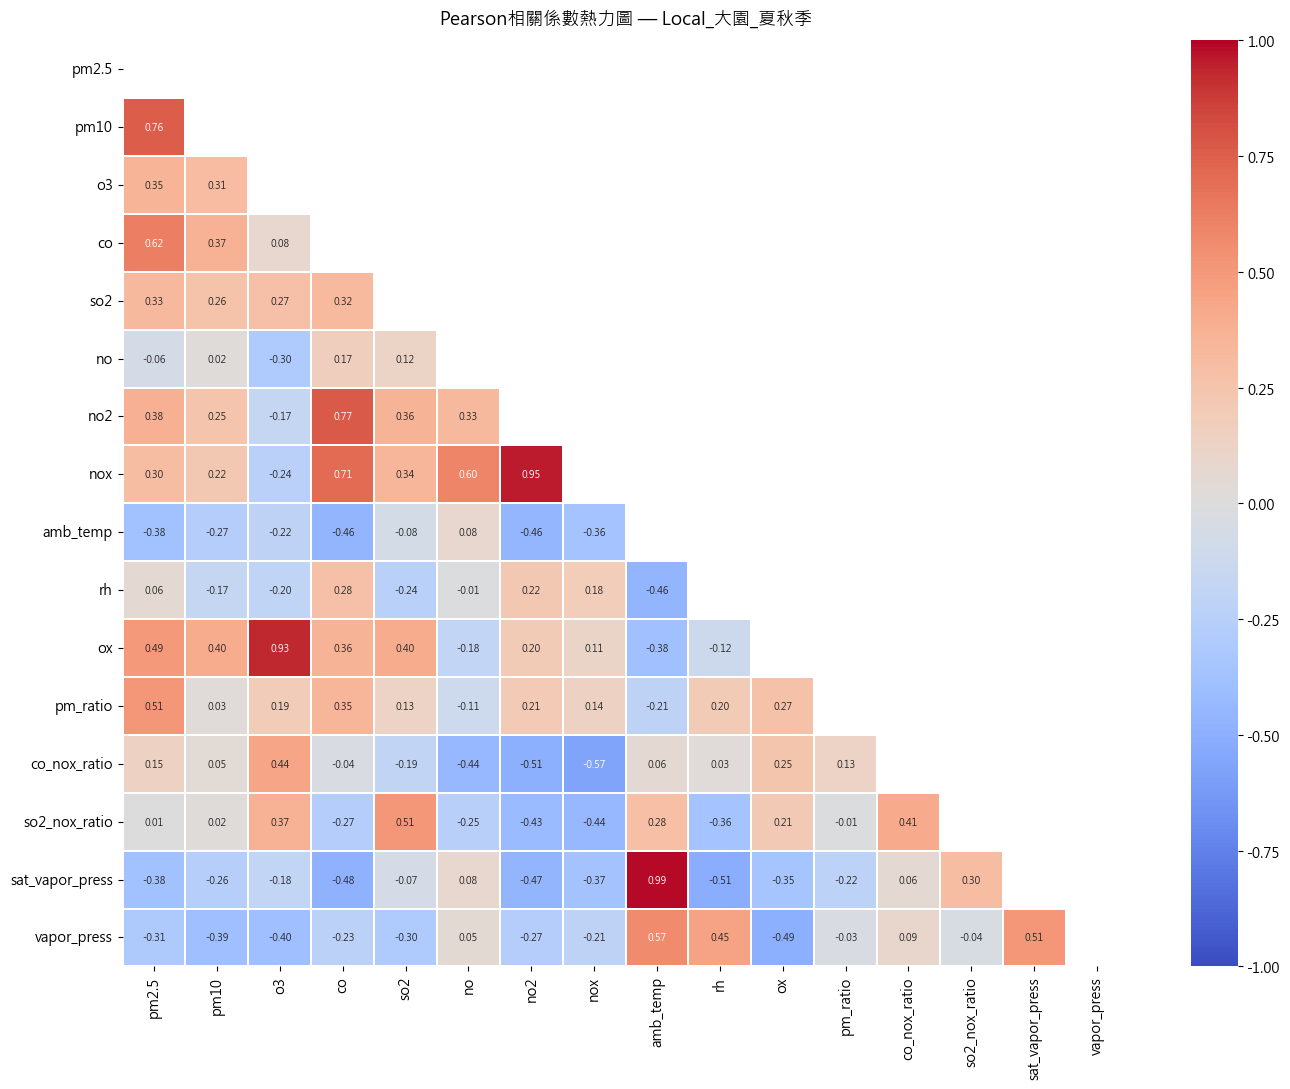

[已儲存] heatmap_Local_大園_夏秋季.png
⠇ 模組 A - 繪製 Local_觀音_夏秋季 Heatmap...

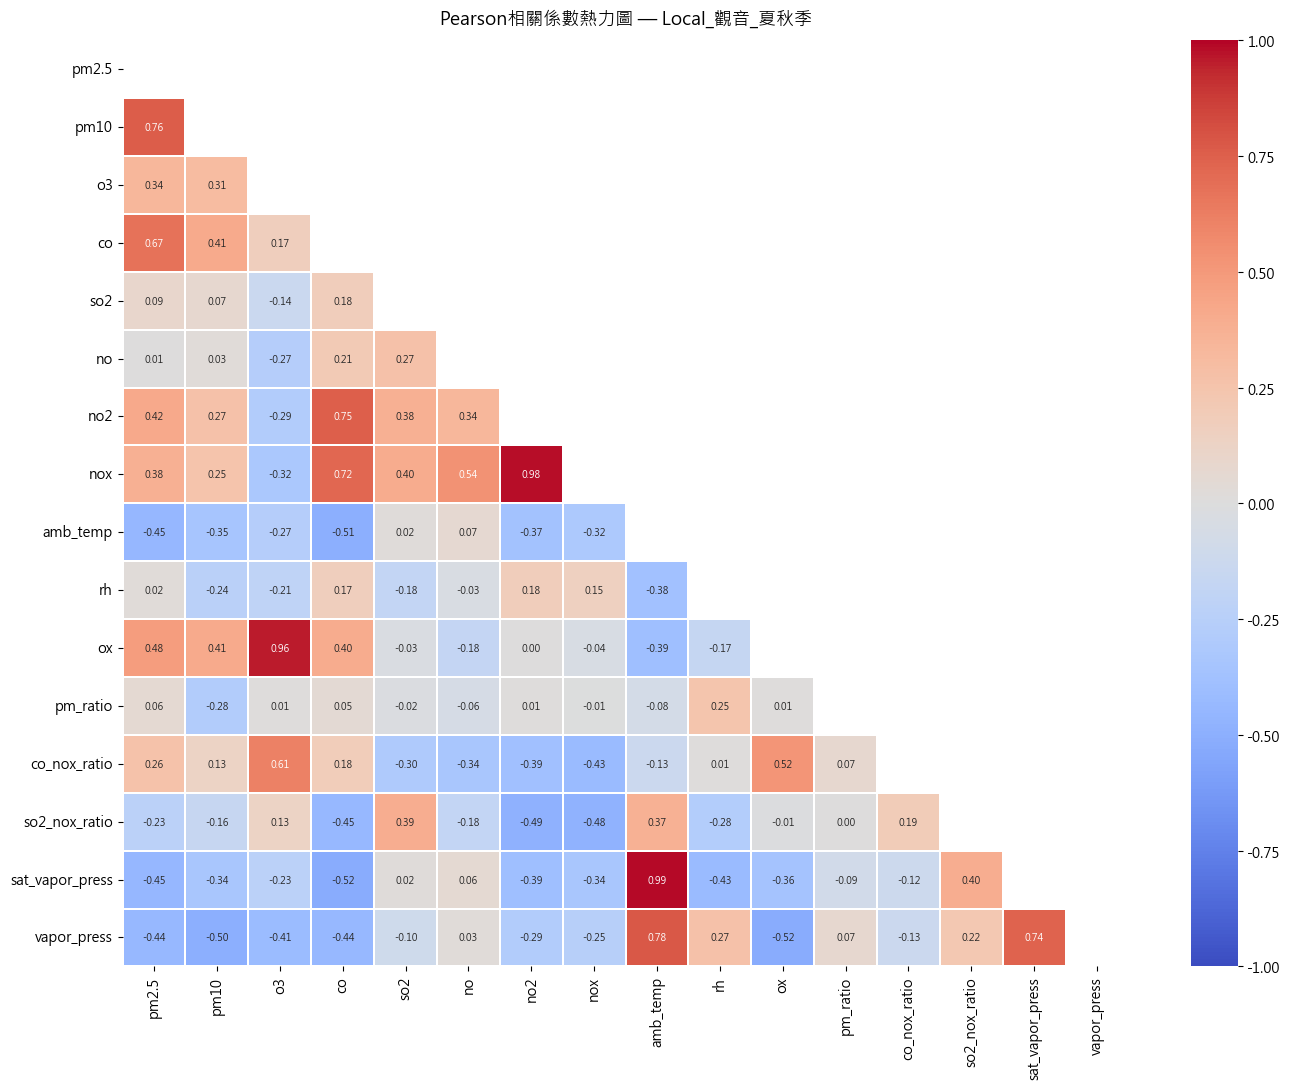

[已儲存] heatmap_Local_觀音_夏秋季.png
⠹ 模組 A - 繪製 Local_龍潭_夏秋季 Heatmap...

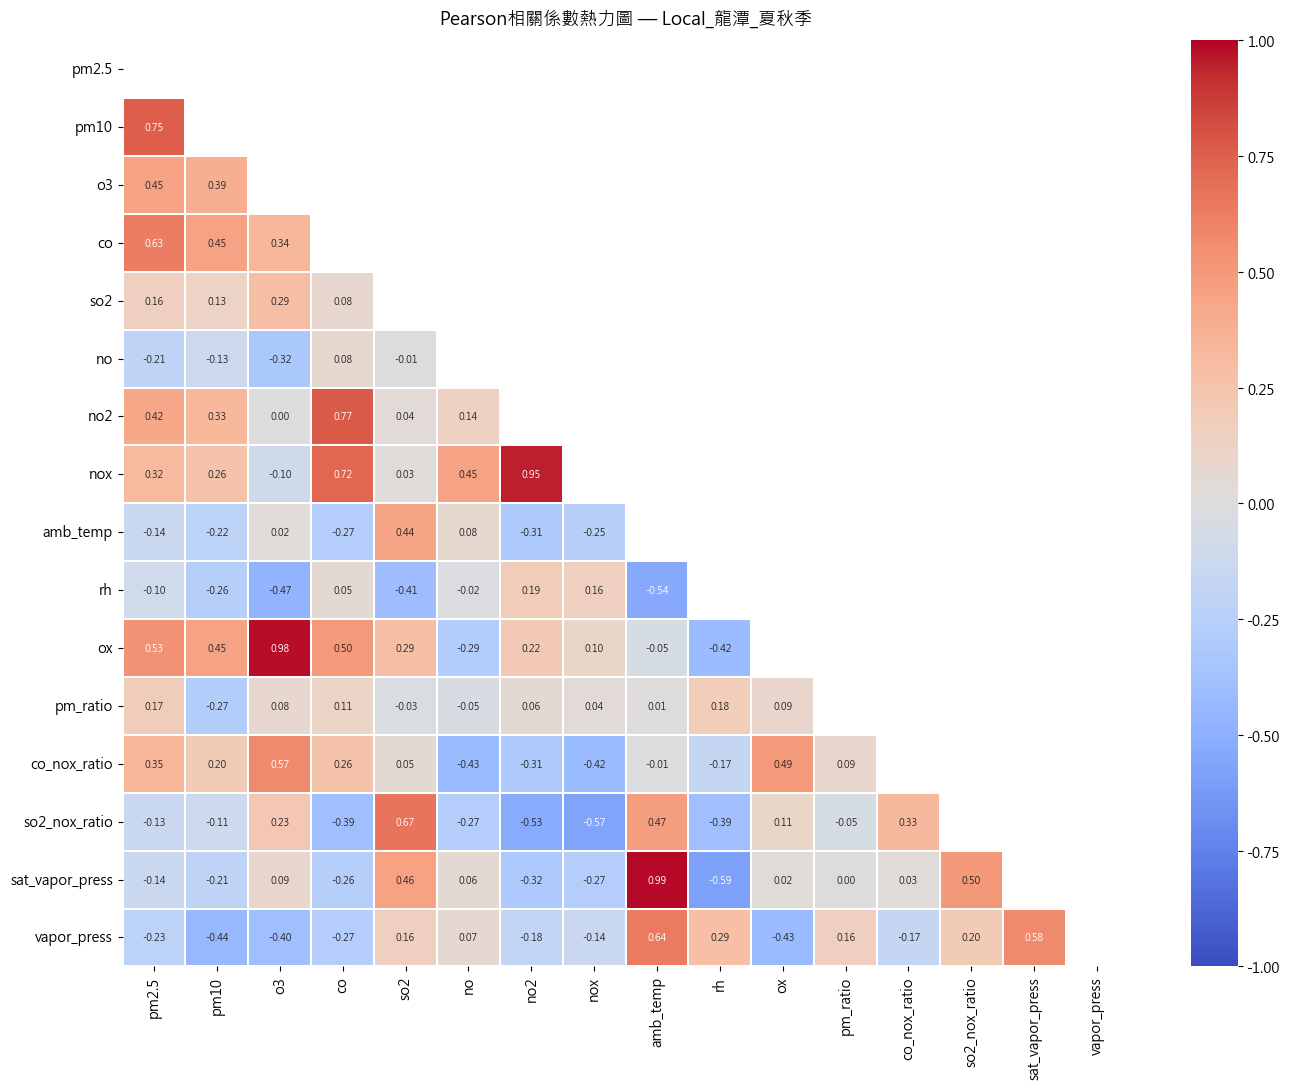

[已儲存] heatmap_Local_龍潭_夏秋季.png
⠹ 模組 A - 繪製 Local_龍潭_夏秋季 Heatmap...
✓ 模組 A 全部季節性 Heatmap 繪製完成！

==================== 執行模組 B：Pearson 排行 (特徵 vs PM2.5) 

[Global五站合體_春冬季] 特徵 vs pm2.5 相關性排行：
 排名              特徵      相關係數l五站合體_春冬季 排行...
  1            pm10  0.765625
  2              co  0.572430
  3             no2  0.462628
  4             nox  0.436283
  5              ox  0.325002
  6             so2  0.278770
  7              no  0.233360
  8        pm_ratio  0.187976
  9     vapor_press -0.177054
 10              rh -0.149534
 11 sat_vapor_press -0.106245
 12        amb_temp -0.095186
 13   so2_nox_ratio -0.074994
 14              o3  0.045785
 15    co_nox_ratio  0.002173
⠼ 模組 B - 計算 Global五站合體_春冬季 排行...

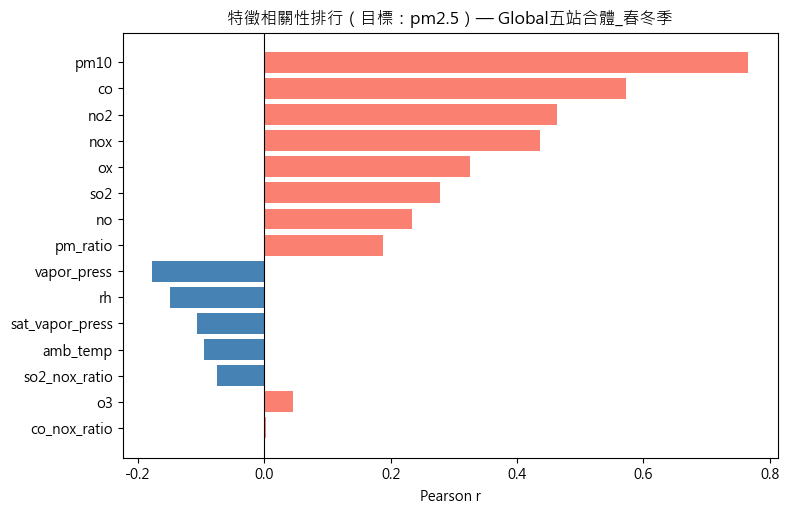

[已儲存] corr_rank_Global五站合體_春冬季_pm2.5.png
m⠼ 模組 B - 計算 Global五站合體_春冬季 排行...
[Local_桃園_春冬季] 特徵 vs pm2.5 相關性排行：
 排名              特徵      相關係數_桃園_春冬季 排行...
  1            pm10  0.789448
  2              co  0.615621
  3             no2  0.576103
  4             thc  0.549855
  5            nmhc  0.547561
  6      nmhc_ratio  0.546829
  7             nox  0.538004
  8             ch4  0.494108
  9             so2  0.410995
 10              ox  0.338424
 11              no  0.287045
 12        pm_ratio  0.144401
 13     vapor_press -0.136177
 14              rh -0.116469
 15    co_nox_ratio -0.107577
 16 sat_vapor_press -0.077879
 17        amb_temp -0.064425
 18   so2_nox_ratio -0.035759
 19              o3 -0.013805
⠋ 模組 B - 計算 Local_桃園_春冬季 排行...

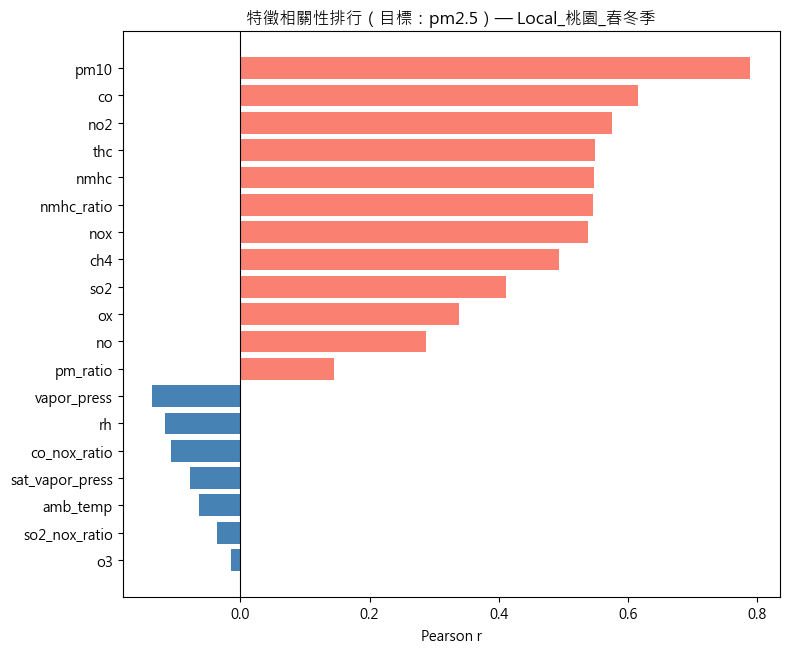

[已儲存] corr_rank_Local_桃園_春冬季_pm2.5.png
m⠋ 模組 B - 計算 Local_桃園_春冬季 排行...
[Local_平鎮_春冬季] 特徵 vs pm2.5 相關性排行：
 排名              特徵      相關係數_平鎮_春冬季 排行...
  1            pm10  0.778569
  2              co  0.606237
  3             no2  0.498751
  4             nox  0.468928
  5             so2  0.402315
  6              ox  0.355648
  7              no  0.243134
  8     vapor_press -0.231104
  9 sat_vapor_press -0.159992
 10              rh -0.153042
 11        amb_temp -0.149245
 12        pm_ratio  0.086194
 13              o3  0.052144
 14   so2_nox_ratio  0.026363
 15    co_nox_ratio -0.001647
⠴ 模組 B - 計算 Local_平鎮_春冬季 排行...

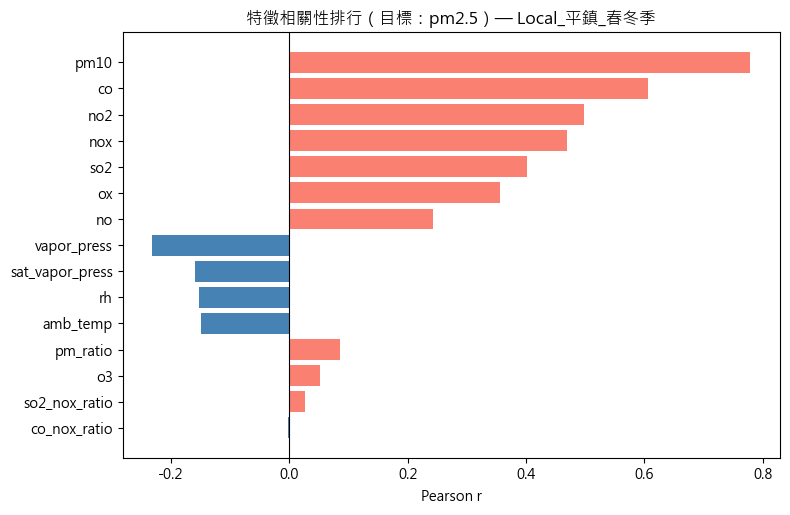

[已儲存] corr_rank_Local_平鎮_春冬季_pm2.5.png
m⠴ 模組 B - 計算 Local_平鎮_春冬季 排行...
[Local_大園_春冬季] 特徵 vs pm2.5 相關性排行：
 排名              特徵      相關係數_大園_春冬季 排行...
  1            pm10  0.773849
  2              co  0.694425
  3             no2  0.396190
  4        pm_ratio  0.394584
  5             nox  0.394052
  6              ox  0.332688
  7             so2  0.275796
  8              no  0.275406
  9     vapor_press -0.173352
 10 sat_vapor_press -0.133902
 11        amb_temp -0.120587
 12              rh -0.107468
 13   so2_nox_ratio -0.094375
 14    co_nox_ratio  0.062206
 15              o3  0.051554
⠏ 模組 B - 計算 Local_大園_春冬季 排行...

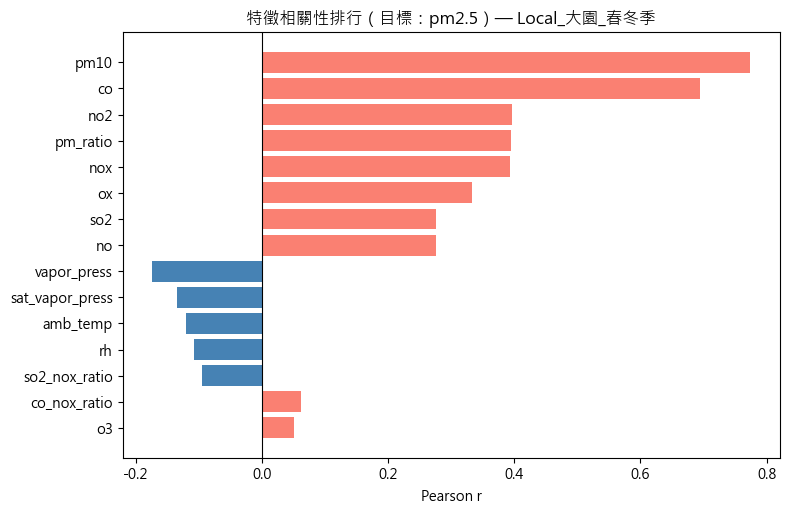

[已儲存] corr_rank_Local_大園_春冬季_pm2.5.png
m⠋ 模組 B - 計算 Local_大園_春冬季 排行...
[Local_觀音_春冬季] 特徵 vs pm2.5 相關性排行：
 排名              特徵      相關係數_觀音_春冬季 排行...
  1              co  0.718940
  2            pm10  0.699027
  3             no2  0.508836
  4             nox  0.498514
  5              no  0.293273
  6              ox  0.281339
  7             so2  0.244668
  8        pm_ratio  0.237168
  9     vapor_press -0.207450
 10 sat_vapor_press -0.159133
 11              rh -0.153701
 12        amb_temp -0.152848
 13   so2_nox_ratio -0.124463
 14              o3  0.027153
 15    co_nox_ratio  0.006189
⠸ 模組 B - 計算 Local_觀音_春冬季 排行...

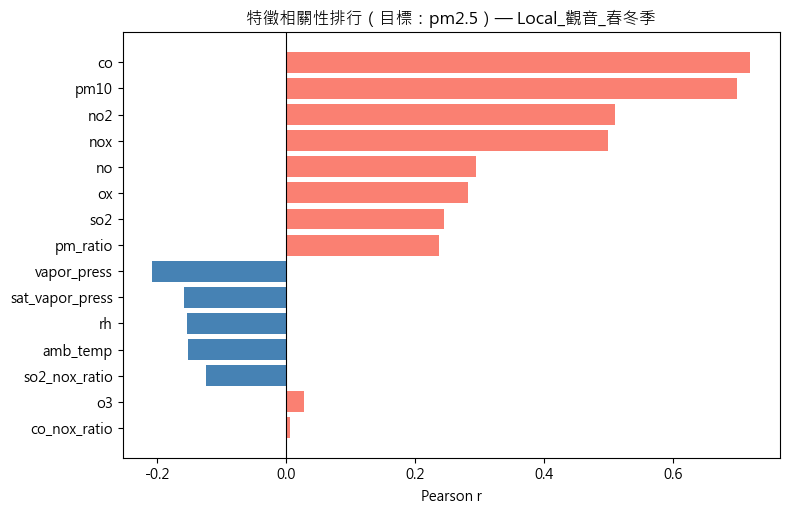

[已儲存] corr_rank_Local_觀音_春冬季_pm2.5.png
⠼ 模組 B - 計算 Local_龍潭_春冬季 排行...
[Local_龍潭_春冬季] 特徵 vs pm2.5 相關性排行：
 排名              特徵      相關係數_龍潭_春冬季 排行...
  1            pm10  0.822748
  2              co  0.653242
  3             no2  0.514529
  4             nox  0.465430
  5              ox  0.323908
  6             so2  0.244021
  7              rh -0.206539
  8        pm_ratio  0.202534
  9   so2_nox_ratio -0.159778
 10     vapor_press -0.139476
 11              no  0.130849
 12              o3  0.082834
 13    co_nox_ratio  0.021809
 14 sat_vapor_press -0.018143
 15        amb_temp -0.014584
⠏ 模組 B - 計算 Local_龍潭_春冬季 排行...

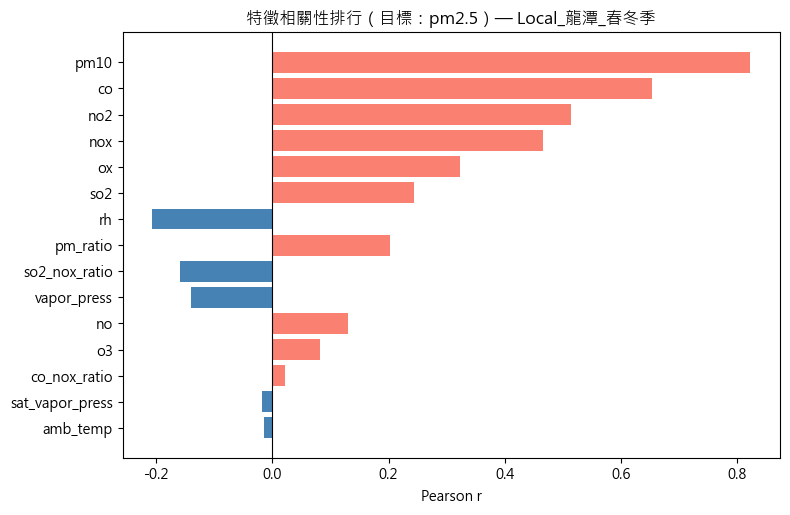

[已儲存] corr_rank_Local_龍潭_春冬季_pm2.5.png
m⠏ 模組 B - 計算 Local_龍潭_春冬季 排行...
[Global五站合體_夏秋季] 特徵 vs pm2.5 相關性排行：
 排名              特徵      相關係數l五站合體_夏秋季 排行...
  1            pm10  0.766070
  2              co  0.558044
  3              ox  0.501870
  4             no2  0.401967
  5              o3  0.371002
  6             nox  0.332654
  7 sat_vapor_press -0.327858
  8        amb_temp -0.325544
  9     vapor_press -0.291634
 10             so2  0.279470
 11        pm_ratio  0.236175
 12    co_nox_ratio  0.229139
 13              no -0.061601
 14              rh  0.031138
 15   so2_nox_ratio -0.014025
⠸ 模組 B - 計算 Global五站合體_夏秋季 排行...

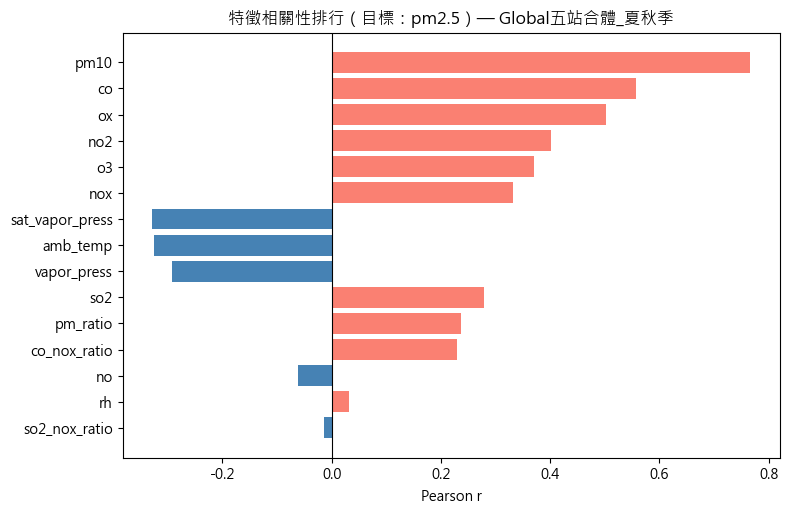

[已儲存] corr_rank_Global五站合體_夏秋季_pm2.5.png
⠼ 模組 B - 計算 Local_桃園_夏秋季 排行...
[Local_桃園_夏秋季] 特徵 vs pm2.5 相關性排行：
 排名              特徵      相關係數_桃園_夏秋季 排行...
  1            pm10  0.820352
  2              co  0.590173
  3             ch4  0.585165
  4             thc  0.554595
  5             no2  0.522874
  6              ox  0.495543
  7             nox  0.444379
  8            nmhc  0.411205
  9      nmhc_ratio  0.403156
 10             so2  0.394946
 11 sat_vapor_press -0.329980
 12        amb_temp -0.325697
 13              o3  0.310226
 14     vapor_press -0.246136
 15        pm_ratio  0.231698
 16    co_nox_ratio  0.169042
 17   so2_nox_ratio  0.097900
 18              rh  0.077397
 19              no -0.031623
⠏ 模組 B - 計算 Local_桃園_夏秋季 排行...

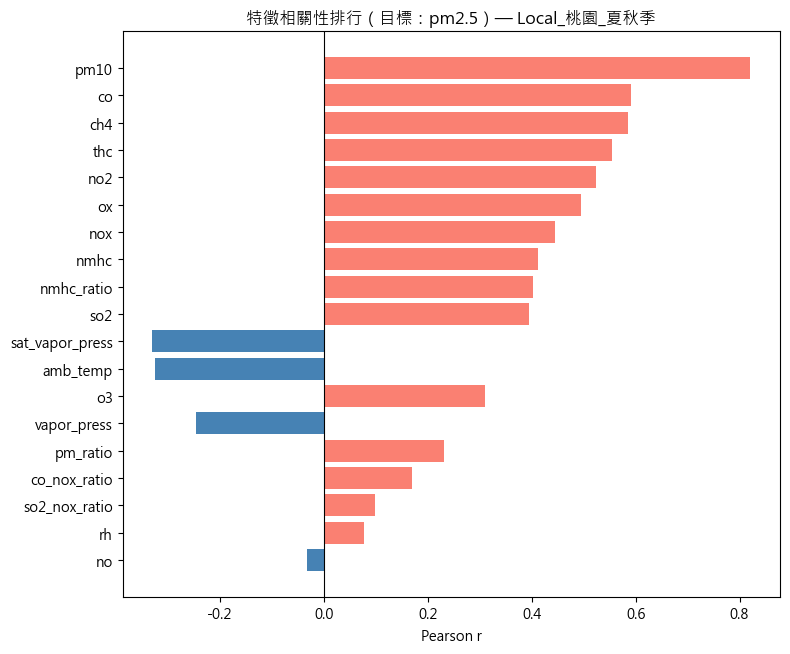

[已儲存] corr_rank_Local_桃園_夏秋季_pm2.5.png
m⠏ 模組 B - 計算 Local_桃園_夏秋季 排行...
[Local_平鎮_夏秋季] 特徵 vs pm2.5 相關性排行：
 排名              特徵      相關係數_平鎮_夏秋季 排行...
  1            pm10  0.824228
  2              co  0.593200
  3              ox  0.554079
  4             so2  0.438157
  5             no2  0.433519
  6              o3  0.421680
  7             nox  0.379492
  8     vapor_press -0.338633
  9        amb_temp -0.313487
 10 sat_vapor_press -0.310843
 11        pm_ratio  0.258559
 12    co_nox_ratio  0.227583
 13   so2_nox_ratio  0.184270
 14              rh -0.054667
 15              no  0.003062
⠼ 模組 B - 計算 Local_平鎮_夏秋季 排行...

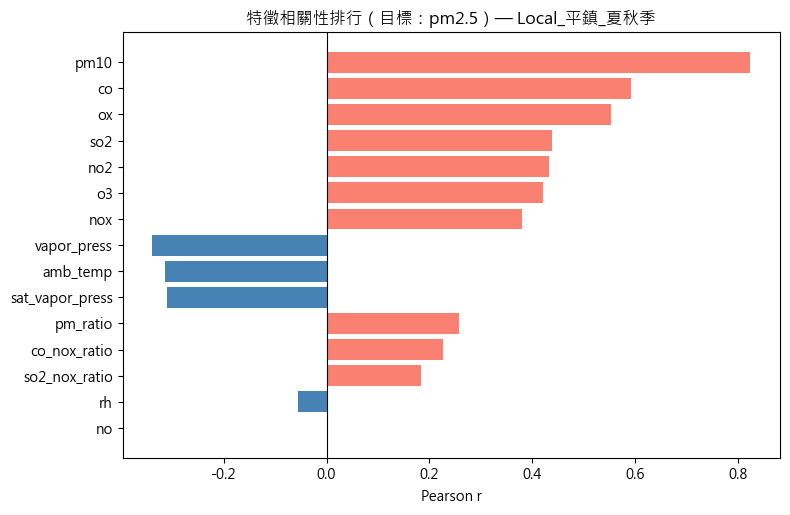

[已儲存] corr_rank_Local_平鎮_夏秋季_pm2.5.png
m⠼ 模組 B - 計算 Local_平鎮_夏秋季 排行...
[Local_大園_夏秋季] 特徵 vs pm2.5 相關性排行：
 排名              特徵      相關係數_大園_夏秋季 排行...
  1            pm10  0.760380
  2              co  0.617256
  3        pm_ratio  0.509223
  4              ox  0.493985
  5             no2  0.380819
  6 sat_vapor_press -0.378073
  7        amb_temp -0.375893
  8              o3  0.354814
  9             so2  0.326914
 10     vapor_press -0.308458
 11             nox  0.303730
 12    co_nox_ratio  0.146530
 13              no -0.063265
 14              rh  0.062138
 15   so2_nox_ratio  0.005201
⠇ 模組 B - 計算 Local_大園_夏秋季 排行...

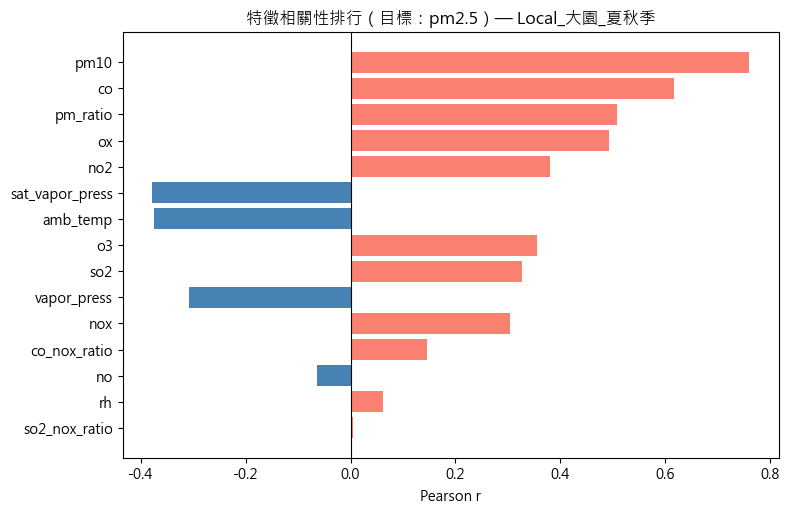

[已儲存] corr_rank_Local_大園_夏秋季_pm2.5.png
m⠏ 模組 B - 計算 Local_大園_夏秋季 排行...
[Local_觀音_夏秋季] 特徵 vs pm2.5 相關性排行：
 排名              特徵      相關係數_觀音_夏秋季 排行...
  1            pm10  0.763319
  2              co  0.672326
  3              ox  0.477092
  4 sat_vapor_press -0.453070
  5        amb_temp -0.446872
  6     vapor_press -0.444037
  7             no2  0.417202
  8             nox  0.376154
  9              o3  0.336482
 10    co_nox_ratio  0.261636
 11   so2_nox_ratio -0.230051
 12             so2  0.086086
 13        pm_ratio  0.057939
 14              rh  0.024713
 15              no  0.006301
⠼ 模組 B - 計算 Local_觀音_夏秋季 排行...

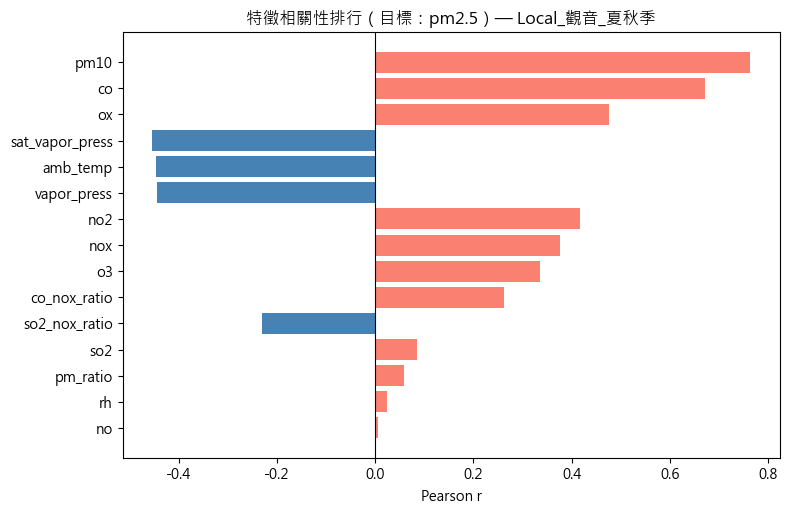

[已儲存] corr_rank_Local_觀音_夏秋季_pm2.5.png
m⠴ 模組 B - 計算 Local_觀音_夏秋季 排行...
[Local_龍潭_夏秋季] 特徵 vs pm2.5 相關性排行：
 排名              特徵      相關係數_龍潭_夏秋季 排行...
  1            pm10  0.752433
  2              co  0.628309
  3              ox  0.534876
  4              o3  0.452757
  5             no2  0.422370
  6    co_nox_ratio  0.347340
  7             nox  0.318582
  8     vapor_press -0.225881
  9              no -0.208373
 10        pm_ratio  0.174105
 11             so2  0.158106
 12        amb_temp -0.139303
 13 sat_vapor_press -0.136212
 14   so2_nox_ratio -0.133076
 15              rh -0.100868
⠏ 模組 B - 計算 Local_龍潭_夏秋季 排行...

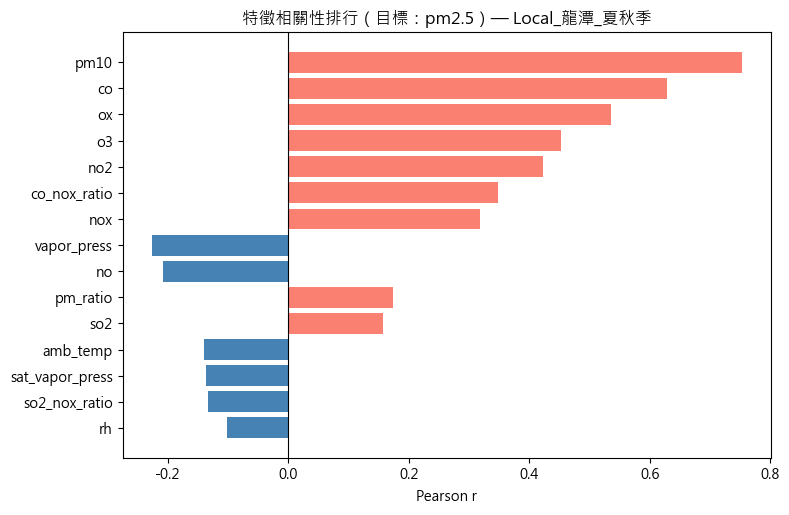

[已儲存] corr_rank_Local_龍潭_夏秋季_pm2.5.png
⠋ 模組 B - 計算 Local_龍潭_夏秋季 排行...
✓ 模組 B 全部季節性特徵排行完成！

季節性EDA相關性分析完成 — 輸出檔案清單

模組A Heatmap（12張）：
  heatmap_Global五站合體_春冬季.png
  heatmap_Global五站合體_夏秋季.png
  heatmap_Local_桃園_春冬季.png
  heatmap_Local_桃園_夏秋季.png
  heatmap_Local_平鎮_春冬季.png
  heatmap_Local_平鎮_夏秋季.png
  heatmap_Local_大園_春冬季.png
  heatmap_Local_大園_夏秋季.png
  heatmap_Local_觀音_春冬季.png
  heatmap_Local_觀音_夏秋季.png
  heatmap_Local_龍潭_春冬季.png
  heatmap_Local_龍潭_夏秋季.png

模組B Pearson排行（12張）：
  corr_rank_Global五站合體_春冬季_pm2.5.png
  corr_rank_Global五站合體_夏秋季_pm2.5.png
  corr_rank_Local_桃園_春冬季_pm2.5.png
  corr_rank_Local_桃園_夏秋季_pm2.5.png
  corr_rank_Local_平鎮_春冬季_pm2.5.png
  corr_rank_Local_平鎮_夏秋季_pm2.5.png
  corr_rank_Local_大園_春冬季_pm2.5.png
  corr_rank_Local_大園_夏秋季_pm2.5.png
  corr_rank_Local_觀音_春冬季_pm2.5.png
  corr_rank_Local_觀音_夏秋季_pm2.5.png
  corr_rank_Local_龍潭_春冬季_pm2.5.png
  corr_rank_Local_龍潭_夏秋季_pm2.5.png

全部完成。


In [12]:
# ==============================================================================
# 桃園空品監測資料 — 季節性 EDA 相關性分析 (春冬季 vs 夏秋季)
# SDD 模組：模組 A (Pearson Heatmap) | 模組 B (Pearson 特徵排行 vs PM2.5)
# ==============================================================================

import warnings
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

warnings.filterwarnings("ignore")

# 嘗試載入 Rich 套件（支援動畫載入狀態）
try:
    from rich.console import Console

# 初始化時關閉 force_jupyter 或使用 standard output
    console = Console(force_jupyter=False)  # 讓 rich 僅作為普通 terminal / string 輸出
    HAS_RICH = True
except ImportError:
    HAS_RICH = False
    print("💡 提示：可安裝 rich 套件以獲得動態 Loading 載入動畫 (pip install rich)")

# 設定繪圖中文字型
plt.rcParams["font.sans-serif"] = [
    "Microsoft JhengHei",
    "SimHei",
    "Noto Sans CJK TC",
    "Arial",
]
plt.rcParams["axes.unicode_minus"] = False

# ------------------------------------------------------------------------------
# 輔助印出函數 (相容 RichConsole 與 普通 print)
# ------------------------------------------------------------------------------


def log(msg):
    if HAS_RICH:
        console.print(msg)
    else:
        print(msg)


# ------------------------------------------------------------------------------
# 四、前置處理與資料載入
# ------------------------------------------------------------------------------
if HAS_RICH:
    status = console.status(
        "[bold cyan]正在載入五站與桃園獨立 CSV 資料並切分季節...", spinner="dots"
    )
    status.start()

# --- 載入資料 ---
df_5station = pd.read_csv("2025桃園五站空品監測資料_精簡20欄合體版.csv")
df_taoyuan = pd.read_csv("2025桃園站空品監測資料_完整科學指標擴增版.csv")

# 轉換時間欄位並提取月份
df_5station["publishtime"] = pd.to_datetime(df_5station["publishtime"])
df_taoyuan["publishtime"] = pd.to_datetime(df_taoyuan["publishtime"])
df_5station["month"] = df_5station["publishtime"].dt.month
df_taoyuan["month"] = df_taoyuan["publishtime"].dt.month

# 季節切分月份定義
WINTER_SPRING_MONTHS = [1, 2, 3, 10, 11, 12]
SUMMER_AUTUMN_MONTHS = [4, 5, 6, 7, 8, 9]

season_map = {
    "春冬季": WINTER_SPRING_MONTHS,
    "夏秋季": SUMMER_AUTUMN_MONTHS,
}

# 排除非數值/輔助欄位
exclude_cols = ["sitename", "publishtime", "month"]

# 目標變數
target = "pm2.5"

# 各站對應資料（未切季節的完整版）
station_dfs = {
    "桃園": df_taoyuan,
    "平鎮": df_5station[df_5station["sitename"] == "平鎮"].copy(),
    "大園": df_5station[df_5station["sitename"] == "大園"].copy(),
    "觀音": df_5station[df_5station["sitename"] == "觀音"].copy(),
    "龍潭": df_5station[df_5station["sitename"] == "龍潭"].copy(),
}

# Global（五站合體）
df_global = df_5station.copy()

if HAS_RICH:
    status.stop()
log("[green]✓ 前置處理與資料載入完成！[/green]\n")

# ------------------------------------------------------------------------------
# 五、模組 A：Pearson Heatmap（全特徵間相關性）
# ------------------------------------------------------------------------------
log("==================== 執行模組 A：Pearson Heatmap ====================")


def plot_heatmap(df_numeric, title, figsize=(14, 11)):
    df_num = df_numeric.select_dtypes(include=[np.number])
    corr = df_num.corr(method="pearson")

    # 遮住上三角含對角線
    mask = np.zeros_like(corr, dtype=bool)
    mask[np.triu_indices_from(mask)] = True

    fig, ax = plt.subplots(figsize=figsize)
    sns.heatmap(
        corr,
        mask=mask,
        annot=True,
        fmt=".2f",
        cmap="coolwarm",
        vmin=-1,
        vmax=1,
        annot_kws={"size": 7},
        linewidths=0.3,
        ax=ax,
    )
    ax.set_title(f"Pearson相關係數熱力圖 — {title}", fontsize=13, pad=12)
    plt.tight_layout()
    fname = f"heatmap_{title}.png".replace(" ", "_")
    plt.savefig(fname, dpi=150)
    plt.show()
    log(f"[已儲存] {fname}")


if HAS_RICH:
    status = console.status(
        "[bold cyan]模組 A - 繪製季節性 Heatmaps...", spinner="dots"
    )
    status.start()

# 執行：Global + 5 Local × 2季節
for season_name, months in season_map.items():

    # --- Global ---
    if HAS_RICH:
        status.update(
            f"[bold cyan]模組 A - 繪製 Global五站合體_{season_name} Heatmap..."
        )
    df_g_season = df_global[df_global["month"].isin(months)].copy()
    df_g_num = df_g_season.drop(
        columns=[c for c in exclude_cols if c in df_g_season.columns]
    )
    plot_heatmap(df_g_num, f"Global五站合體_{season_name}")

    # --- 5 Local ---
    for station, df_sta in station_dfs.items():
        if HAS_RICH:
            status.update(
                f"[bold cyan]模組 A - 繪製 Local_{station}_{season_name} Heatmap..."
            )
        df_s_season = df_sta[df_sta["month"].isin(months)].copy()
        df_s_num = df_s_season.drop(
            columns=[c for c in exclude_cols if c in df_s_season.columns]
        )
        plot_heatmap(df_s_num, f"Local_{station}_{season_name}")

if HAS_RICH:
    status.stop()
log("[green]✓ 模組 A 全部季節性 Heatmap 繪製完成！[/green]\n")

# ------------------------------------------------------------------------------
# 六、模組 B：Pearson 排行（特徵 vs PM2.5）
# ------------------------------------------------------------------------------
log(
    "==================== 執行模組 B：Pearson 排行 (特徵 vs PM2.5) ===================="
)


def plot_feature_correlation_rank(df_numeric, title):
    df_num = df_numeric.select_dtypes(include=[np.number])

    if target not in df_num.columns:
        log(f"[跳過] {title} 無 {target} 欄位")
        return None

    features = [c for c in df_num.columns if c != target]
    corr_series = df_num[features].corrwith(df_num[target], method="pearson")
    corr_df = corr_series.reset_index()
    corr_df.columns = ["特徵", "相關係數"]
    corr_df["絕對值"] = corr_df["相關係數"].abs()
    corr_df = corr_df.sort_values("絕對值", ascending=False).reset_index(
        drop=True
    )
    corr_df["排名"] = corr_df.index + 1

    # 數值表格輸出
    log(f"\n[{title}] 特徵 vs pm2.5 相關性排行：")
    log(corr_df[["排名", "特徵", "相關係數"]].to_string(index=False))

    # 繪圖
    colors = ["salmon" if v > 0 else "steelblue" for v in corr_df["相關係數"]]
    fig, ax = plt.subplots(figsize=(8, max(5, len(features) * 0.35)))
    ax.barh(corr_df["特徵"][::-1], corr_df["相關係數"][::-1], color=colors[::-1])
    ax.axvline(0, color="black", linewidth=0.8)
    ax.set_xlabel("Pearson r")
    ax.set_title(f"特徵相關性排行（目標：pm2.5）— {title}", fontsize=12)
    plt.tight_layout()
    fname = f"corr_rank_{title}_pm2.5.png".replace(" ", "_")
    plt.savefig(fname, dpi=150)
    plt.show()
    log(f"[已儲存] {fname}")

    return corr_df


if HAS_RICH:
    status = console.status(
        "[bold cyan]模組 B - 計算季節性特徵 vs PM2.5 相關性...", spinner="dots"
    )
    status.start()

# 執行：Global + 5 Local × 2季節
for season_name, months in season_map.items():

    # --- Global ---
    if HAS_RICH:
        status.update(
            f"[bold cyan]模組 B - 計算 Global五站合體_{season_name} 排行..."
        )
    df_g_season = df_global[df_global["month"].isin(months)].copy()
    df_g_num = df_g_season.drop(
        columns=[c for c in exclude_cols if c in df_g_season.columns]
    )
    plot_feature_correlation_rank(df_g_num, f"Global五站合體_{season_name}")

    # --- 5 Local ---
    for station, df_sta in station_dfs.items():
        if HAS_RICH:
            status.update(
                f"[bold cyan]模組 B - 計算 Local_{station}_{season_name} 排行..."
            )
        df_s_season = df_sta[df_sta["month"].isin(months)].copy()
        df_s_num = df_s_season.drop(
            columns=[c for c in exclude_cols if c in df_s_season.columns]
        )
        plot_feature_correlation_rank(df_s_num, f"Local_{station}_{season_name}")

if HAS_RICH:
    status.stop()
log("[green]✓ 模組 B 全部季節性特徵排行完成！[/green]\n")

# ------------------------------------------------------------------------------
# 七、最終彙總輸出
# ------------------------------------------------------------------------------
log("=" * 60)
log("季節性EDA相關性分析完成 — 輸出檔案清單")
log("=" * 60)

labels = ["Global五站合體"] + [f"Local_{s}" for s in station_dfs]

log("\n模組A Heatmap（12張）：")
for label in labels:
    for season_name in season_map:
        log(f"  heatmap_{label}_{season_name}.png")

log("\n模組B Pearson排行（12張）：")
for label in labels:
    for season_name in season_map:
        log(f"  corr_rank_{label}_{season_name}_pm2.5.png")

log("\n全部完成。")

### 建模,訓練,測試,比較精確度


==================== 開始 Section 1: Global Model ====================
⠦ Global Model - 正在評估演算法: LightGBM...g...
✓ Global Model 完成！最佳算法：LightGBM


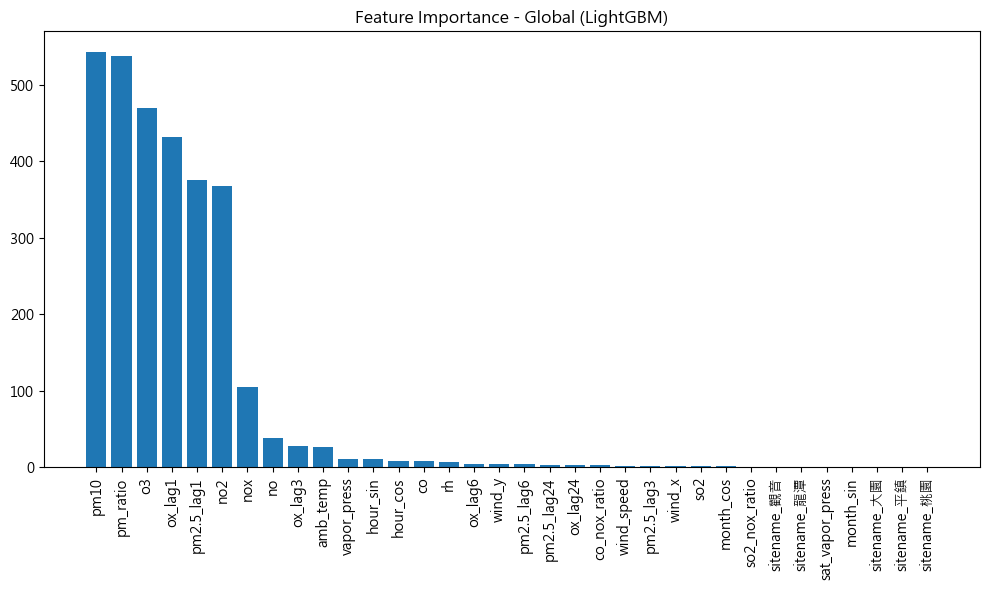


==================== 開始 Section 2: Local Models ====================
⠴ Local Model [桃園站] - 評估算法: LightGBM...g...
✓ [桃園站] 完成！最佳算法：LightGBM


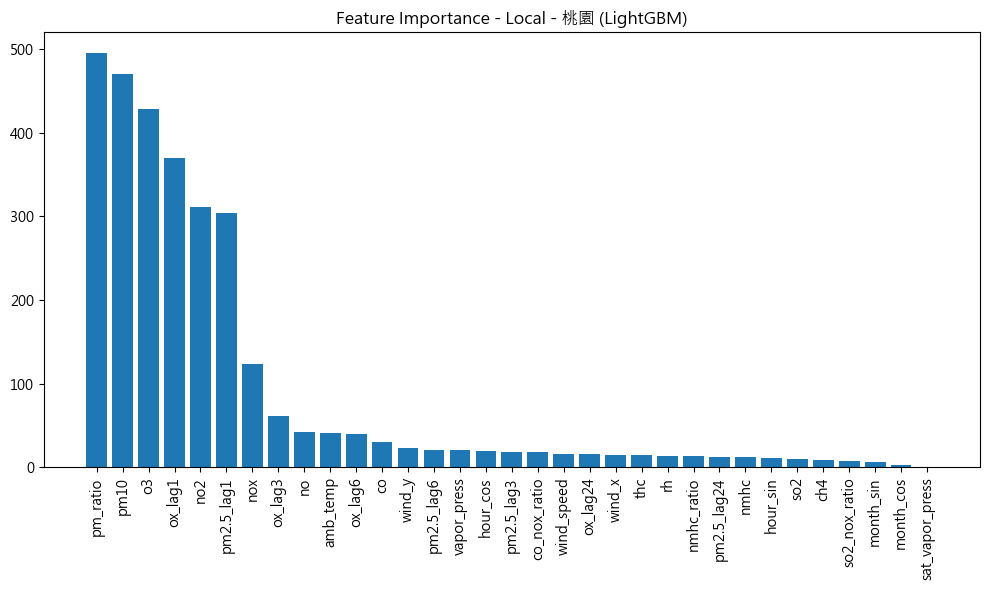

⠇ Local Model [平鎮站] - 評估算法: LightGBM...g...
✓ [平鎮站] 完成！最佳算法：LightGBM


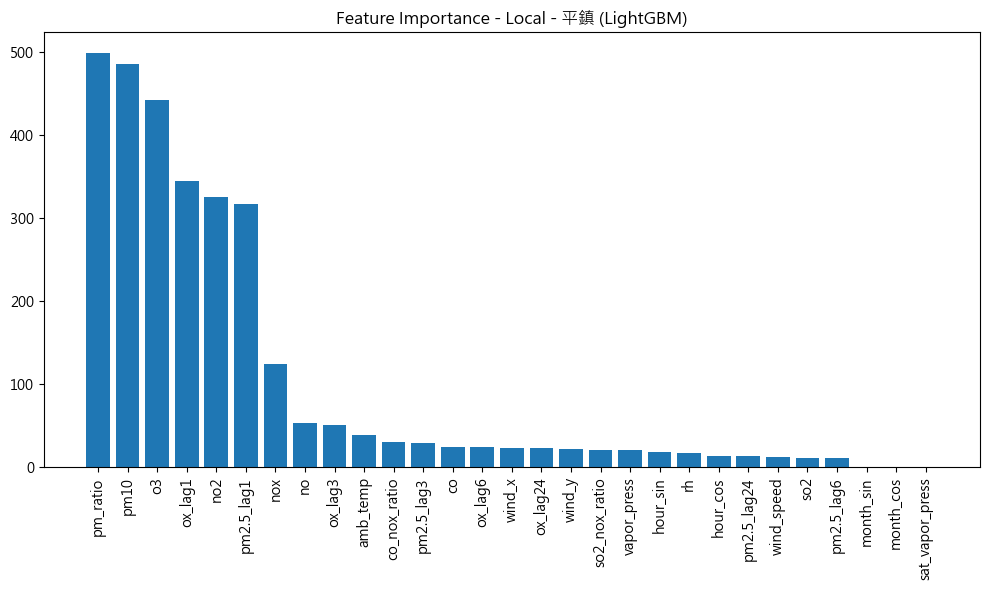

⠧ Local Model [大園站] - 評估算法: LightGBM...g...
✓ [大園站] 完成！最佳算法：LightGBM


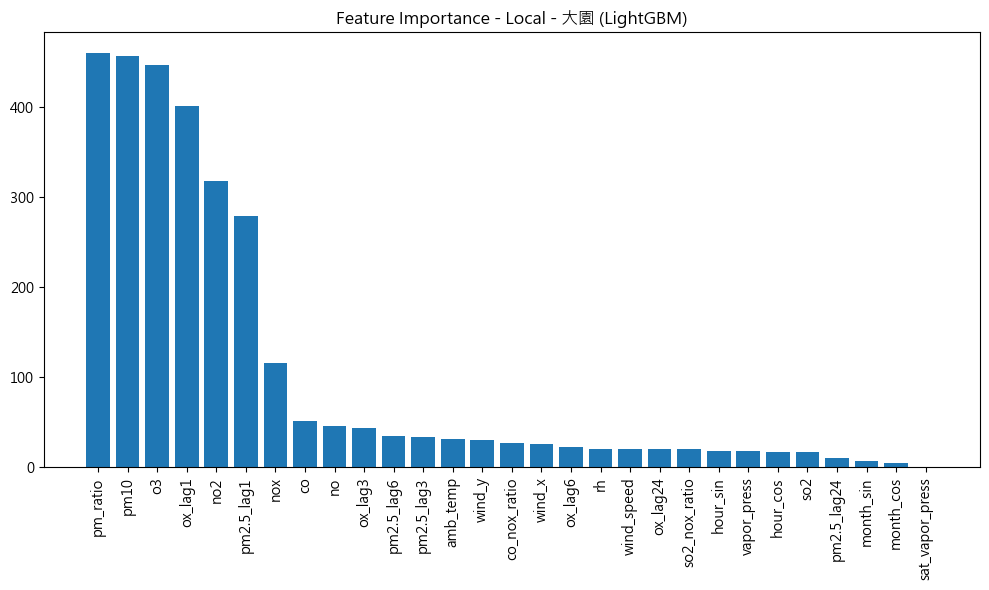

⠴ Local Model [觀音站] - 評估算法: LightGBM...g...
✓ [觀音站] 完成！最佳算法：LightGBM


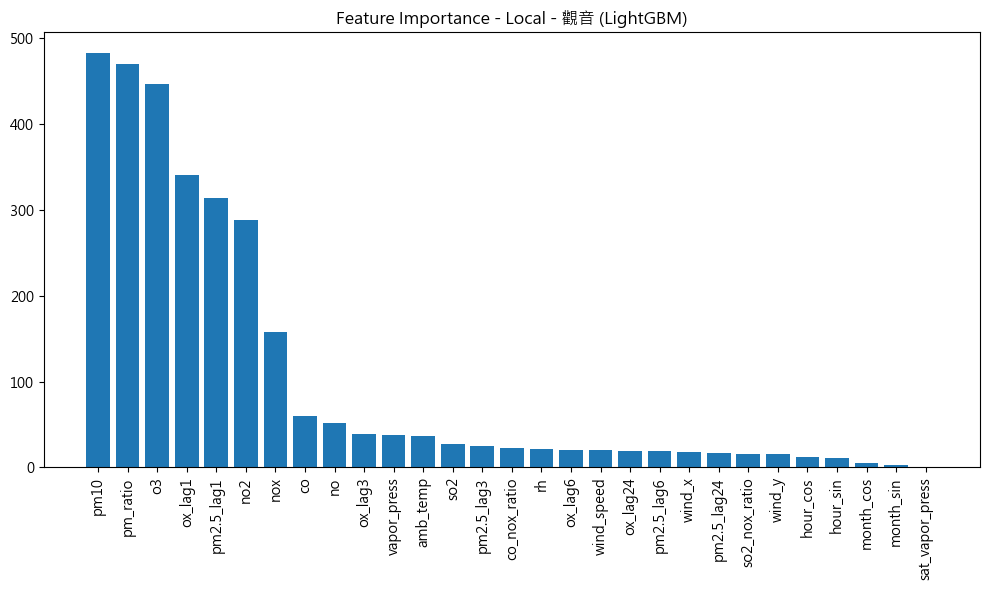

⠸ Local Model [龍潭站] - 評估算法: LightGBM...g...
✓ [龍潭站] 完成！最佳算法：LightGBM


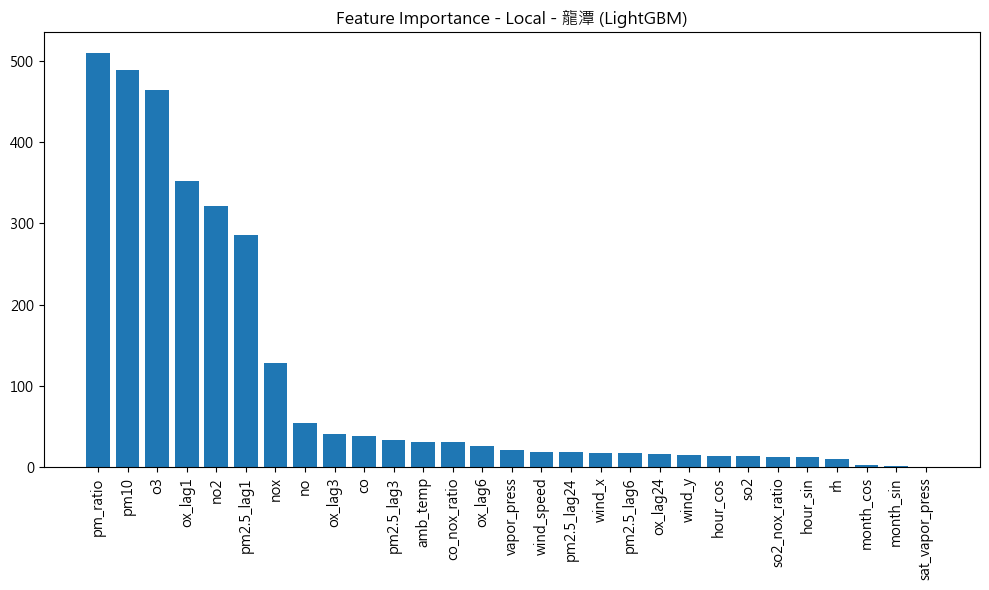


==================== 開始 Section 3: 群內跨站泛化 ====================
⠇ 跨站實驗 [觀音 -> 大園] - 評估算法: LightGBM...g...
✓ 跨站 [觀音 -> 大園] 完成！最佳算法：LightGBM
⠏ 跨站實驗 [大園 -> 觀音] - 評估算法: LightGBM...g...
✓ 跨站 [大園 -> 觀音] 完成！最佳算法：LightGBM
⠹ 跨站實驗 [桃園 -> 平鎮] - 評估算法: LightGBM...g...
✓ 跨站 [桃園 -> 平鎮] 完成！最佳算法：LightGBM
⠙ 跨站實驗 [平鎮 -> 桃園] - 評估算法: LightGBM...g...
✓ 跨站 [平鎮 -> 桃園] 完成！最佳算法：LightGBM

==================== Section 4: 總結彙整表 (共16個模型) ====================
  模型類型 訓練站 測試站    目標     最佳算法   RMSE    MAE     R²
Global  五站  五站 pm2.5 LightGBM 0.5398 0.2852 0.9968
Global  五站  五站    ox LightGBM 0.7429 0.5261 0.9940
 Local  桃園  桃園 pm2.5 LightGBM 0.7654 0.3773 0.9940
 Local  桃園  桃園    ox LightGBM 0.9361 0.6727 0.9901
 Local  平鎮  平鎮 pm2.5 LightGBM 0.7836 0.4090 0.9934
 Local  平鎮  平鎮    ox LightGBM 0.8794 0.6387 0.9904
 Local  大園  大園 pm2.5 LightGBM 1.0382 0.4608 0.9881
 Local  大園  大園    ox LightGBM 0.9907 0.7113 0.9891
 Local  觀音  觀音 pm2.5 LightGBM 1.0511 0.4572 0.9876
 Local  觀音  觀音    ox LightGBM 0.8358 0.5083 0.9924
 Local

In [16]:
# ==============================================================================
# 桃園空品監測模型訓練與評估 (支援 Rich Status 穩定動畫版)
# ==============================================================================

import time
import warnings
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import TimeSeriesSplit
from sklearn.multioutput import MultiOutputRegressor
from sklearn.preprocessing import MinMaxScaler

warnings.filterwarnings("ignore")

# 1. 載入 Rich Console (使用 force_jupyter=False 預防死鎖)
try:
    from rich.console import Console

    console = Console(force_jupyter=False)
    HAS_RICH = True
except ImportError:
    HAS_RICH = False
    print("💡 提示：建議安裝 rich 套件以獲得最佳動畫效果 (pip install rich)")

# 2. 嘗試匯入 LightGBM
try:
    from lightgbm import LGBMRegressor

    HAS_LGBM = True
except ImportError:
    HAS_LGBM = False

# 3. 設定繪圖字型
plt.rcParams["font.sans-serif"] = [
    "Microsoft JhengHei",
    "SimHei",
    "Noto Sans CJK TC",
    "Arial",
]
plt.rcParams["axes.unicode_minus"] = False


# 4. 輔助日誌輸出函數 (相容 RichConsole 與 普通 print)
def log(msg):
    if HAS_RICH:
        console.print(msg)
    else:
        print(msg)


# ------------------------------------------------------------------------------
# 步驟 1: 特徵工程函數
# ------------------------------------------------------------------------------


def apply_feature_engineering(df):
    """套用 SDD 規範之特徵工程邏輯"""
    df = df.copy()

    # 轉為 datetime 並提取 hour/month
    df["publishtime"] = pd.to_datetime(df["publishtime"])
    df["hour"] = df["publishtime"].dt.hour
    df["month"] = df["publishtime"].dt.month

    # 轉型防錯
    numeric_cols = ["wind_direc", "wind_speed", "pm2.5", "ox"]
    for col in numeric_cols:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce")

    # 1. 時間特徵循環編碼
    df["hour_sin"] = np.sin(2 * np.pi * df["hour"] / 24)
    df["hour_cos"] = np.cos(2 * np.pi * df["hour"] / 24)
    df["month_sin"] = np.sin(2 * np.pi * df["month"] / 12)
    df["month_cos"] = np.cos(2 * np.pi * df["month"] / 12)

    # 移除原始時間欄位
    cols_to_drop = [
        c
        for c in ["hour", "month", "publishtime", "mon", "date"]
        if c in df.columns
    ]
    df.drop(columns=cols_to_drop, inplace=True)

    # 2. 風向分解
    rad = np.radians(df["wind_direc"])
    df["wind_x"] = df["wind_speed"] * np.cos(rad)
    df["wind_y"] = df["wind_speed"] * np.sin(rad)

    if "wind_direc" in df.columns:
        df.drop(columns=["wind_direc"], inplace=True)

    # 3. Lag features
    lag_lags = [1, 3, 6, 24]
    targets_for_lag = ["pm2.5", "ox"]

    for target in targets_for_lag:
        for lag in lag_lags:
            col_name = f"{target}_lag{lag}"
            if "sitename" in df.columns:
                df[col_name] = df.groupby("sitename")[target].shift(lag)
            else:
                df[col_name] = df[target].shift(lag)

    # 丟棄 NaN 列
    df.dropna(inplace=True)
    df.reset_index(drop=True, inplace=True)

    return df


# ------------------------------------------------------------------------------
# 步驟 2: 演算法與評估函數
# ------------------------------------------------------------------------------


def get_candidate_models():
    """依據 SDD 規範定義演算法候選清單"""
    models = {
        "RandomForest": RandomForestRegressor(
            n_estimators=100, random_state=42, n_jobs=-1
        ),
        "GradientBoosting": MultiOutputRegressor(
            GradientBoostingRegressor(n_estimators=100, random_state=42)
        ),
    }
    if HAS_LGBM:
        models["LightGBM"] = MultiOutputRegressor(
            LGBMRegressor(n_estimators=100, random_state=42, verbose=-1)
        )
    return models


def evaluate_metrics(y_true, y_pred, targets=["pm2.5", "ox"]):
    """計算評估指標：RMSE, MAE, R²"""
    results = {}
    for i, target in enumerate(targets):
        if y_true.ndim > 1:
            yt = (
                y_true.iloc[:, i]
                if isinstance(y_true, pd.DataFrame)
                else y_true[:, i]
            )
            yp = y_pred[:, i]
        else:
            yt = y_true
            yp = y_pred

        rmse = np.sqrt(mean_squared_error(yt, yp))
        mae = mean_absolute_error(yt, yp)
        r2 = r2_score(yt, yp)
        results[target] = {"RMSE": rmse, "MAE": mae, "R2": r2}
    return results


def plot_feature_importance(model, feature_names, title):
    """繪製特徵重要性圖表"""
    plt.figure(figsize=(10, 6))
    if hasattr(model, "feature_importances_"):
        importances = model.feature_importances_
    elif hasattr(model, "estimators_"):
        importances = np.mean(
            [est.feature_importances_ for est in model.estimators_], axis=0
        )
    else:
        return

    indices = np.argsort(importances)[::-1]
    plt.title(f"Feature Importance - {title}")
    plt.bar(range(len(importances)), importances[indices], align="center")
    plt.xticks(
        range(len(importances)),
        [feature_names[i] for i in indices],
        rotation=90,
    )
    plt.tight_layout()
    plt.show()


# 全域容器與 TimeSeriesSplit
summary_records = []
tscv = TimeSeriesSplit(n_splits=5, gap=24)

# ==============================================================================
# Section 1：Global Model
# ==============================================================================
log("\n==================== 開始 Section 1: Global Model ====================")

if HAS_RICH:
    status = console.status(
        "[bold cyan]正在處理 Global Model 特徵工程與模型交叉驗證...",
        spinner="dots",
    )
    status.start()

# 1. 讀入資料
df_global_train = pd.read_csv("2025桃園五站空品監測資料_精簡20欄合體版.csv")
df_global_test = pd.read_csv(
    "2026_01_07桃園五站空品監測資料_精簡20欄合體版.csv"
)

# 2. 時間篩選 (2026 1~3 月)
df_global_test["publishtime"] = pd.to_datetime(df_global_test["publishtime"])
df_global_test = df_global_test[
    (df_global_test["publishtime"].dt.month >= 1)
    & (df_global_test["publishtime"].dt.month <= 3)
].copy()

# 3. 特徵工程
df_global_train = apply_feature_engineering(df_global_train)
df_global_test = apply_feature_engineering(df_global_test)

# 4. OneHot Encoding
df_global_all = pd.concat(
    [df_global_train, df_global_test], keys=["train", "test"]
)
df_global_all = pd.get_dummies(
    df_global_all, columns=["sitename"], drop_first=False
)

X_g_train = df_global_all.xs("train").drop(columns=["pm2.5", "ox"])
y_g_train = df_global_all.xs("train")[["pm2.5", "ox"]]
X_g_test = df_global_all.xs("test").drop(columns=["pm2.5", "ox"])
y_g_test = df_global_all.xs("test")[["pm2.5", "ox"]]

# 5. MinMaxScaler
scaler_g = MinMaxScaler()
X_g_train_scaled = scaler_g.fit_transform(X_g_train)
X_g_test_scaled = scaler_g.transform(X_g_test)

# 6. TimeSeriesSplit CV 跑算法比較
best_model_name = None
lowest_cv_rmse = float("inf")
models = get_candidate_models()

for name, model in models.items():
    if HAS_RICH:
        status.update(
            f"[bold cyan]Global Model - 正在評估演算法: {name}..."
        )

    cv_rmses = []
    for train_idx, val_idx in tscv.split(X_g_train_scaled):
        X_tr, X_val = X_g_train_scaled[train_idx], X_g_train_scaled[val_idx]
        y_tr, y_val = y_g_train.iloc[train_idx], y_g_train.iloc[val_idx]

        model.fit(X_tr, y_tr)
        preds = model.predict(X_val)

        rmse_p = np.sqrt(mean_squared_error(y_val["pm2.5"], preds[:, 0]))
        rmse_o = np.sqrt(mean_squared_error(y_val["ox"], preds[:, 1]))
        cv_rmses.append((rmse_p + rmse_o) / 2)

    mean_cv_rmse = np.mean(cv_rmses)
    if mean_cv_rmse < lowest_cv_rmse:
        lowest_cv_rmse = mean_cv_rmse
        best_model_name = name

# 7. 最佳模型預測
best_g_model = get_candidate_models()[best_model_name]
best_g_model.fit(X_g_train_scaled, y_g_train)
g_preds = best_g_model.predict(X_g_test_scaled)

if HAS_RICH:
    status.stop()
log(f"[green]✓ Global Model 完成！最佳算法：{best_model_name}[/green]")

# 8. 記錄結果與繪圖
g_eval = evaluate_metrics(y_g_test, g_preds, targets=["pm2.5", "ox"])
for target in ["pm2.5", "ox"]:
    summary_records.append(
        {
            "模型類型": "Global",
            "訓練站": "五站",
            "測試站": "五站",
            "目標": target,
            "最佳算法": best_model_name,
            "RMSE": round(g_eval[target]["RMSE"], 4),
            "MAE": round(g_eval[target]["MAE"], 4),
            "R²": round(g_eval[target]["R2"], 4),
        }
    )

plot_feature_importance(
    best_g_model, X_g_train.columns, f"Global ({best_model_name})"
)

# ==============================================================================
# Section 2：Local Models
# ==============================================================================
log("\n==================== 開始 Section 2: Local Models ====================")

stations = ["桃園", "平鎮", "大園", "觀音", "龍潭"]

for st in stations:
    if HAS_RICH:
        status = console.status(
            f"[bold cyan]Local Model [{st}站] - 讀取資料與進行特徵工程...",
            spinner="dots",
        )
        status.start()

    # 1. 讀取數據
    if st == "桃園":
        df_l_train = pd.read_csv("2025桃園站空品監測資料_完整科學指標擴增版.csv")
        df_l_test = pd.read_csv(
            "2026_01_07桃園站空品監測資料_完整科學指標擴增版.csv"
        )
    else:
        df_all_tr = pd.read_csv("2025桃園五站空品監測資料_精簡20欄合體版.csv")
        df_all_te = pd.read_csv(
            "2026_01_07桃園五站空品監測資料_精簡20欄合體版.csv"
        )

        df_l_train = df_all_tr[df_all_tr["sitename"] == st].copy()
        df_l_test = df_all_te[df_all_te["sitename"] == st].copy()

    # 2. 篩選 2026 1~3 月
    df_l_test["publishtime"] = pd.to_datetime(df_l_test["publishtime"])
    df_l_test = df_l_test[
        (df_l_test["publishtime"].dt.month >= 1)
        & (df_l_test["publishtime"].dt.month <= 3)
    ].copy()

    # 3. 套用特徵工程
    df_l_train = apply_feature_engineering(df_l_train)
    df_l_test = apply_feature_engineering(df_l_test)

    if "sitename" in df_l_train.columns:
        df_l_train.drop(columns=["sitename"], inplace=True)
    if "sitename" in df_l_test.columns:
        df_l_test.drop(columns=["sitename"], inplace=True)

    X_l_train = df_l_train.drop(columns=["pm2.5", "ox"])
    y_l_train = df_l_train[["pm2.5", "ox"]]
    X_l_test = df_l_test.drop(columns=["pm2.5", "ox"])
    y_l_test = df_l_test[["pm2.5", "ox"]]

    # 4. MinMaxScaler
    scaler_l = MinMaxScaler()
    X_l_train_scaled = scaler_l.fit_transform(X_l_train)
    X_l_test_scaled = scaler_l.transform(X_l_test)

    # 5. TimeSeriesSplit CV 評估
    best_st_model_name = None
    lowest_st_cv_rmse = float("inf")
    models = get_candidate_models()

    for name, model in models.items():
        if HAS_RICH:
            status.update(
                f"[bold cyan]Local Model [{st}站] - 評估算法: {name}..."
            )

        cv_rmses = []
        for train_idx, val_idx in tscv.split(X_l_train_scaled):
            X_tr, X_val = (
                X_l_train_scaled[train_idx],
                X_l_train_scaled[val_idx],
            )
            y_tr, y_val = y_l_train.iloc[train_idx], y_l_train.iloc[val_idx]

            model.fit(X_tr, y_tr)
            preds = model.predict(X_val)

            rmse_p = np.sqrt(mean_squared_error(y_val["pm2.5"], preds[:, 0]))
            rmse_o = np.sqrt(mean_squared_error(y_val["ox"], preds[:, 1]))
            cv_rmses.append((rmse_p + rmse_o) / 2)

        mean_cv_rmse = np.mean(cv_rmses)
        if mean_cv_rmse < lowest_st_cv_rmse:
            lowest_st_cv_rmse = mean_cv_rmse
            best_st_model_name = name

    # 6. 重新 fit 並預測 Test
    best_l_model = get_candidate_models()[best_st_model_name]
    best_l_model.fit(X_l_train_scaled, y_l_train)
    l_preds = best_l_model.predict(X_l_test_scaled)

    if HAS_RICH:
        status.stop()
    log(f"[green]✓ [{st}站] 完成！最佳算法：{best_st_model_name}[/green]")

    # 7. 記錄指標與繪圖
    l_eval = evaluate_metrics(y_l_test, l_preds, targets=["pm2.5", "ox"])
    for target in ["pm2.5", "ox"]:
        summary_records.append(
            {
                "模型類型": "Local",
                "訓練站": st,
                "測試站": st,
                "目標": target,
                "最佳算法": best_st_model_name,
                "RMSE": round(l_eval[target]["RMSE"], 4),
                "MAE": round(l_eval[target]["MAE"], 4),
                "R²": round(l_eval[target]["R2"], 4),
            }
        )

    plot_feature_importance(
        best_l_model, X_l_train.columns, f"Local - {st} ({best_st_model_name})"
    )

# ==============================================================================
# Section 3：群內跨站泛化
# ==============================================================================
log(
    "\n==================== 開始 Section 3: 群內跨站泛化 ===================="
)

cross_experiments = [
    ("觀音", "大園"),
    ("大園", "觀音"),
    ("桃園", "平鎮"),
    ("平鎮", "桃園"),
]

df_comb_train = pd.read_csv("2025桃園五站空品監測資料_精簡20欄合體版.csv")
df_comb_test = pd.read_csv(
    "2026_01_07桃園五站空品監測資料_精簡20欄合體版.csv"
)

# 篩選 1~3 月
df_comb_test["publishtime"] = pd.to_datetime(df_comb_test["publishtime"])
df_comb_test = df_comb_test[
    (df_comb_test["publishtime"].dt.month >= 1)
    & (df_comb_test["publishtime"].dt.month <= 3)
].copy()

for train_st, test_st in cross_experiments:
    if HAS_RICH:
        status = console.status(
            f"[bold cyan]跨站實驗 [{train_st} -> {test_st}] - 資料準備中...",
            spinner="dots",
        )
        status.start()

    # 1. 拆分
    df_c_tr = df_comb_train[df_comb_train["sitename"] == train_st].copy()
    df_c_te = df_comb_test[df_comb_test["sitename"] == test_st].copy()

    # 2. 特徵工程
    df_c_tr = apply_feature_engineering(df_c_tr)
    df_c_te = apply_feature_engineering(df_c_te)

    if "sitename" in df_c_tr.columns:
        df_c_tr.drop(columns=["sitename"], inplace=True)
    if "sitename" in df_c_te.columns:
        df_c_te.drop(columns=["sitename"], inplace=True)

    X_c_tr = df_c_tr.drop(columns=["pm2.5", "ox"])
    y_c_tr = df_c_tr["pm2.5"]
    X_c_te = df_c_te.drop(columns=["pm2.5", "ox"])
    y_c_te = df_c_te["pm2.5"]

    # 3. MinMaxScaler
    scaler_c = MinMaxScaler()
    X_c_tr_scaled = scaler_c.fit_transform(X_c_tr)
    X_c_te_scaled = scaler_c.transform(X_c_te)

    # 4. CV 選最佳演算法
    cross_models = {
        "RandomForest": RandomForestRegressor(
            n_estimators=100, random_state=42, n_jobs=-1
        ),
        "GradientBoosting": GradientBoostingRegressor(
            n_estimators=100, random_state=42
        ),
    }
    if HAS_LGBM:
        cross_models["LightGBM"] = LGBMRegressor(
            n_estimators=100, random_state=42, verbose=-1
        )

    best_c_model_name = None
    lowest_c_cv_rmse = float("inf")

    for name, model in cross_models.items():
        if HAS_RICH:
            status.update(
                f"[bold cyan]跨站實驗 [{train_st} -> {test_st}] - 評估算法: {name}..."
            )

        cv_rmses = []
        for train_idx, val_idx in tscv.split(X_c_tr_scaled):
            X_tr, X_val = (
                X_c_tr_scaled[train_idx],
                X_c_tr_scaled[val_idx],
            )
            y_tr, y_val = y_c_tr.iloc[train_idx], y_c_tr.iloc[val_idx]

            model.fit(X_tr, y_tr)
            preds = model.predict(X_val)

            rmse = np.sqrt(mean_squared_error(y_val, preds))
            cv_rmses.append(rmse)

        mean_cv_rmse = np.mean(cv_rmses)
        if mean_cv_rmse < lowest_c_cv_rmse:
            lowest_c_cv_rmse = mean_cv_rmse
            best_c_model_name = name

    # 5. fit 並預測
    best_c_model = cross_models[best_c_model_name]
    best_c_model.fit(X_c_tr_scaled, y_c_tr)
    c_preds = best_c_model.predict(X_c_te_scaled)

    if HAS_RICH:
        status.stop()
    log(
        f"[green]✓ 跨站 [{train_st} -> {test_st}] 完成！最佳算法：{best_c_model_name}[/green]"
    )

    # 6. 記錄結果
    c_eval = evaluate_metrics(y_c_te, c_preds, targets=["pm2.5"])
    summary_records.append(
        {
            "模型類型": "跨站",
            "訓練站": train_st,
            "測試站": test_st,
            "目標": "pm2.5",
            "最佳算法": best_c_model_name,
            "RMSE": round(c_eval["pm2.5"]["RMSE"], 4),
            "MAE": round(c_eval["pm2.5"]["MAE"], 4),
            "R²": round(c_eval["pm2.5"]["R2"], 4),
        }
    )

# ==============================================================================
# Section 4：總結彙整表輸出
# ==============================================================================
log(
    "\n==================== Section 4: 總結彙整表 (共16個模型) ===================="
)

df_summary = pd.DataFrame(summary_records)
log(
    df_summary.to_string(
        index=False,
        columns=[
            "模型類型",
            "訓練站",
            "測試站",
            "目標",
            "最佳算法",
            "RMSE",
            "MAE",
            "R²",
        ],
    )
)

df_summary.to_csv("capstone_summary_table.csv", index=False, encoding="utf-8-sig")
log("\n[bold green][成功] 總結表已匯出至 capstone_summary_table.csv[/bold green]")

### 最佳模型：實際值 vs 預測值

⠸ 正在載入訓練與 2026 Q1 測試資料...⠋ 正在載入訓練與 2026 Q1 測試資料...
✓ 前置處理與特徵工程完成！

==================== 執行 Global 模型 (五站合體) ====================
⠇ 正在訓練 Global 模型.....⠋ 正在訓練 Global 模型...
⠴ 正在載入訓練與 2026 Q1 測試資料...

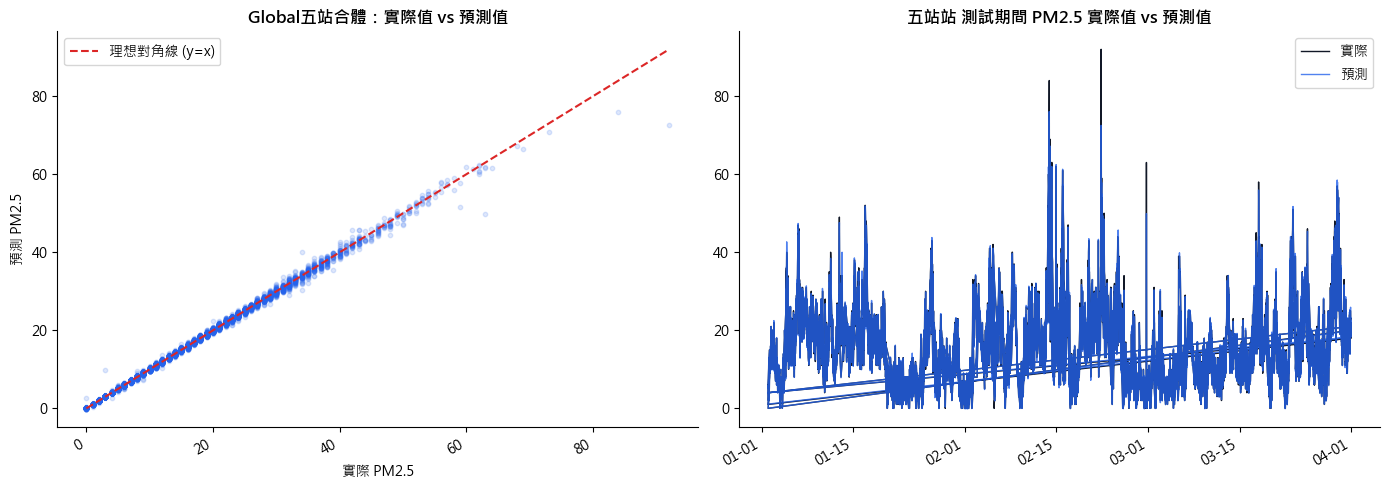

[已儲存圖表] pred_vs_actual_Global五站合體_pm2.5.png
[已存檔 CSV] pred_Global_pm2.5.csv
⠴ 正在載入訓練與 2026 Q1 測試資料...

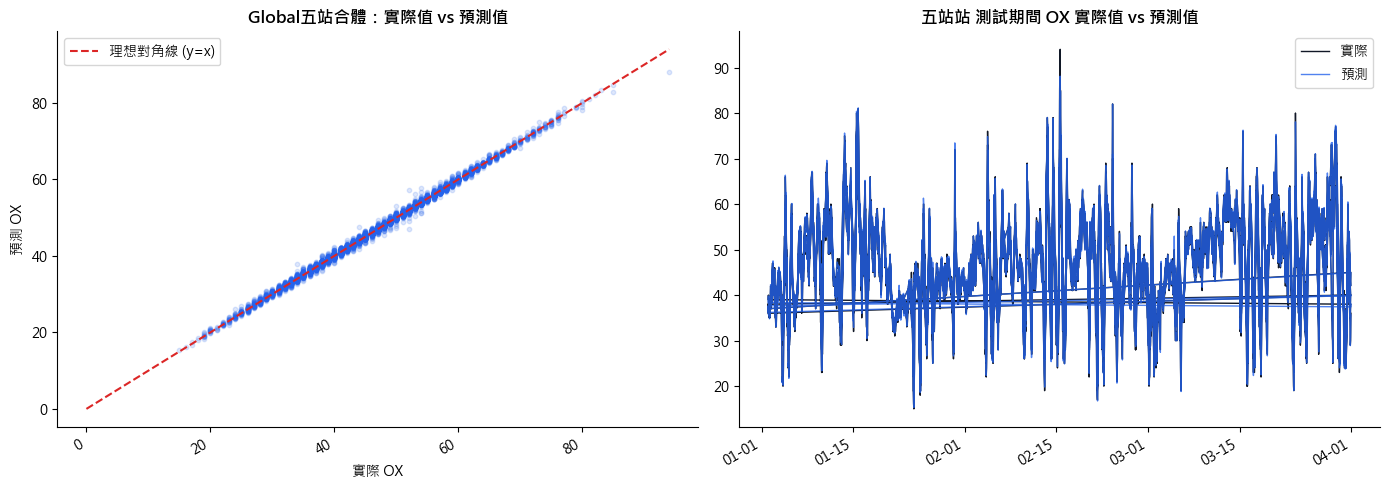

[已儲存圖表] pred_vs_actual_Global五站合體_ox.png
[已存檔 CSV] pred_Global_ox.csv

==================== 執行 Local 模型 (單站獨立) ====================
⠹ 正在訓練 Local [桃園] 模型...0m⠋ 正在訓練 Local [桃園] 模型...
⠧ 正在載入訓練與 2026 Q1 測試資料...

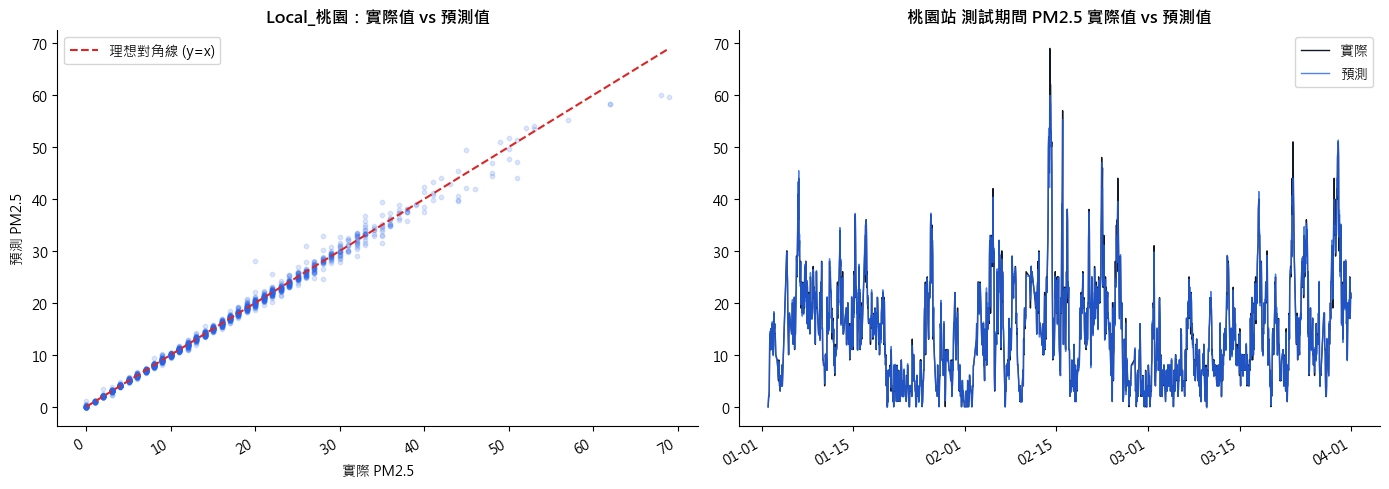

[已儲存圖表] pred_vs_actual_Local_桃園_pm2.5.png
[已存檔 CSV] pred_Local_桃園_pm2.5.csv
⠴ 正在載入訓練與 2026 Q1 測試資料...

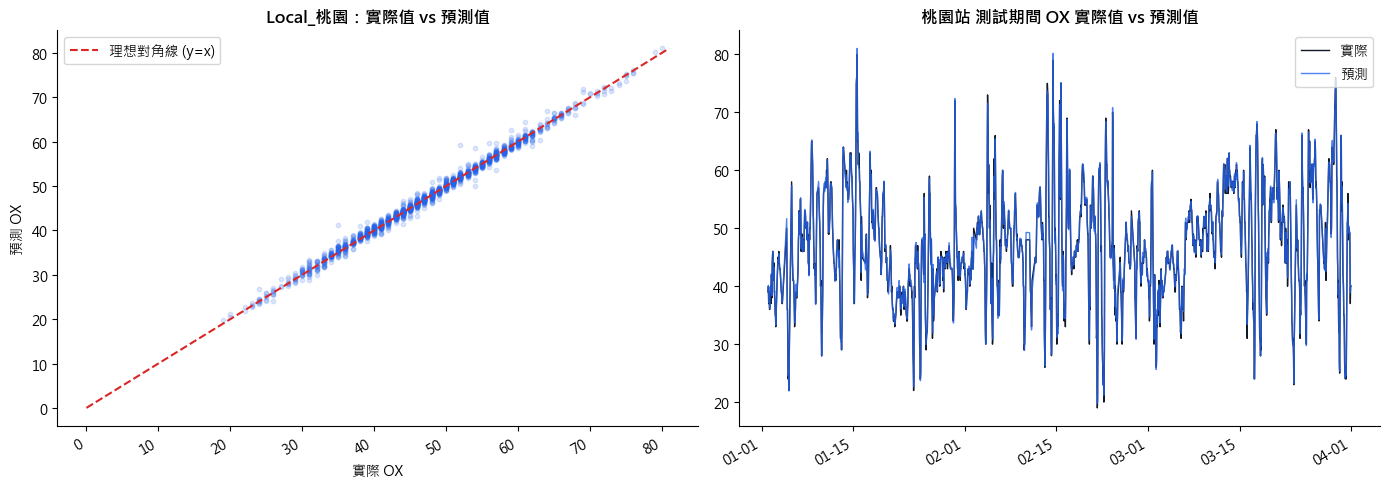

[已儲存圖表] pred_vs_actual_Local_桃園_ox.png
[已存檔 CSV] pred_Local_桃園_ox.csv
⠙ 正在訓練 Local [平鎮] 模型...0m⠋ 正在訓練 Local [平鎮] 模型...
⠇ 正在載入訓練與 2026 Q1 測試資料...

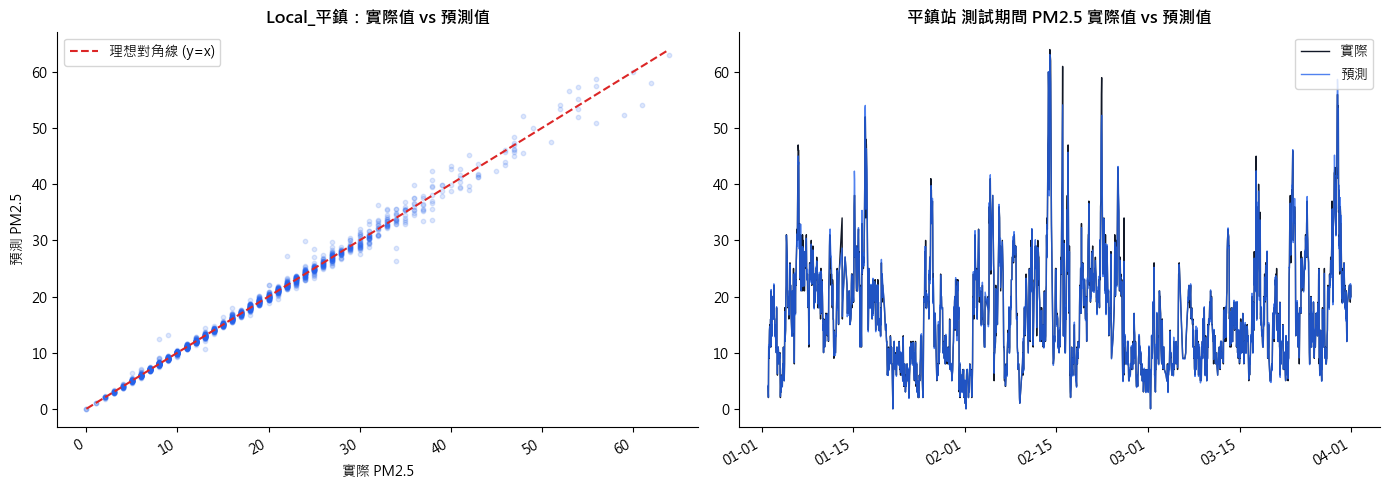

[已儲存圖表] pred_vs_actual_Local_平鎮_pm2.5.png
[已存檔 CSV] pred_Local_平鎮_pm2.5.csv
⠇ 正在載入訓練與 2026 Q1 測試資料...

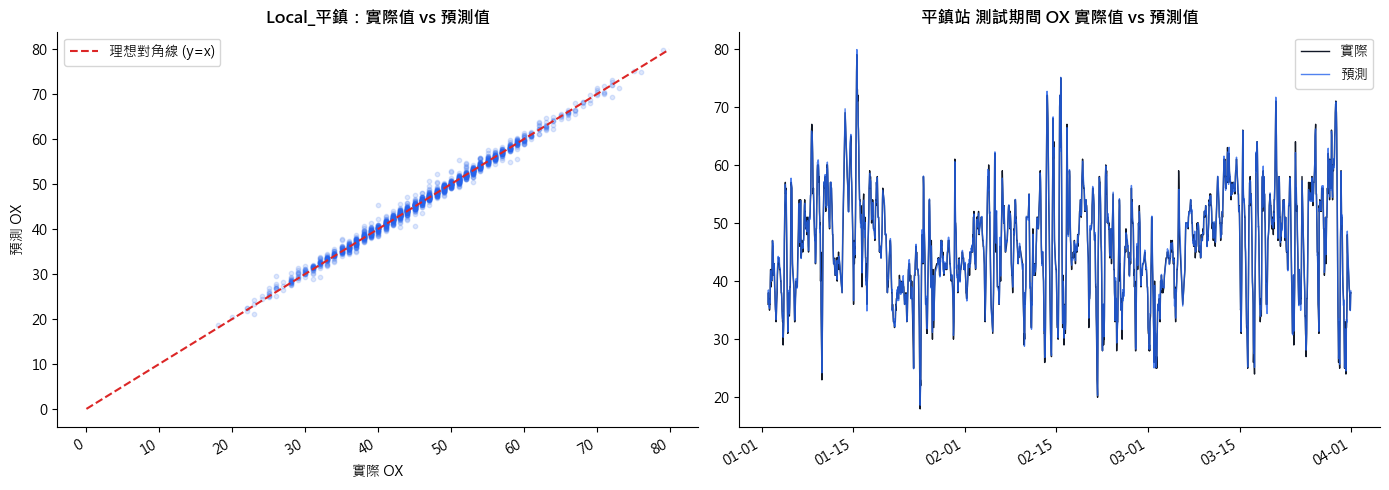

[已儲存圖表] pred_vs_actual_Local_平鎮_ox.png
⠏ 正在載入訓練與 2026 Q1 測試資料...[已存檔 CSV] pred_Local_平鎮_ox.csv
⠙ 正在訓練 Local [大園] 模型...0m
⠼ 正在載入訓練與 2026 Q1 測試資料...

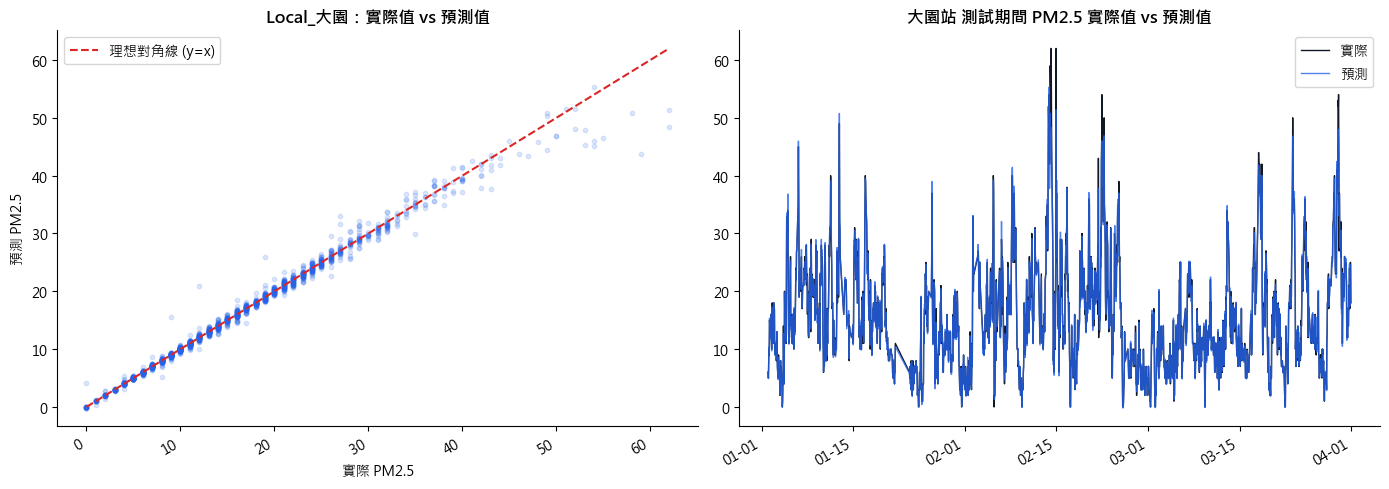

[已儲存圖表] pred_vs_actual_Local_大園_pm2.5.png
[已存檔 CSV] pred_Local_大園_pm2.5.csv
⠹ 正在載入訓練與 2026 Q1 測試資料...

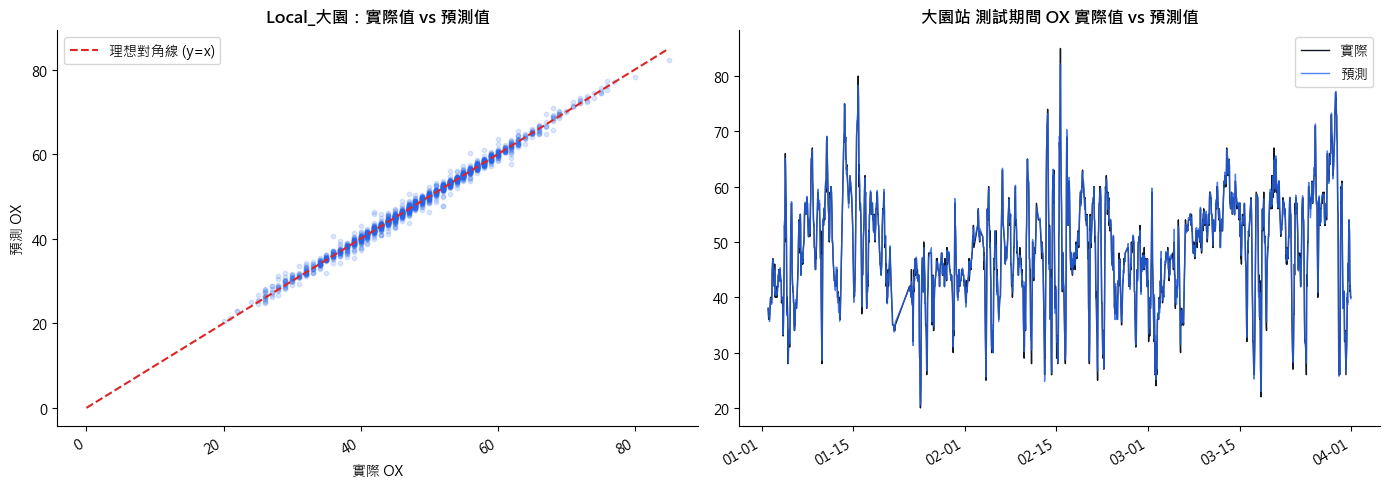

[已儲存圖表] pred_vs_actual_Local_大園_ox.png
[已存檔 CSV] pred_Local_大園_ox.csv
⠙ 正在訓練 Local [觀音] 模型...0m⠋ 正在訓練 Local [觀音] 模型...
⠼ 正在載入訓練與 2026 Q1 測試資料...

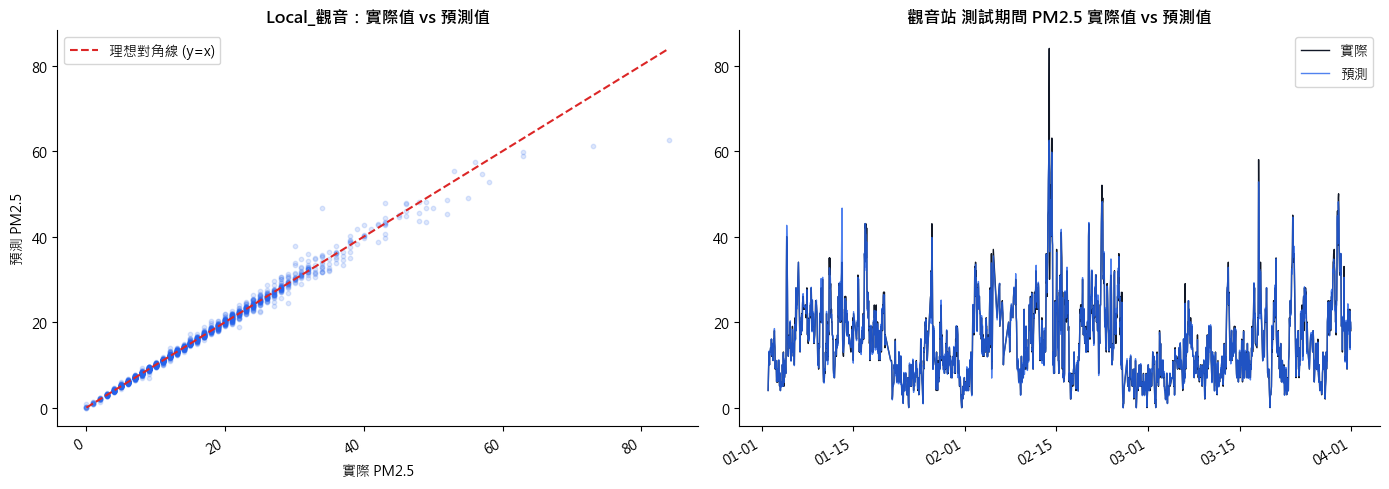

[已儲存圖表] pred_vs_actual_Local_觀音_pm2.5.png
⠴ 正在載入訓練與 2026 Q1 測試資料...[已存檔 CSV] pred_Local_觀音_pm2.5.csv
⠹ 正在載入訓練與 2026 Q1 測試資料...

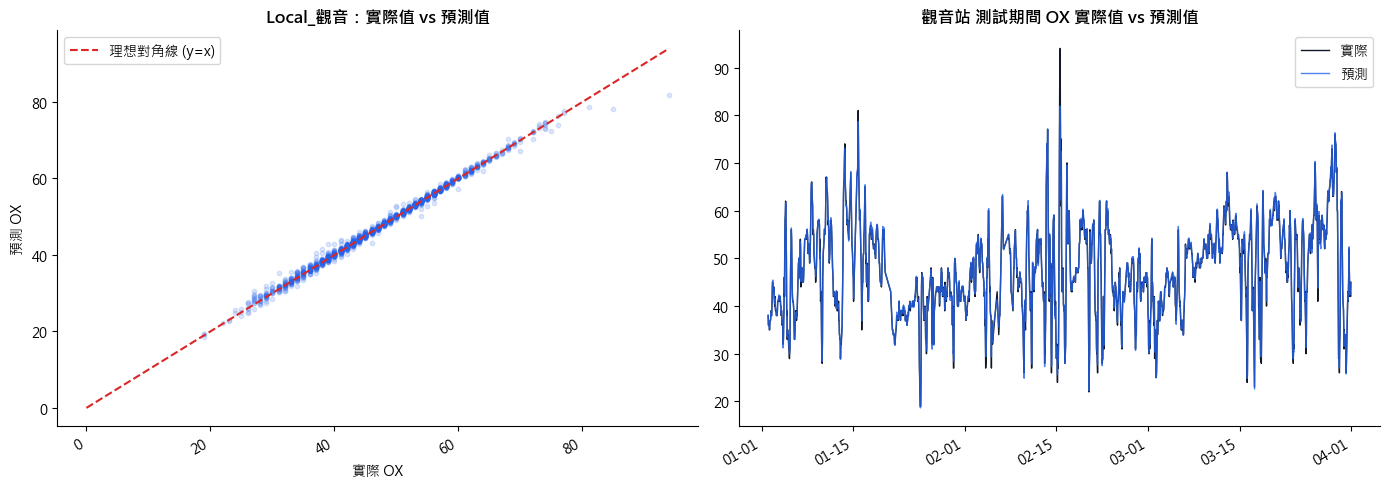

[已儲存圖表] pred_vs_actual_Local_觀音_ox.png
[已存檔 CSV] pred_Local_觀音_ox.csv
⠙ 正在訓練 Local [龍潭] 模型...0m⠋ 正在訓練 Local [龍潭] 模型...
⠸ 正在載入訓練與 2026 Q1 測試資料...

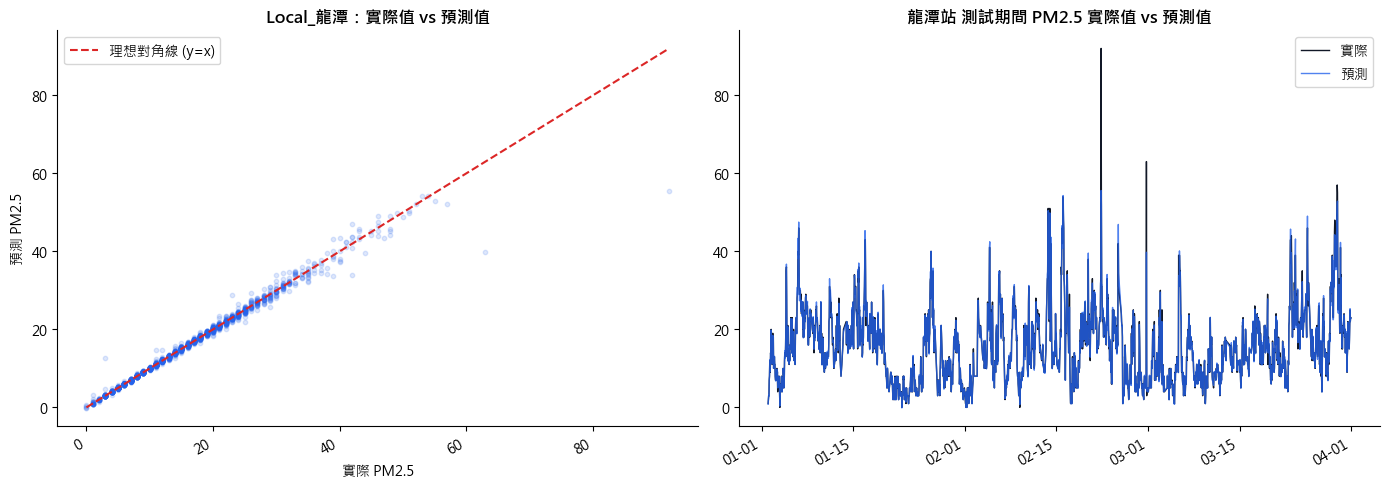

[已儲存圖表] pred_vs_actual_Local_龍潭_pm2.5.png
[已存檔 CSV] pred_Local_龍潭_pm2.5.csv
⠹ 正在載入訓練與 2026 Q1 測試資料...

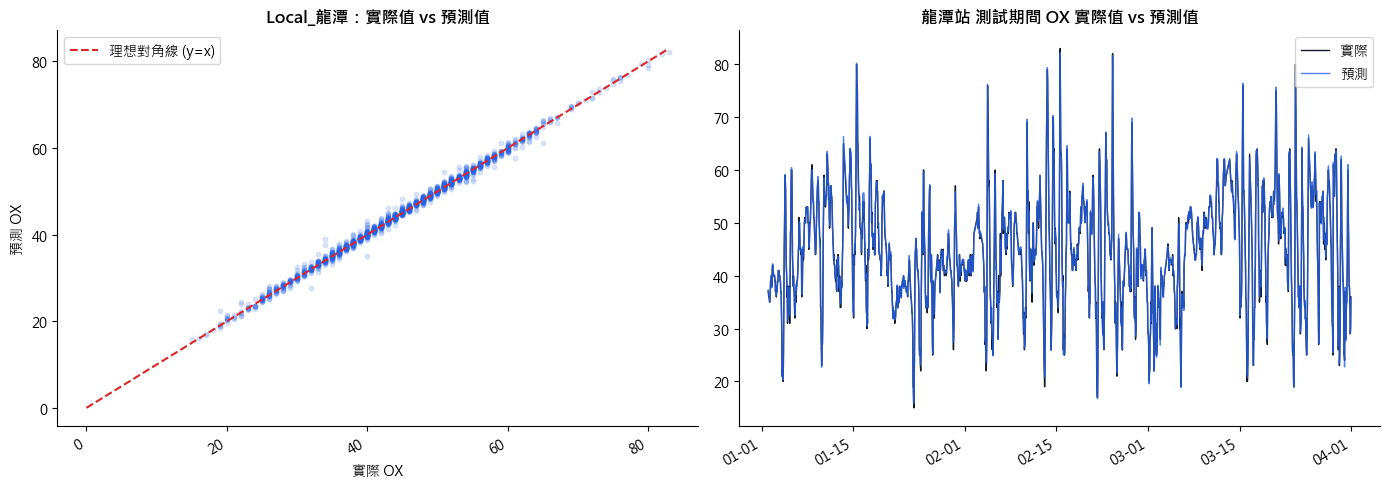

[已儲存圖表] pred_vs_actual_Local_龍潭_ox.png
[已存檔 CSV] pred_Local_龍潭_ox.csv

==================== 執行跨站模型 (pm2.5 only) ====================
⠋ 正在訓練跨站模型 [觀音 → 大園]...0m⠋ 正在訓練跨站模型 [觀音 → 大園]...
⠸ 正在載入訓練與 2026 Q1 測試資料...

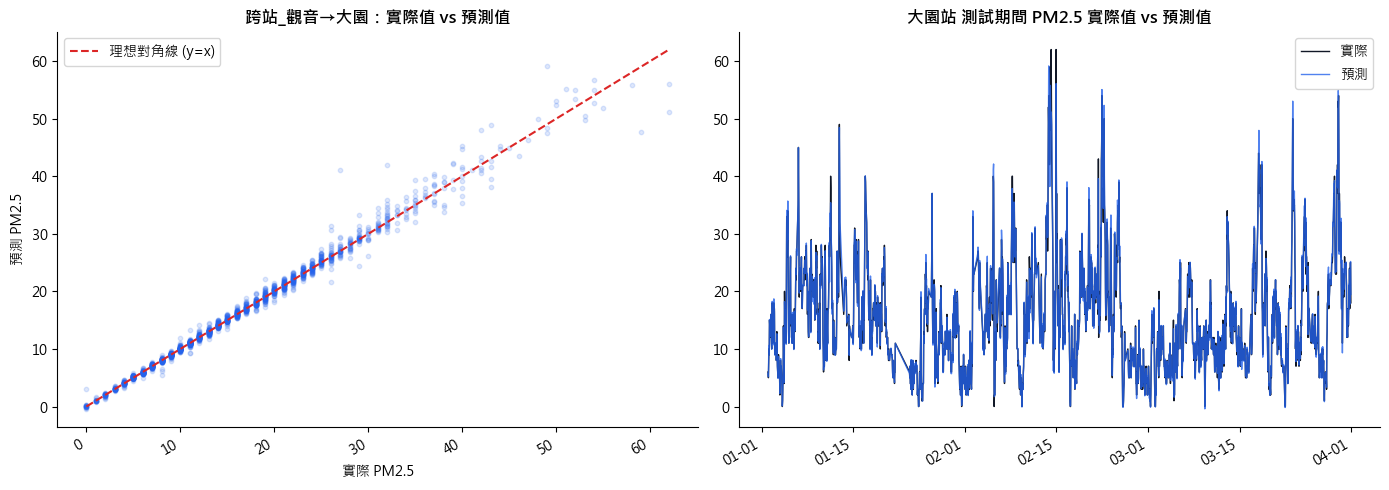

[已儲存圖表] pred_vs_actual_跨站_觀音→大園_pm2.5.png
[已存檔 CSV] pred_cross_觀音_大園_pm2.5.csv
⠋ 正在訓練跨站模型 [大園 → 觀音]...0m⠋ 正在訓練跨站模型 [大園 → 觀音]...
⠹ 正在載入訓練與 2026 Q1 測試資料...

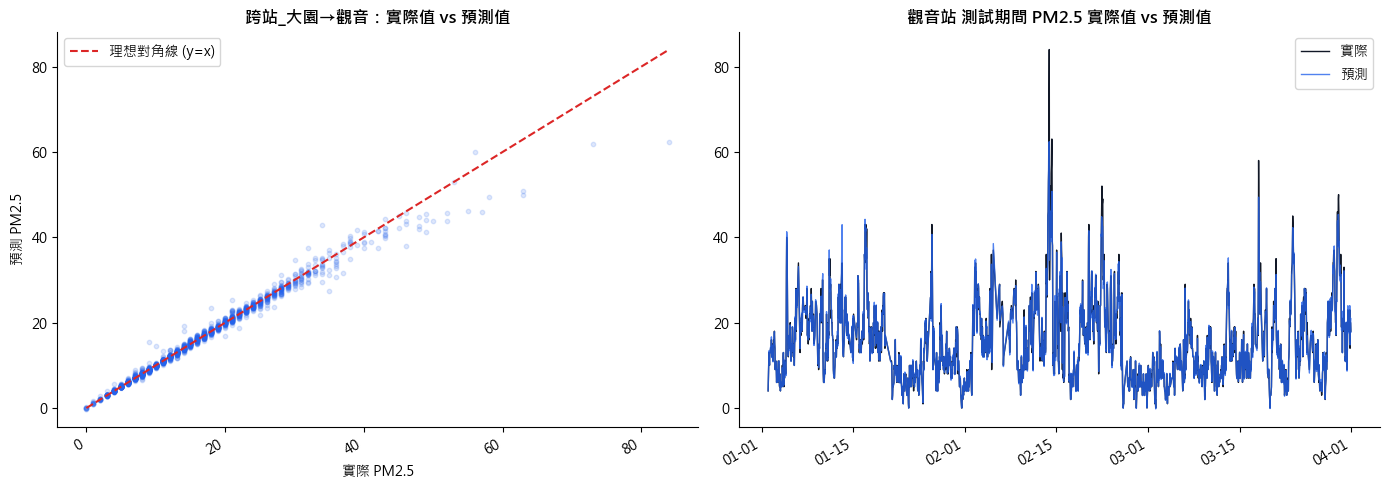

[已儲存圖表] pred_vs_actual_跨站_大園→觀音_pm2.5.png
⠸ 正在載入訓練與 2026 Q1 測試資料...[已存檔 CSV] pred_cross_大園_觀音_pm2.5.csv
⠏ 正在訓練跨站模型 [桃園 → 平鎮]...0m⠋ 正在訓練跨站模型 [桃園 → 平鎮]...
⠸ 正在載入訓練與 2026 Q1 測試資料...

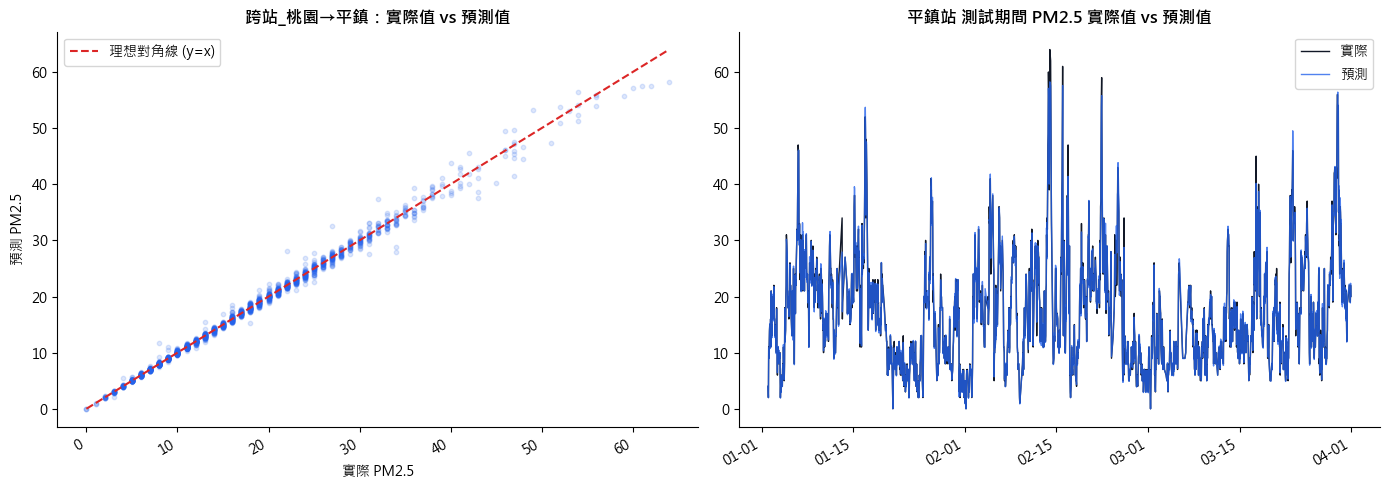

[已儲存圖表] pred_vs_actual_跨站_桃園→平鎮_pm2.5.png
[已存檔 CSV] pred_cross_桃園_平鎮_pm2.5.csv
⠏ 正在訓練跨站模型 [平鎮 → 桃園]...0m⠋ 正在訓練跨站模型 [平鎮 → 桃園]...
⠸ 正在載入訓練與 2026 Q1 測試資料...

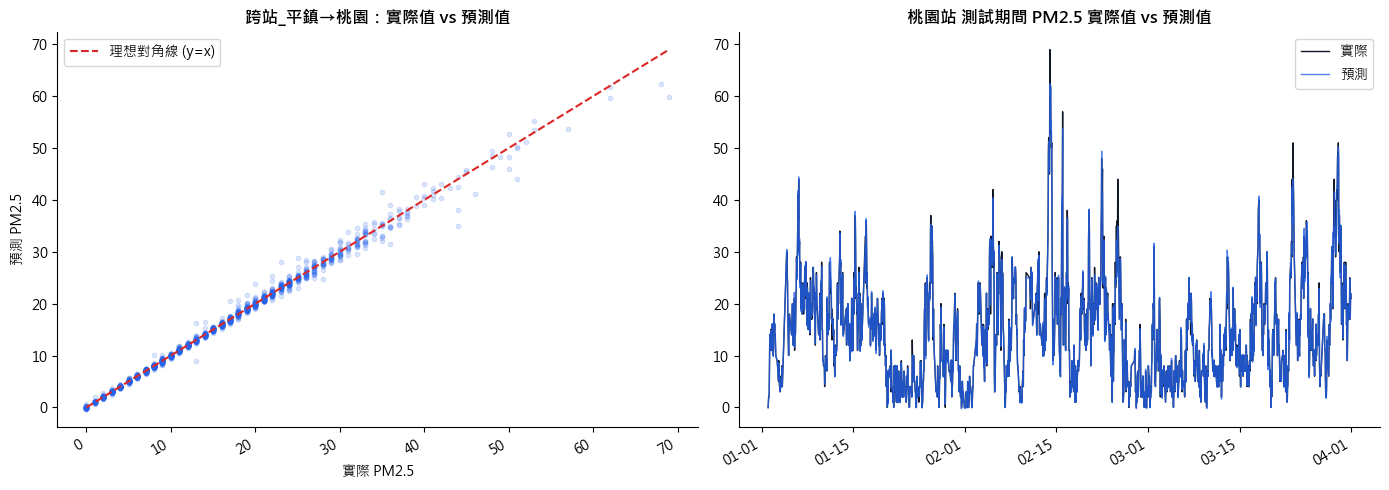

[已儲存圖表] pred_vs_actual_跨站_平鎮→桃園_pm2.5.png
[已存檔 CSV] pred_cross_平鎮_桃園_pm2.5.csv

預測視覺化與資料導出完成 — 檔案總覽
📸 視覺化圖表產出 (16 張 PNG)：
  • Global (2張): pred_vs_actual_Global五站合體_pm2.5.png / ox.png
  • Local  (10張): pred_vs_actual_Local_{站名}_{目標}.png
  • 跨站   (4張):  pred_vs_actual_跨站_{訓練}→{測試}_pm2.5.png

📄 預測結果數據 (16 份 CSV)：
  • pred_Global_pm2.5.csv / pred_Global_ox.csv
  • pred_Local_{站名}_{目標}.csv
  • pred_cross_{訓練}_{測試}_pm2.5.csv

🎉 全部模型執行完成！


In [21]:
# ==============================================================================
# 桃園空品監測資料 — 實際值 vs 預測值視覺化（16個模型）
# SDD 模組：模型訓練、散點擬合圖、Q1 時序比較圖、CSV 預測存檔
# ==============================================================================

import warnings
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from lightgbm import LGBMRegressor
from sklearn.model_selection import TimeSeriesSplit, cross_val_score
from sklearn.multioutput import MultiOutputRegressor
from sklearn.preprocessing import MinMaxScaler

warnings.filterwarnings("ignore")

# 1. 載入 Rich Console (預防 Jupyter 死鎖)
try:
    from rich.console import Console

    console = Console(force_jupyter=False)
    HAS_RICH = True
except ImportError:
    HAS_RICH = False
    print("💡 提示：可安裝 rich 套件以獲得動態 Loading 動畫效果 (pip install rich)")

# 設定繪圖中文字型
plt.rcParams["font.sans-serif"] = [
    "Microsoft JhengHei",
    "SimHei",
    "Noto Sans CJK TC",
    "Arial",
]
plt.rcParams["axes.unicode_minus"] = False


def log(msg):
    if HAS_RICH:
        console.print(msg)
    else:
        print(msg)


# ==============================================================================
# 一、資料載入與前置處理
# ==============================================================================
if HAS_RICH:
    status = console.status(
        "[bold cyan]正在載入訓練與 2026 Q1 測試資料...", spinner="dots"
    )
    status.start()

df_train_5 = pd.read_csv("2025桃園五站空品監測資料_精簡20欄合體版.csv")
df_train_ty = pd.read_csv("2025桃園站空品監測資料_完整科學指標擴增版.csv")
df_test_5 = pd.read_csv("2026_01_07桃園五站空品監測資料_精簡20欄合體版.csv")
df_test_ty = pd.read_csv("2026_01_07桃園站空品監測資料_完整科學指標擴增版.csv")

for df in [df_train_5, df_train_ty, df_test_5, df_test_ty]:
    df["publishtime"] = pd.to_datetime(df["publishtime"])

# 測試資料限定 Q1（1~3 月）
df_test_5 = df_test_5[
    df_test_5["publishtime"].dt.month.isin([1, 2, 3])
].copy()
df_test_ty = df_test_ty[
    df_test_ty["publishtime"].dt.month.isin([1, 2, 3])
].copy()


# ── 特徵工程函式 (修復 wind_direc 字串與缺失值問題) ──
def add_features(df, group_col="sitename"):
    df = df.copy().sort_values(
        ["sitename", "publishtime"]
        if (group_col and group_col in df.columns)
        else ["publishtime"]
    )

    # 風向 sin/cos 分解 (加入 pd.to_numeric 強制轉為數值，非數值字元轉為 NaN 並補值)
    if "wind_direc" in df.columns:
        # 強制將欄位轉為 float，無法轉換的字串會變成 NaN，並以前值/0 填補
        wind_deg = pd.to_numeric(df["wind_direc"], errors="coerce").fillna(
            method="ffill"
        )
        wind_deg = wind_deg.fillna(0)

        df["wind_x"] = np.cos(np.deg2rad(wind_deg))
        df["wind_y"] = np.sin(np.deg2rad(wind_deg))
        df = df.drop(columns=["wind_direc"])

    # 時間週期編碼
    df["hour"] = df["publishtime"].dt.hour
    df["month"] = df["publishtime"].dt.month
    df["hour_sin"] = np.sin(2 * np.pi * df["hour"] / 24)
    df["hour_cos"] = np.cos(2 * np.pi * df["hour"] / 24)
    df["month_sin"] = np.sin(2 * np.pi * df["month"] / 12)
    df["month_cos"] = np.cos(2 * np.pi * df["month"] / 12)
    df = df.drop(columns=["hour", "month"])

    # Lag 特徵
    for target_col in ["pm2.5", "ox"]:
        if target_col not in df.columns:
            continue
        if group_col and group_col in df.columns:
            for lag in [1, 3, 6, 24]:
                df[f"{target_col}_lag{lag}"] = df.groupby(group_col)[
                    target_col
                ].shift(lag)
        else:
            for lag in [1, 3, 6, 24]:
                df[f"{target_col}_lag{lag}"] = df[target_col].shift(lag)

    return df


df_train_5_fe = add_features(df_train_5, group_col="sitename")
df_test_5_fe = add_features(df_test_5, group_col="sitename")
df_train_ty_fe = add_features(df_train_ty, group_col=None)
df_test_ty_fe = add_features(df_test_ty, group_col=None)

exclude_cols = ["sitename", "publishtime"]
targets = ["pm2.5", "ox"]

if HAS_RICH:
    status.stop()
log("[green]✓ 前置處理與特徵工程完成！[/green]\n")


# ==============================================================================
# 二、訓練與繪圖核心函式
# ==============================================================================
def train_and_predict(df_train, df_test, target_list, label):
    """訓練 LightGBM，對測試資料 predict，回傳 y_test, y_pred, ts"""
    feature_cols = [
        c
        for c in df_train.columns
        if c not in exclude_cols + target_list
        and df_train[c].dtype != "object"
    ]

    df_tr = df_train.dropna(subset=feature_cols + target_list)
    df_te = df_test.dropna(subset=feature_cols + target_list)

    X_train = df_tr[feature_cols]
    y_train = df_tr[target_list]
    X_test = df_te[feature_cols]
    y_test = df_te[target_list]

    scaler = MinMaxScaler()
    X_train_sc = scaler.fit_transform(X_train)
    X_test_sc = scaler.transform(X_test)

    if len(target_list) > 1:
        model = MultiOutputRegressor(
            LGBMRegressor(n_estimators=300, random_state=42, verbose=-1)
        )
    else:
        model = LGBMRegressor(n_estimators=300, random_state=42, verbose=-1)

    model.fit(X_train_sc, y_train)

    pred_res = model.predict(X_test_sc)
    if len(target_list) == 1:
        y_pred = pd.DataFrame(pred_res, columns=target_list)
    else:
        y_pred = pd.DataFrame(pred_res, columns=target_list)

    ts = (
        df_te["publishtime"].values
        if "publishtime" in df_te.columns
        else df_te.index
    )
    return y_test.reset_index(drop=True), y_pred, ts


def plot_actual_vs_pred(
    y_test, y_pred, ts, target_col, model_label, train_sta, test_sta
):
    """輸出左散點圖、右時序圖"""
    actual = y_test[target_col].values
    pred = y_pred[target_col].values

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # ── 左圖：散點圖 ──
    max_val = max(actual.max(), pred.max())
    lims = [0, max_val]
    axes[0].scatter(actual, pred, alpha=0.15, s=10, color="#2563EB")
    axes[0].plot(
        lims,
        lims,
        color="#DC2626",
        linestyle="--",
        linewidth=1.5,
        label="理想對角線 (y=x)",
    )
    axes[0].set_xlabel(f"實際 {target_col.upper()}")
    axes[0].set_ylabel(f"預測 {target_col.upper()}")
    axes[0].set_title(
        f"{model_label}：實際值 vs 預測值", fontsize=12, weight="bold"
    )
    axes[0].legend(loc="upper left")

    # ── 右圖：時序圖 ──
    ts_dt = pd.to_datetime(ts)
    axes[1].plot(ts_dt, actual, label="實際", color="#111827", linewidth=1)
    axes[1].plot(
        ts_dt, pred, label="預測", color="#2563EB", linewidth=1, alpha=0.8
    )
    axes[1].set_title(
        f"{test_sta}站 測試期間 {target_col.upper()} 實際值 vs 預測值",
        fontsize=12,
        weight="bold",
    )
    axes[1].legend(loc="upper right")
    axes[1].xaxis.set_major_formatter(mdates.DateFormatter("%m-%d"))
    fig.autofmt_xdate(rotation=30)

    for ax in axes:
        for spine in ["top", "right"]:
            ax.spines[spine].set_visible(False)

    plt.tight_layout()
    fname = f"pred_vs_actual_{model_label}_{target_col}.png".replace(" ", "_")
    plt.savefig(fname, dpi=150)
    plt.show()
    log(f"[已儲存圖表] {fname}")


# ==============================================================================
# 三、模型執行與視覺化產出
# ==============================================================================

# ------------------------------------------------------------------------------
# 3-1. Global 模型 (模型 1, 2)
# ------------------------------------------------------------------------------
log("==================== 執行 Global 模型 (五站合體) ====================")
if HAS_RICH:
    status = console.status(
        "[bold cyan]正在訓練 Global 模型...", spinner="dots"
    )
    status.start()

df_global_train = pd.get_dummies(df_train_5_fe, columns=["sitename"])
df_global_test = pd.get_dummies(df_test_5_fe, columns=["sitename"])

# 欄位對齊
for col in df_global_train.columns:
    if col not in df_global_test.columns:
        df_global_test[col] = 0
df_global_test = df_global_test[df_global_train.columns]

y_test_g, y_pred_g, ts_g = train_and_predict(
    df_global_train, df_global_test, targets, "Global五站合體"
)

if HAS_RICH:
    status.stop()

for tgt in targets:
    plot_actual_vs_pred(
        y_test_g, y_pred_g, ts_g, tgt, "Global五站合體", "五站", "五站"
    )
    pred_df = pd.DataFrame(
        {
            "publishtime": ts_g,
            f"actual_{tgt}": y_test_g[tgt].values,
            f"pred_{tgt}": y_pred_g[tgt].values,
        }
    )
    pred_df.to_csv(f"pred_Global_{tgt}.csv", index=False)
    log(f"[已存檔 CSV] pred_Global_{tgt}.csv")

# ------------------------------------------------------------------------------
# 3-2. Local 模型 (模型 3 ~ 12)
# ------------------------------------------------------------------------------
log(
    "\n==================== 執行 Local 模型 (單站獨立) ===================="
)
local_stations = ["桃園", "平鎮", "大園", "觀音", "龍潭"]

for station in local_stations:
    if HAS_RICH:
        status = console.status(
            f"[bold cyan]正在訓練 Local [{station}] 模型...", spinner="dots"
        )
        status.start()

    if station == "桃園":
        df_tr = df_train_ty_fe.copy()
        df_te = df_test_ty_fe.copy()
    else:
        df_tr = df_train_5_fe[df_train_5_fe["sitename"] == station].copy()
        df_te = df_test_5_fe[df_test_5_fe["sitename"] == station].copy()

    y_test_l, y_pred_l, ts_l = train_and_predict(
        df_tr, df_te, targets, f"Local_{station}"
    )

    if HAS_RICH:
        status.stop()

    for tgt in targets:
        plot_actual_vs_pred(
            y_test_l, y_pred_l, ts_l, tgt, f"Local_{station}", station, station
        )
        pred_df = pd.DataFrame(
            {
                "publishtime": ts_l,
                f"actual_{tgt}": y_test_l[tgt].values,
                f"pred_{tgt}": y_pred_l[tgt].values,
            }
        )
        pred_df.to_csv(f"pred_Local_{station}_{tgt}.csv", index=False)
        log(f"[已存檔 CSV] pred_Local_{station}_{tgt}.csv")

# ------------------------------------------------------------------------------
# 3-3. 跨站模型 (模型 13 ~ 16, 僅 PM2.5)
# ------------------------------------------------------------------------------
log("\n==================== 執行跨站模型 (pm2.5 only) ====================")
cross_pairs = [
    ("觀音", "大園"),
    ("大園", "觀音"),
    ("桃園", "平鎮"),
    ("平鎮", "桃園"),
]

for train_sta, test_sta in cross_pairs:
    if HAS_RICH:
        status = console.status(
            f"[bold cyan]正在訓練跨站模型 [{train_sta} → {test_sta}]...",
            spinner="dots",
        )
        status.start()

    # 跨站統一使用精簡 20 欄五站合體檔對齊特徵
    df_tr = df_train_5_fe[df_train_5_fe["sitename"] == train_sta].copy()
    df_te = df_test_5_fe[df_test_5_fe["sitename"] == test_sta].copy()

    # 跨站僅評估 pm2.5，故傳入 ['pm2.5']
    tgt = "pm2.5"
    y_test_c, y_pred_c, ts_c = train_and_predict(
        df_tr, df_te, [tgt], f"跨站_{train_sta}→{test_sta}"
    )

    if HAS_RICH:
        status.stop()

    plot_actual_vs_pred(
        y_test_c,
        y_pred_c,
        ts_c,
        tgt,
        f"跨站_{train_sta}→{test_sta}",
        train_sta,
        test_sta,
    )
    pred_df = pd.DataFrame(
        {
            "publishtime": ts_c,
            f"actual_{tgt}": y_test_c[tgt].values,
            f"pred_{tgt}": y_pred_c[tgt].values,
        }
    )
    pred_df.to_csv(f"pred_cross_{train_sta}_{test_sta}_{tgt}.csv", index=False)
    log(f"[已存檔 CSV] pred_cross_{train_sta}_{test_sta}_{tgt}.csv")


# ==============================================================================
# 四、產出統計與結果摘要
# ==============================================================================
log("\n" + "=" * 60)
log("預測視覺化與資料導出完成 — 檔案總覽")
log("=" * 60)
log("📸 視覺化圖表產出 (16 張 PNG)：")
log("  • Global (2張): pred_vs_actual_Global五站合體_pm2.5.png / ox.png")
log("  • Local  (10張): pred_vs_actual_Local_{站名}_{目標}.png")
log("  • 跨站   (4張):  pred_vs_actual_跨站_{訓練}→{測試}_pm2.5.png")

log("\n📄 預測結果數據 (16 份 CSV)：")
log("  • pred_Global_pm2.5.csv / pred_Global_ox.csv")
log("  • pred_Local_{站名}_{目標}.csv")
log("  • pred_cross_{訓練}_{測試}_pm2.5.csv")
log("\n🎉 全部模型執行完成！")

⠙ 正在載入訓練資料並進行特徵工程....⠋ 正在載入訓練資料並進行特徵工程...
✓ 特徵工程處理完成！

==================== 執行 Global 特徵重要性分析 ====================
⠧ 正在訓練 Global 模型並繪圖...⠋ 正在訓練 Global 模型並繪圖...
⠼ 正在載入訓練與 2026 Q1 測試資料...

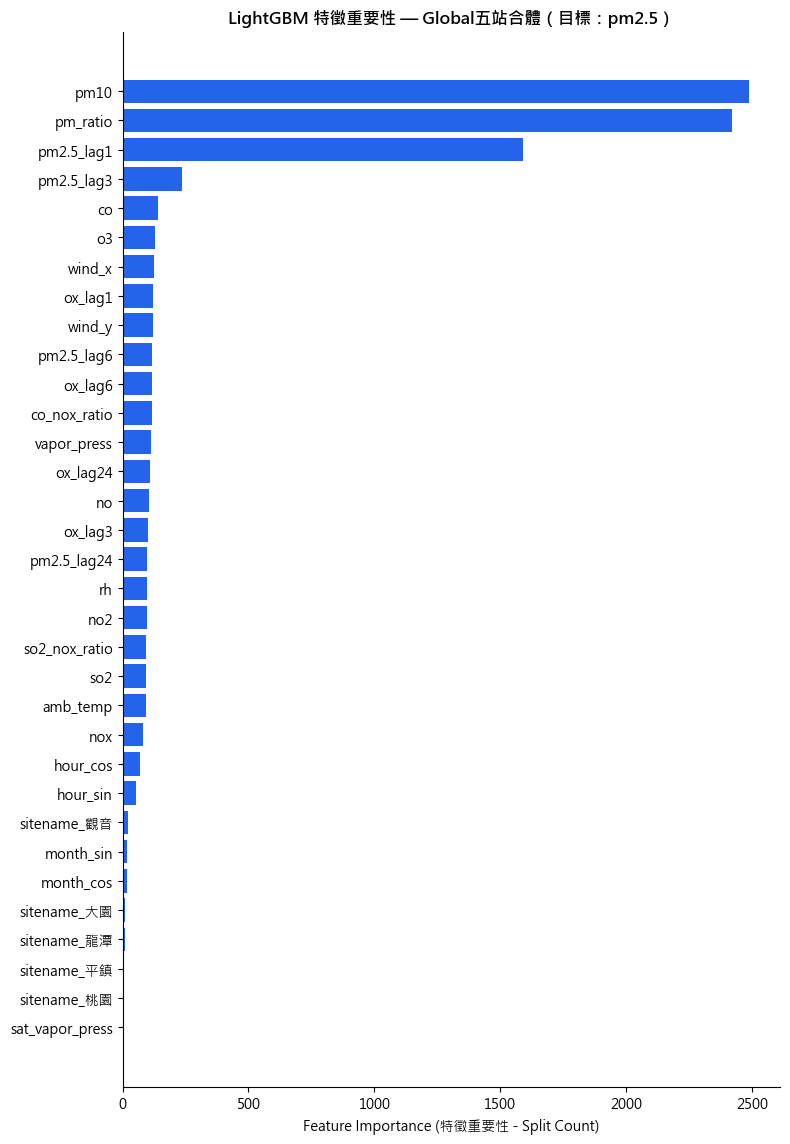

[已儲存圖表] fi_Global五站合體_pm2.5.png
⠸ 正在載入訓練與 2026 Q1 測試資料...

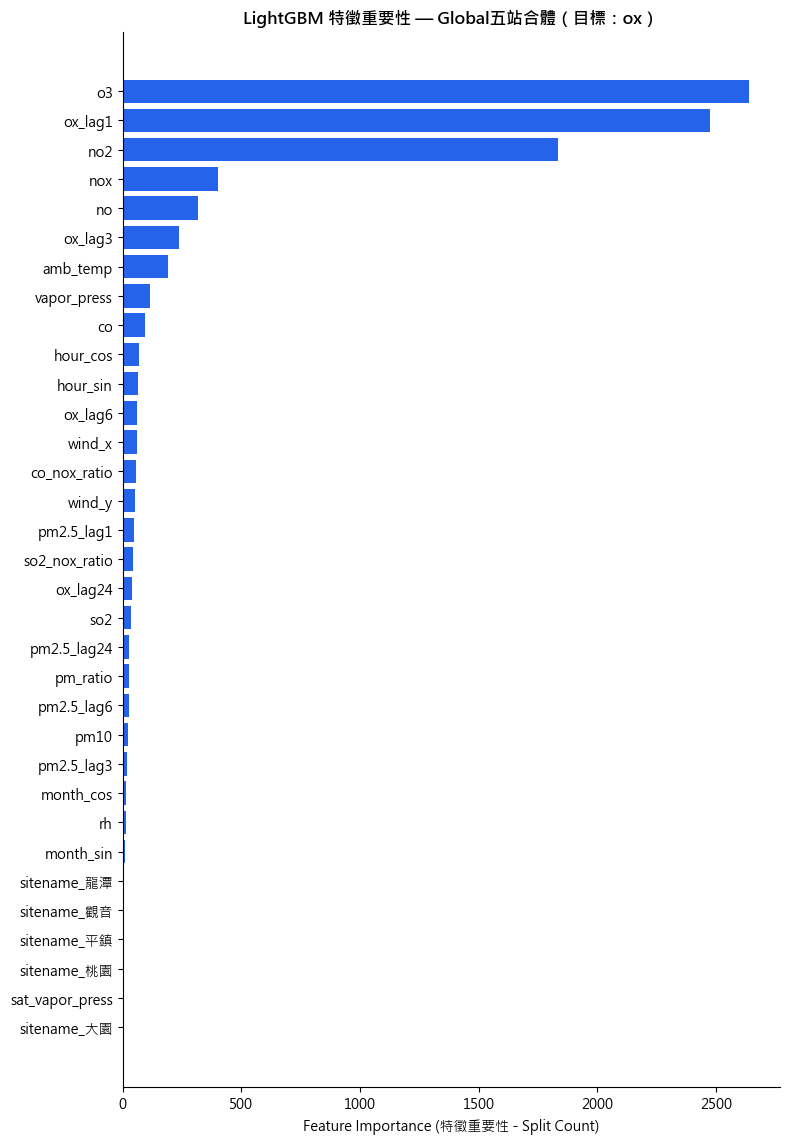

[已儲存圖表] fi_Global五站合體_ox.png

==================== 執行 Local 特徵重要性分析 ====================
⠙ 正在訓練 Local [桃園] 模型並繪圖...⠋ 正在訓練 Local [桃園] 模型並繪圖...
⠴ 正在載入訓練與 2026 Q1 測試資料...

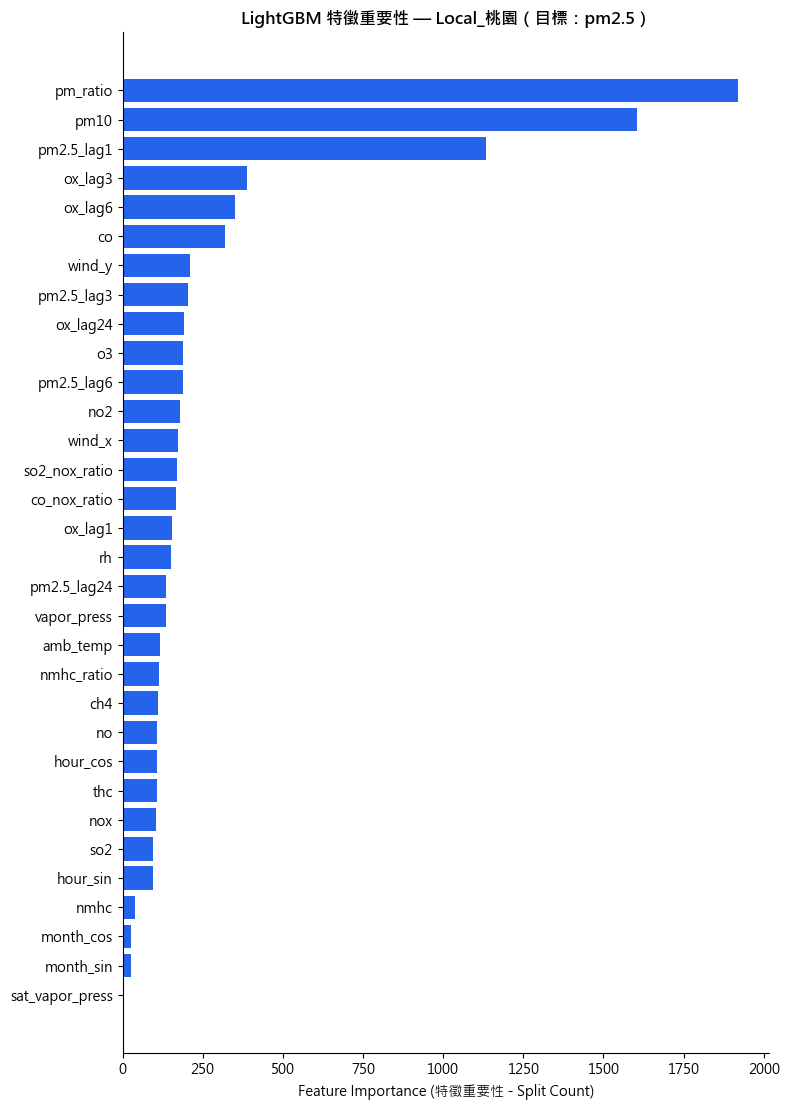

[已儲存圖表] fi_Local_桃園_pm2.5.png
⠴ 正在載入訓練與 2026 Q1 測試資料...

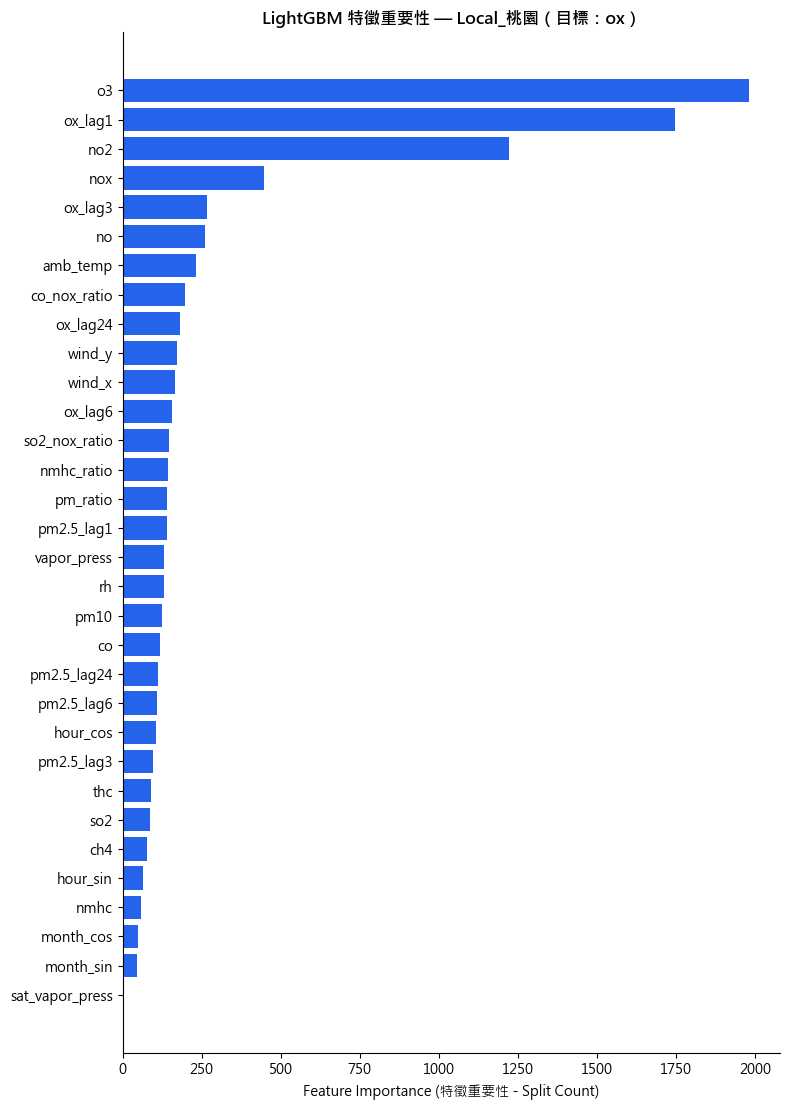

[已儲存圖表] fi_Local_桃園_ox.png
⠙ 正在訓練 Local [平鎮] 模型並繪圖...⠋ 正在訓練 Local [平鎮] 模型並繪圖...
⠼ 正在載入訓練與 2026 Q1 測試資料...

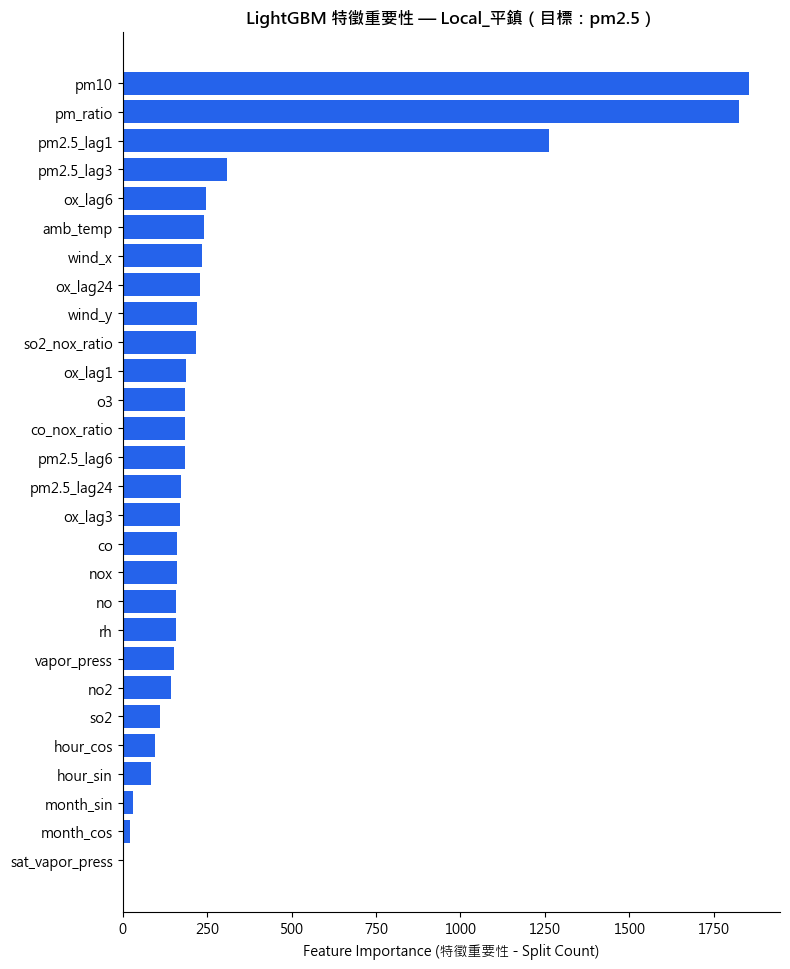

[已儲存圖表] fi_Local_平鎮_pm2.5.png
⠹ 正在載入訓練與 2026 Q1 測試資料...

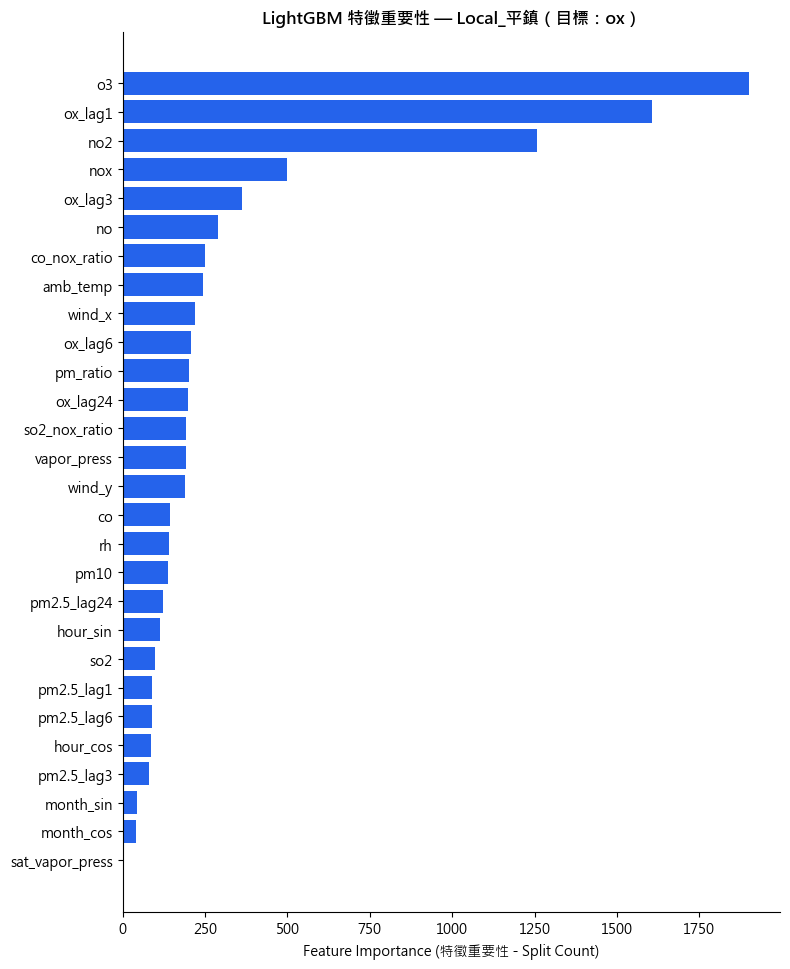

[已儲存圖表] fi_Local_平鎮_ox.png
⠙ 正在訓練 Local [大園] 模型並繪圖...⠋ 正在訓練 Local [大園] 模型並繪圖...
⠸ 正在載入訓練與 2026 Q1 測試資料...

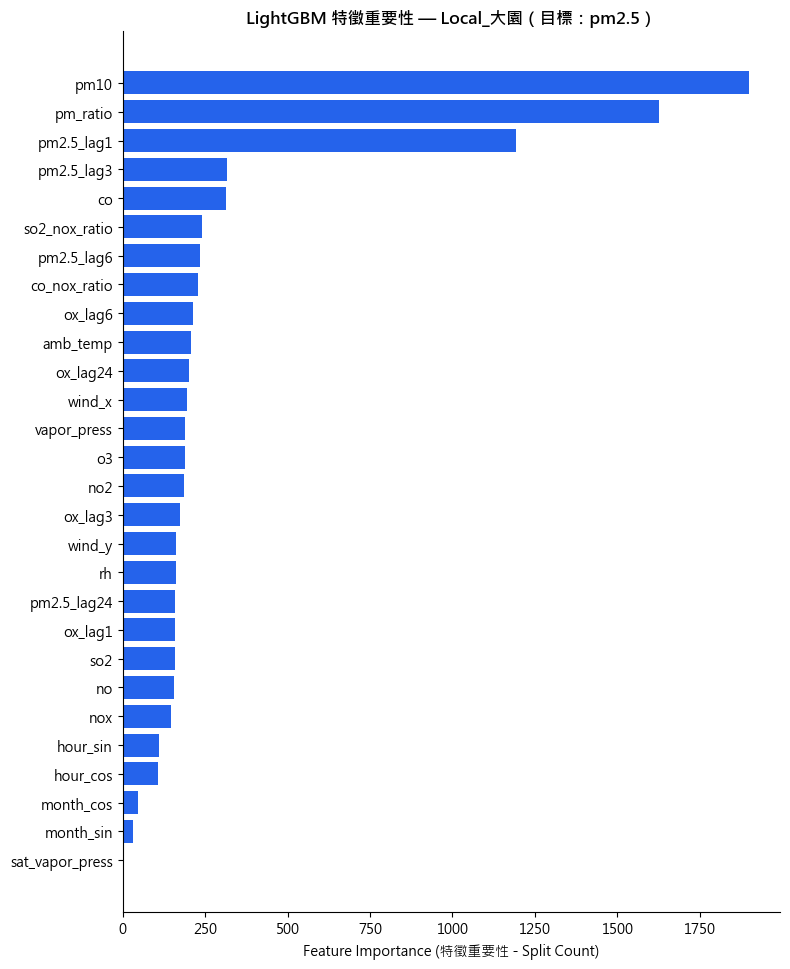

[已儲存圖表] fi_Local_大園_pm2.5.png
⠙ 正在載入訓練與 2026 Q1 測試資料...

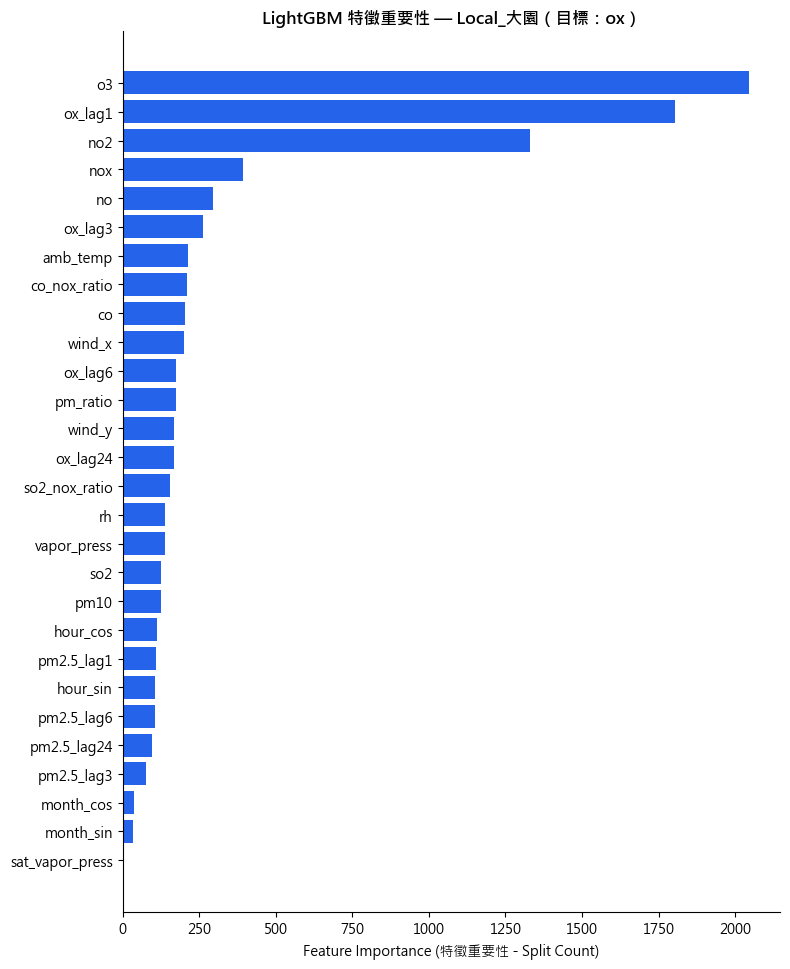

[已儲存圖表] fi_Local_大園_ox.png
⠙ 正在訓練 Local [觀音] 模型並繪圖...⠋ 正在訓練 Local [觀音] 模型並繪圖...
⠋ 正在載入訓練與 2026 Q1 測試資料...

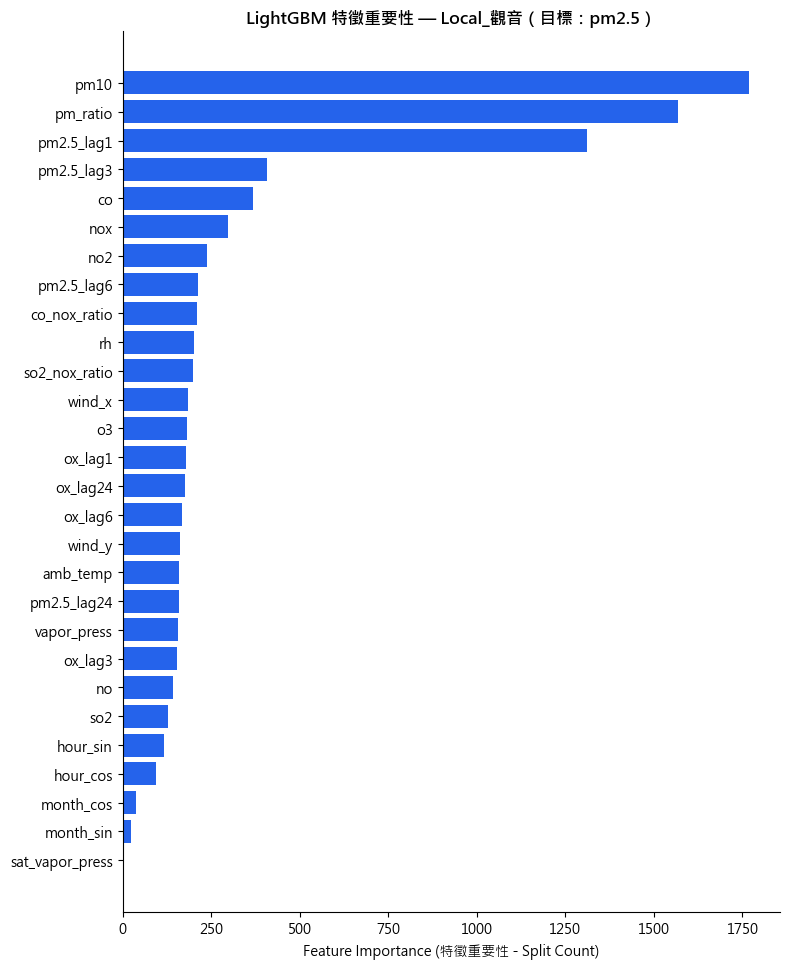

[已儲存圖表] fi_Local_觀音_pm2.5.png
⠇ 正在載入訓練與 2026 Q1 測試資料...

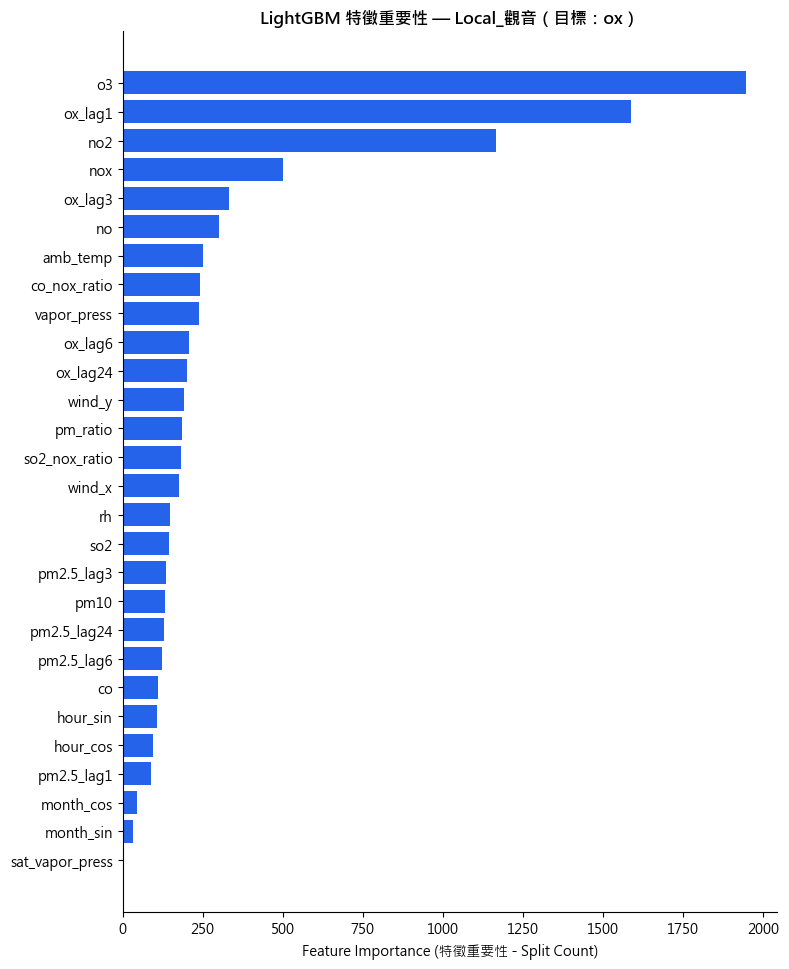

[已儲存圖表] fi_Local_觀音_ox.png
⠙ 正在訓練 Local [龍潭] 模型並繪圖...⠋ 正在訓練 Local [龍潭] 模型並繪圖...
⠦ 正在載入訓練與 2026 Q1 測試資料...

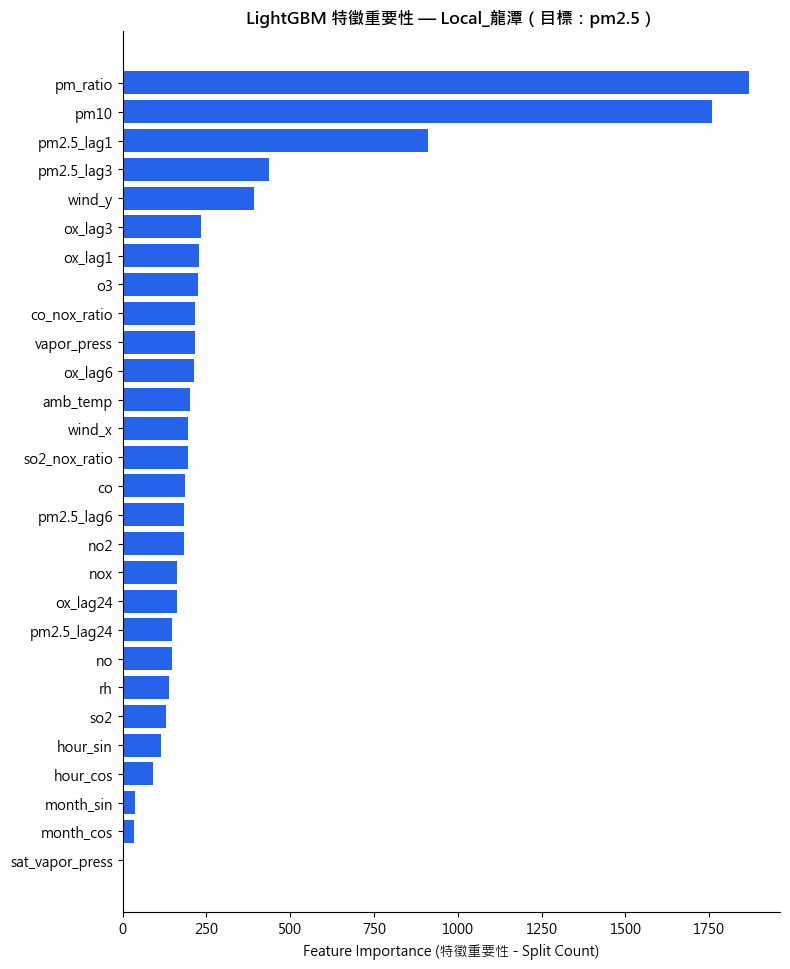

[已儲存圖表] fi_Local_龍潭_pm2.5.png
⠸ 正在載入訓練與 2026 Q1 測試資料...

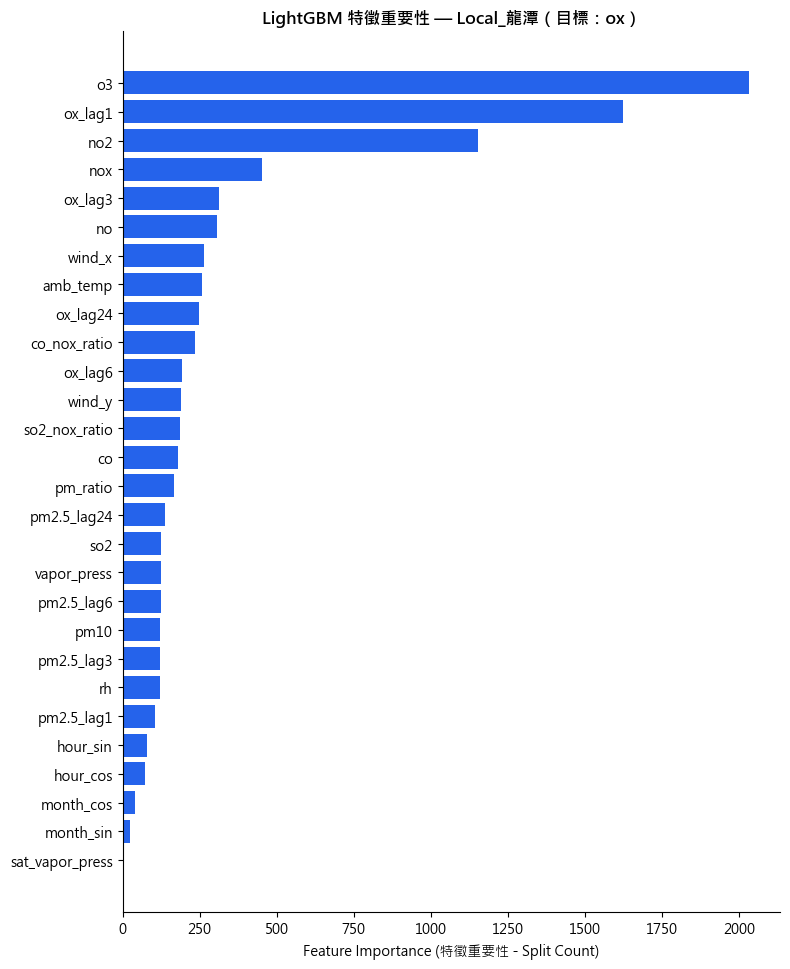

[已儲存圖表] fi_Local_龍潭_ox.png

==================== 執行跨站特徵重要性分析 (pm2.5 only) ====================
⠙ 正在訓練跨站 [觀音 → 大園] 模型並繪圖...32m⠋ 正在訓練跨站 [觀音 → 大園] 模型並繪圖...
⠼ 正在載入訓練與 2026 Q1 測試資料...

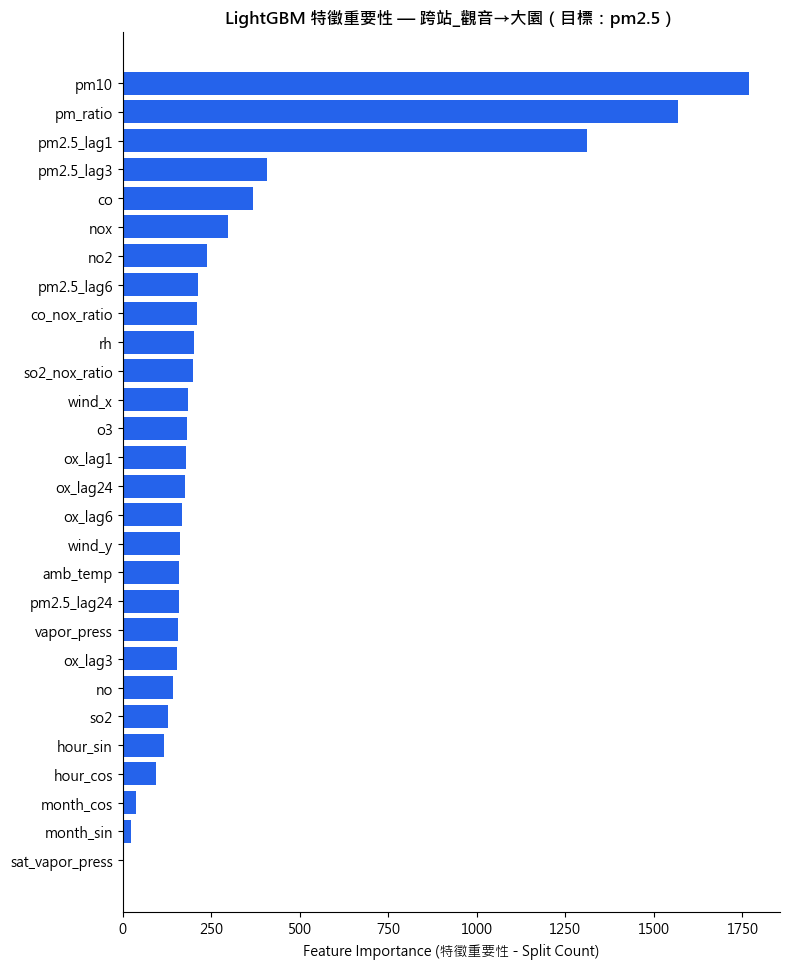

[已儲存圖表] fi_跨站_觀音_大園_pm2.5.png
⠙ 正在訓練跨站 [大園 → 觀音] 模型並繪圖...32m⠋ 正在訓練跨站 [大園 → 觀音] 模型並繪圖...
⠴ 正在載入訓練與 2026 Q1 測試資料...

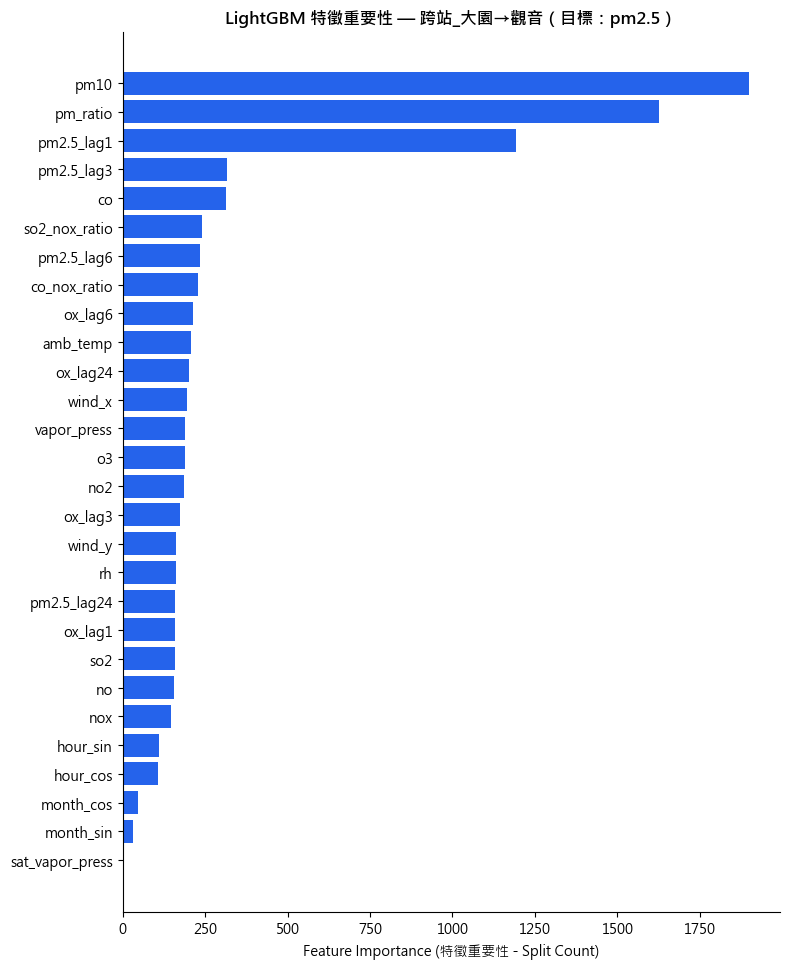

[已儲存圖表] fi_跨站_大園_觀音_pm2.5.png
⠙ 正在訓練跨站 [桃園 → 平鎮] 模型並繪圖...32m⠋ 正在訓練跨站 [桃園 → 平鎮] 模型並繪圖...
⠦ 正在載入訓練與 2026 Q1 測試資料...

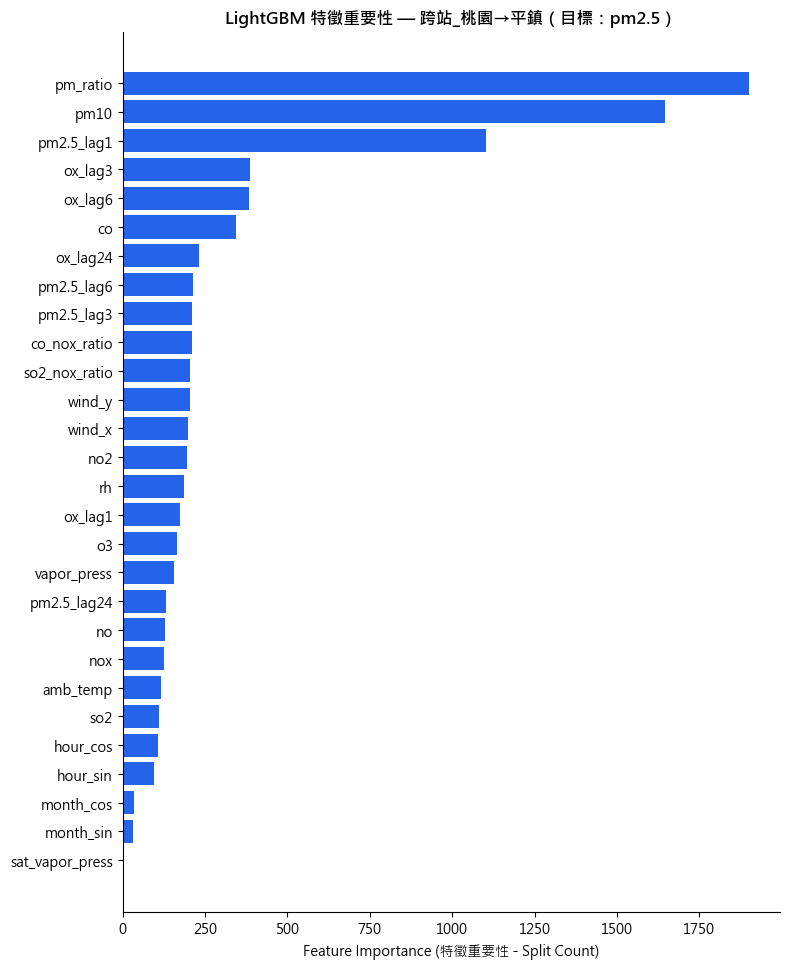

[已儲存圖表] fi_跨站_桃園_平鎮_pm2.5.png
⠙ 正在訓練跨站 [平鎮 → 桃園] 模型並繪圖...32m⠋ 正在訓練跨站 [平鎮 → 桃園] 模型並繪圖...
⠴ 正在載入訓練與 2026 Q1 測試資料...

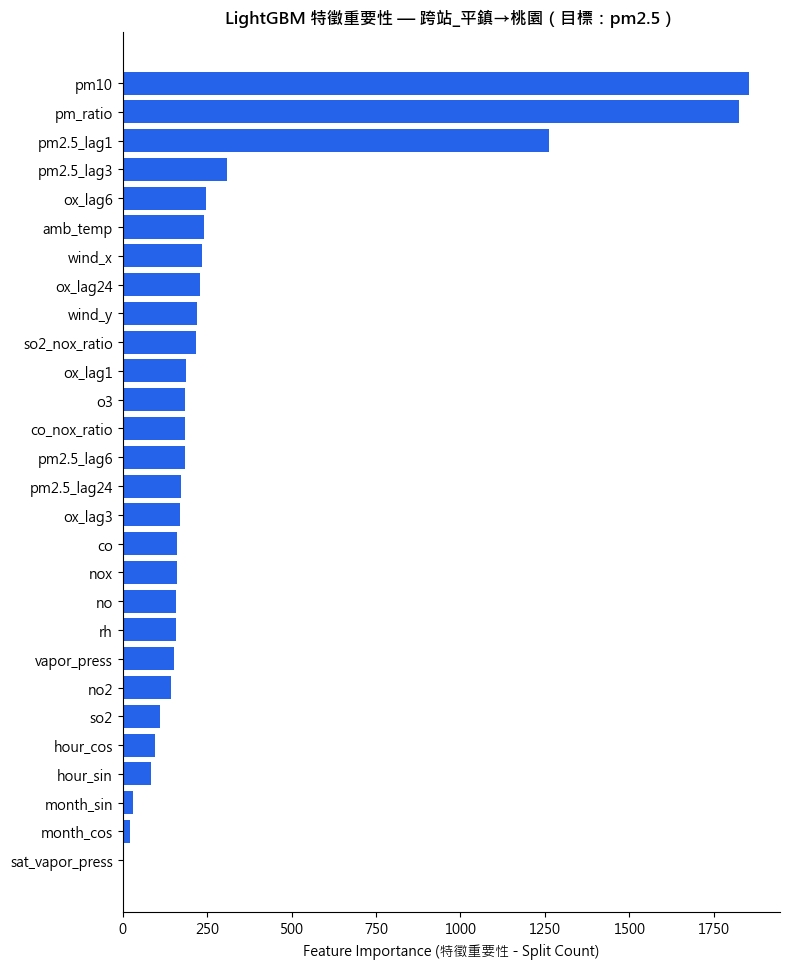

[已儲存圖表] fi_跨站_平鎮_桃園_pm2.5.png

Feature Importance 視覺化完成 — 輸出檔案清單
📸 Global（2張）：
  • fi_Global五站合體_pm2.5.png
  • fi_Global五站合體_ox.png

📸 Local（10張）：
  • fi_Local_桃園_pm2.5.png
  • fi_Local_桃園_ox.png
  • fi_Local_平鎮_pm2.5.png
  • fi_Local_平鎮_ox.png
  • fi_Local_大園_pm2.5.png
  • fi_Local_大園_ox.png
  • fi_Local_觀音_pm2.5.png
  • fi_Local_觀音_ox.png
  • fi_Local_龍潭_pm2.5.png
  • fi_Local_龍潭_ox.png

📸 跨站（4張，pm2.5 only）：
  • fi_跨站_觀音_大園_pm2.5.png
  • fi_跨站_大園_觀音_pm2.5.png
  • fi_跨站_桃園_平鎮_pm2.5.png
  • fi_跨站_平鎮_桃園_pm2.5.png
⠦ 正在載入訓練與 2026 Q1 測試資料...
🎉 合計：16 張 Feature Importance PNG 圖表產出完成！


In [22]:
# ==============================================================================
# 桃園空品監測資料 — LightGBM 特徵重要性 (Feature Importance) 視覺化（16個模型）
# SDD 模組：模型訓練、特徵重要性解析、水平長條圖繪製
# ==============================================================================

import warnings
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from lightgbm import LGBMRegressor
from sklearn.multioutput import MultiOutputRegressor
from sklearn.preprocessing import MinMaxScaler

warnings.filterwarnings("ignore")

# 1. 載入 Rich Console (預防死鎖)
try:
    from rich.console import Console

    console = Console(force_jupyter=False)
    HAS_RICH = True
except ImportError:
    HAS_RICH = False
    print("💡 提示：可安裝 rich 套件以獲得動態 Loading 動畫效果 (pip install rich)")

# 設定繪圖中文字型
plt.rcParams["font.sans-serif"] = [
    "Microsoft JhengHei",
    "SimHei",
    "Noto Sans CJK TC",
    "Arial",
]
plt.rcParams["axes.unicode_minus"] = False


def log(msg):
    if HAS_RICH:
        console.print(msg)
    else:
        print(msg)


# ==============================================================================
# 一、資料載入與特徵工程
# ==============================================================================
if HAS_RICH:
    status = console.status(
        "[bold cyan]正在載入訓練資料並進行特徵工程...", spinner="dots"
    )
    status.start()

df_train_5 = pd.read_csv("2025桃園五站空品監測資料_精簡20欄合體版.csv")
df_train_ty = pd.read_csv("2025桃園站空品監測資料_完整科學指標擴增版.csv")

for df in [df_train_5, df_train_ty]:
    df["publishtime"] = pd.to_datetime(df["publishtime"])


# ── 特徵工程函式 (含 wind_direc 防錯轉換) ──
def add_features(df, group_col="sitename"):
    df = df.copy().sort_values(
        ["sitename", "publishtime"]
        if (group_col and group_col in df.columns)
        else ["publishtime"]
    )

    # 風向 sin/cos 分解 (使用 pd.to_numeric 強制轉為數值，防止字串型態引發 KeyError/TypeError)
    if "wind_direc" in df.columns:
        wind_deg = pd.to_numeric(df["wind_direc"], errors="coerce").ffill()
        wind_deg = wind_deg.fillna(0)

        df["wind_x"] = np.cos(np.deg2rad(wind_deg))
        df["wind_y"] = np.sin(np.deg2rad(wind_deg))
        df = df.drop(columns=["wind_direc"])

    # 時間週期編碼
    df["hour"] = df["publishtime"].dt.hour
    df["month"] = df["publishtime"].dt.month
    df["hour_sin"] = np.sin(2 * np.pi * df["hour"] / 24)
    df["hour_cos"] = np.cos(2 * np.pi * df["hour"] / 24)
    df["month_sin"] = np.sin(2 * np.pi * df["month"] / 12)
    df["month_cos"] = np.cos(2 * np.pi * df["month"] / 12)
    df = df.drop(columns=["hour", "month"])

    # Lag 特徵
    for target_col in ["pm2.5", "ox"]:
        if target_col not in df.columns:
            continue
        if group_col and group_col in df.columns:
            for lag in [1, 3, 6, 24]:
                df[f"{target_col}_lag{lag}"] = df.groupby(group_col)[
                    target_col
                ].shift(lag)
        else:
            for lag in [1, 3, 6, 24]:
                df[f"{target_col}_lag{lag}"] = df[target_col].shift(lag)

    return df


df_train_5_fe = add_features(df_train_5, group_col="sitename")
df_train_ty_fe = add_features(df_train_ty, group_col=None)

exclude_cols = ["sitename", "publishtime"]
targets = ["pm2.5", "ox"]
local_stations = ["桃園", "平鎮", "大園", "觀音", "龍潭"]
cross_pairs = [
    ("觀音", "大園"),
    ("大園", "觀音"),
    ("桃園", "平鎮"),
    ("平鎮", "桃園"),
]

if HAS_RICH:
    status.stop()
log("[green]✓ 特徵工程處理完成！[/green]\n")


# ==============================================================================
# 二、訓練與視覺化核心函式
# ==============================================================================
def train_model(df_train, target_list, label):
    """訓練 LightGBM，回傳 MultiOutputRegressor 物件與特徵欄位名稱清單"""
    feature_cols = [
        c
        for c in df_train.columns
        if c not in exclude_cols + target_list
        and df_train[c].dtype != "object"
    ]

    df_tr = df_train.dropna(subset=feature_cols + target_list)
    X_train = df_tr[feature_cols]
    y_train = df_tr[target_list]

    scaler = MinMaxScaler()
    X_train_sc = scaler.fit_transform(X_train)

    model = MultiOutputRegressor(
        LGBMRegressor(n_estimators=300, random_state=42, verbose=-1)
    )
    model.fit(X_train_sc, y_train)

    return model, feature_cols


def plot_feature_importance(model, feature_cols, model_label, target_list):
    """
    針對指定目標變數繪製 LightGBM 特徵重要性水平條形圖
    model.estimators_[0] 對應 pm2.5
    model.estimators_[1] 對應 ox
    """
    all_targets = ["pm2.5", "ox"]

    for tgt in target_list:
        tgt_idx = all_targets.index(tgt)
        estimator = model.estimators_[tgt_idx]
        importances = estimator.feature_importances_

        fi_df = pd.DataFrame(
            {"特徵": feature_cols, "重要性": importances}
        ).sort_values("重要性", ascending=True)

        fig, ax = plt.subplots(figsize=(8, max(5, len(feature_cols) * 0.35)))
        ax.barh(fi_df["特徵"], fi_df["重要性"], color="#2563EB")
        ax.set_xlabel("Feature Importance (特徵重要性 - Split Count)")
        ax.set_title(
            f"LightGBM 特徵重要性 — {model_label}（目標：{tgt}）",
            fontsize=12,
            weight="bold",
        )

        for spine in ["top", "right"]:
            ax.spines[spine].set_visible(False)

        plt.tight_layout()
        fname = (
            f"fi_{model_label}_{tgt}.png".replace(" ", "_").replace("→", "_")
        )
        plt.savefig(fname, dpi=150)
        plt.show()
        log(f"[已儲存圖表] {fname}")


# ==============================================================================
# 三、模型執行與圖片輸出
# ==============================================================================

# ------------------------------------------------------------------------------
# 3-1. Global 模型 (圖 1, 2)
# ------------------------------------------------------------------------------
log("==================== 執行 Global 特徵重要性分析 ====================")
if HAS_RICH:
    status = console.status(
        "[bold cyan]正在訓練 Global 模型並繪圖...", spinner="dots"
    )
    status.start()

df_global_train = pd.get_dummies(df_train_5_fe.copy(), columns=["sitename"])
model_g, feature_cols_g = train_model(
    df_global_train, targets, "Global五站合體"
)

if HAS_RICH:
    status.stop()

plot_feature_importance(model_g, feature_cols_g, "Global五站合體", targets)

# ------------------------------------------------------------------------------
# 3-2. Local 模型 (圖 3 ~ 12)
# ------------------------------------------------------------------------------
log(
    "\n==================== 執行 Local 特徵重要性分析 ===================="
)

for station in local_stations:
    if HAS_RICH:
        status = console.status(
            f"[bold cyan]正在訓練 Local [{station}] 模型並繪圖...",
            spinner="dots",
        )
        status.start()

    if station == "桃園":
        df_tr = df_train_ty_fe.copy()
    else:
        df_tr = df_train_5_fe[df_train_5_fe["sitename"] == station].copy()

    model_l, feature_cols_l = train_model(df_tr, targets, f"Local_{station}")

    if HAS_RICH:
        status.stop()

    plot_feature_importance(model_l, feature_cols_l, f"Local_{station}", targets)

# ------------------------------------------------------------------------------
# 3-3. 跨站模型 (圖 13 ~ 16, PM2.5 Only)
# ------------------------------------------------------------------------------
log(
    "\n==================== 執行跨站特徵重要性分析 (pm2.5 only) ===================="
)

for train_sta, test_sta in cross_pairs:
    if HAS_RICH:
        status = console.status(
            f"[bold cyan]正在訓練跨站 [{train_sta} → {test_sta}] 模型並繪圖...",
            spinner="dots",
        )
        status.start()

    df_tr = df_train_5_fe[df_train_5_fe["sitename"] == train_sta].copy()
    model_c, feature_cols_c = train_model(
        df_tr, targets, f"跨站_{train_sta}→{test_sta}"
    )

    if HAS_RICH:
        status.stop()

    # 跨站只繪製 pm2.5
    plot_feature_importance(
        model_c, feature_cols_c, f"跨站_{train_sta}→{test_sta}", ["pm2.5"]
    )

# ==============================================================================
# 四、產出結果摘要
# ==============================================================================
log("\n" + "=" * 60)
log("Feature Importance 視覺化完成 — 輸出檔案清單")
log("=" * 60)
log("📸 Global（2張）：")
for tgt in targets:
    log(f"  • fi_Global五站合體_{tgt}.png")

log("\n📸 Local（10張）：")
for sta in local_stations:
    for tgt in targets:
        log(f"  • fi_Local_{sta}_{tgt}.png")

log("\n📸 跨站（4張，pm2.5 only）：")
for tr, te in cross_pairs:
    log(f"  • fi_跨站_{tr}_{te}_pm2.5.png")

log("\n🎉 合計：16 張 Feature Importance PNG 圖表產出完成！")